Cell 1 - import

In [1]:
import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.signal import butter, filtfilt, find_peaks, savgol_filter
from scipy.stats import pearsonr
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import warnings, os, glob, gc, time
warnings.filterwarnings('ignore')

FS = 125
SEG_LEN = 1250
SEG_STEP = 625
SBP_RANGE = (70, 200)
DBP_RANGE = (40, 120)
DATA_DIR = '/kaggle/input/datasets/mkachuee/BloodPressureDataset'
CKPT = '/kaggle/working/checkpoints'
os.makedirs(CKPT, exist_ok=True)
print("✅ Cell 1")


✅ Cell 1


cell 2 - Load

In [2]:
def extract_bp_from_abp(abp_seg, fs=125):
    peaks, _ = find_peaks(abp_seg, distance=int(0.4*fs), prominence=10)
    if len(peaks) < 2: return None, None
    sbp_vals = abp_seg[peaks]
    dbp_vals = []
    for i in range(len(peaks)-1):
        v = np.argmin(abp_seg[peaks[i]:peaks[i+1]]) + peaks[i]
        dbp_vals.append(abp_seg[v])
    return float(np.mean(sbp_vals)), float(np.mean(dbp_vals))

print("Loading...")
all_segments = []
record_counter = 0

mat_files = sorted(glob.glob(os.path.join(DATA_DIR, 'part_*.mat')))
if not mat_files:
    for alt in ['/kaggle/input/bloodpressuredataset',
                '/kaggle/input/cuff-less-blood-pressure-estimation',
                '/kaggle/input/datasets/mkachuee/BloodPressureDataset']:
        mat_files = sorted(glob.glob(os.path.join(alt, '*.mat')))
        if mat_files: DATA_DIR = alt; break

print(f"Found {len(mat_files)} files in {DATA_DIR}")
for fpath in mat_files:
    fname = os.path.basename(fpath)
    print(f"  {fname}...", end=" ")
    mat = sio.loadmat(fpath)
    dk = 'p' if 'p' in mat else [k for k in mat if not k.startswith('__')][0]
    records = mat[dk]
    n_recs = records.shape[1]
    sc = 0
    for ri in range(n_recs):
        rec = records[0, ri]
        if rec.ndim != 2 or rec.shape[0] < 3: continue
        ppg_r, abp_r, ecg_r = rec[0].astype(np.float64), rec[1].astype(np.float64), rec[2].astype(np.float64)
        sl = len(ppg_r)
        if sl < SEG_LEN: continue
        for start in range(0, sl - SEG_LEN + 1, SEG_STEP):
            end = start + SEG_LEN
            ps, as_, es = ppg_r[start:end], abp_r[start:end], ecg_r[start:end]
            if np.any(np.isnan(ps)) or np.any(np.isnan(es)): continue
            if np.std(ps) < 1e-6 or np.std(es) < 1e-6: continue
            sbp, dbp = extract_bp_from_abp(as_, FS)
            if sbp is None: continue
            if not (SBP_RANGE[0] <= sbp <= SBP_RANGE[1]): continue
            if not (DBP_RANGE[0] <= dbp <= DBP_RANGE[1]): continue
            if dbp >= sbp: continue
            all_segments.append({'ppg': ps.copy(), 'ecg': es.copy(),
                                 'sbp': sbp, 'dbp': dbp, 'record_id': record_counter})
            sc += 1
        record_counter += 1
    print(f"{n_recs} recs → {sc} segs | total: {len(all_segments)}")
    del mat; gc.collect()

sbps = [s['sbp'] for s in all_segments]
dbps = [s['dbp'] for s in all_segments]
print(f"\n✅ {len(all_segments)} segments, {record_counter} records")
print(f"SBP: {np.mean(sbps):.1f}±{np.std(sbps):.1f} | DBP: {np.mean(dbps):.1f}±{np.std(dbps):.1f}")


Loading...
Found 12 files in /kaggle/input/datasets/mkachuee/BloodPressureDataset
  part_1.mat... 1000 recs → 49775 segs | total: 49775
  part_10.mat... 1000 recs → 45941 segs | total: 95716
  part_11.mat... 1000 recs → 46720 segs | total: 142436
  part_12.mat... 1000 recs → 37788 segs | total: 180224
  part_2.mat... 1000 recs → 43318 segs | total: 223542
  part_3.mat... 1000 recs → 34796 segs | total: 258338
  part_4.mat... 1000 recs → 47563 segs | total: 305901
  part_5.mat... 1000 recs → 50757 segs | total: 356658
  part_6.mat... 1000 recs → 49613 segs | total: 406271
  part_7.mat... 1000 recs → 23314 segs | total: 429585
  part_8.mat... 1000 recs → 37380 segs | total: 466965
  part_9.mat... 1000 recs → 48636 segs | total: 515601

✅ 515601 segments, 10874 records
SBP: 129.5±22.0 | DBP: 66.6±10.8


cell 3 - Features

  VISUALIZATION

  Seg 0 | SBP=123 DBP=68


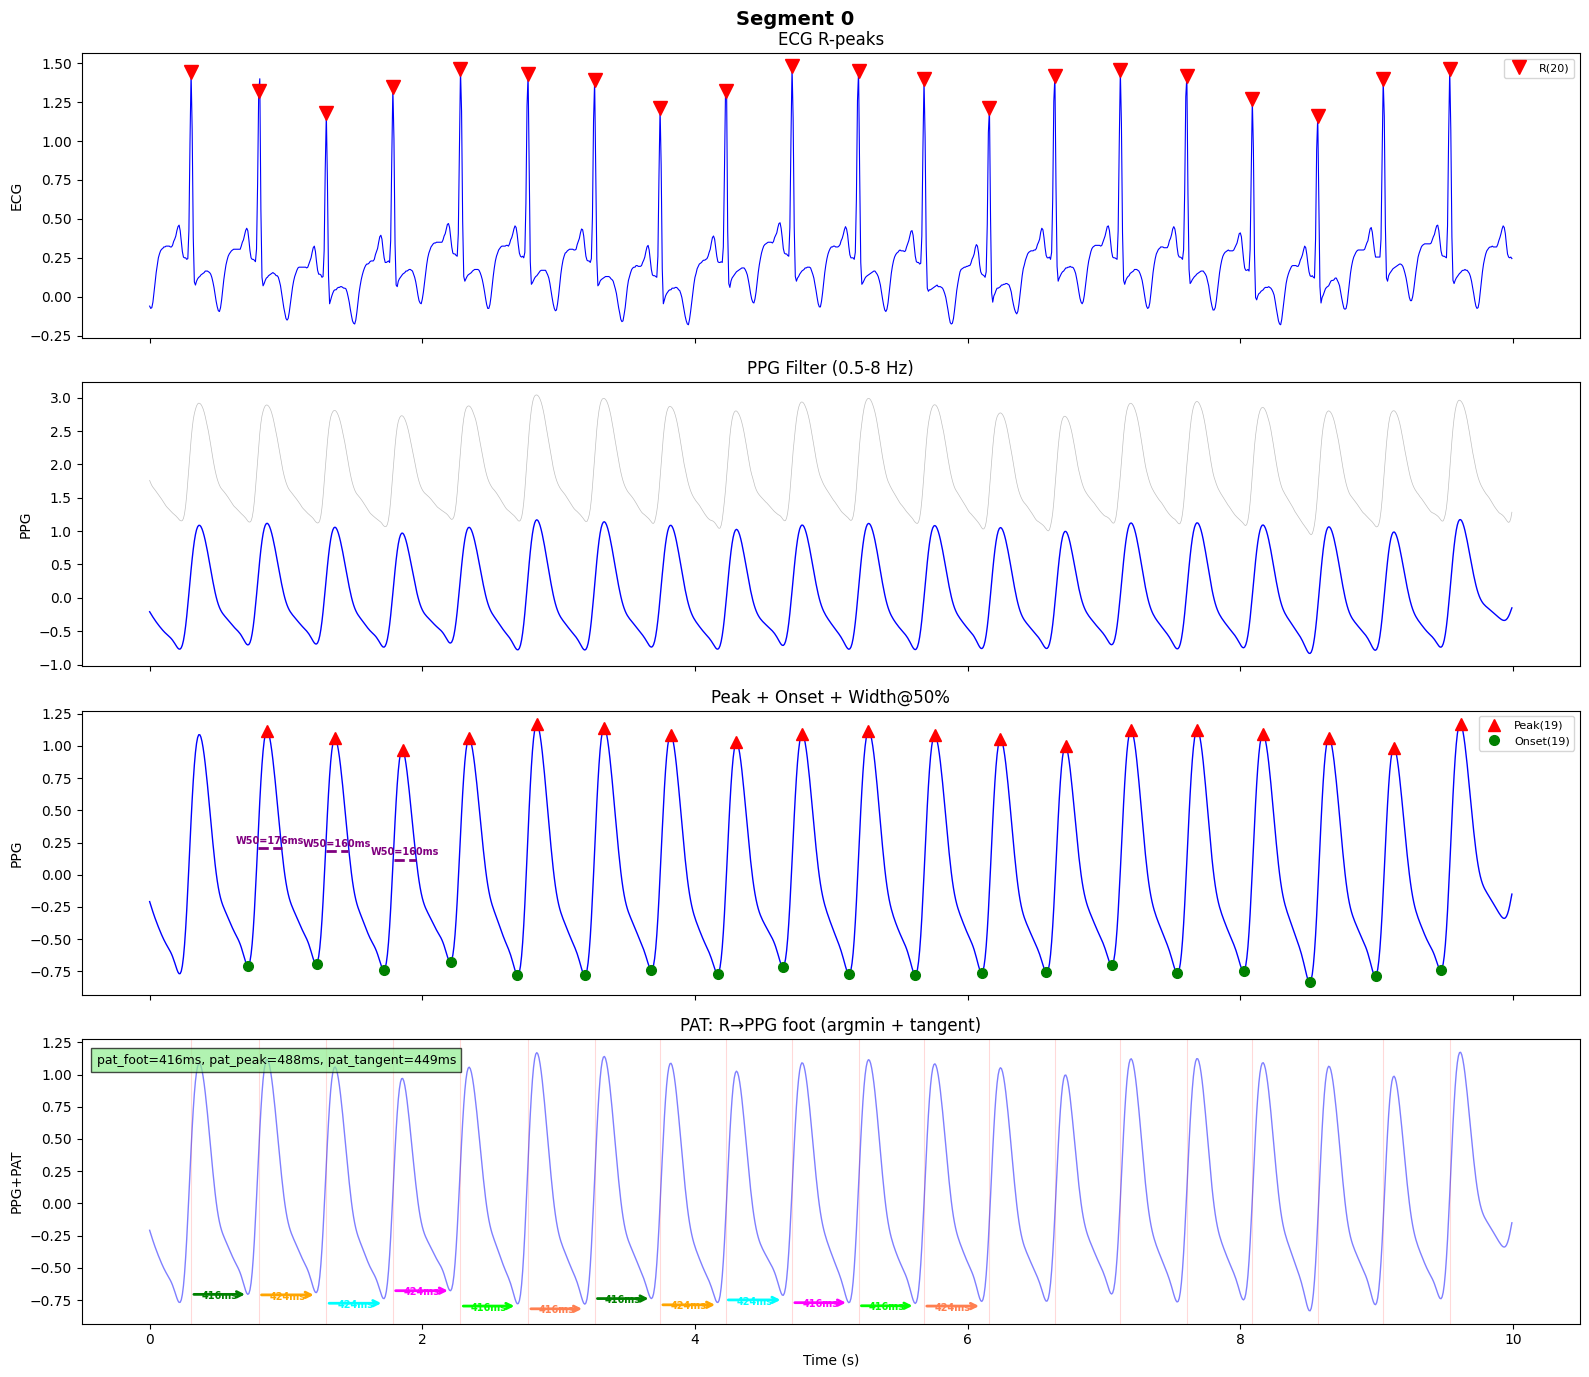

  ✅ pat_foot=416ms, pat_peak=488ms, pat_tangent=449ms

  Seg 1000 | SBP=109 DBP=70


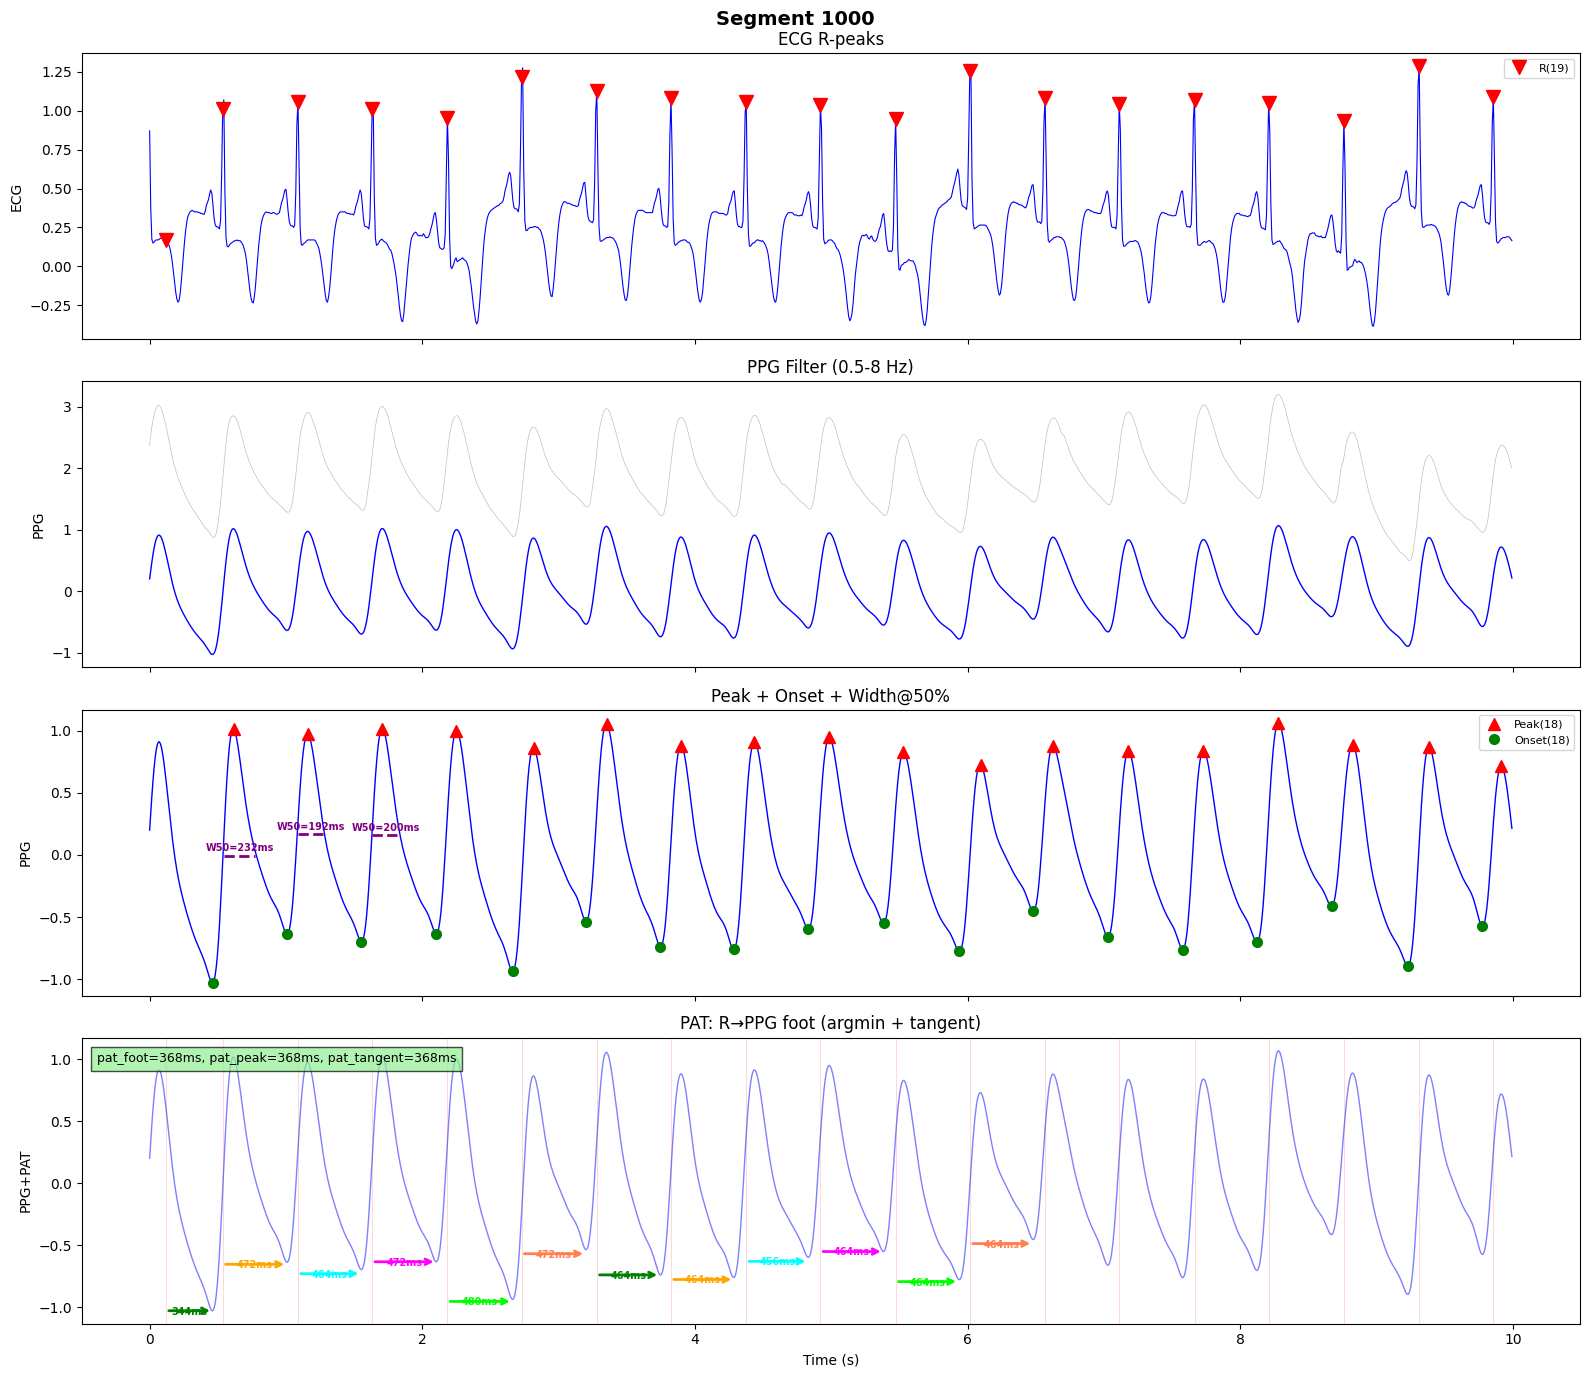

  ✅ pat_foot=368ms, pat_peak=368ms, pat_tangent=368ms

  Seg 5000 | SBP=122 DBP=76


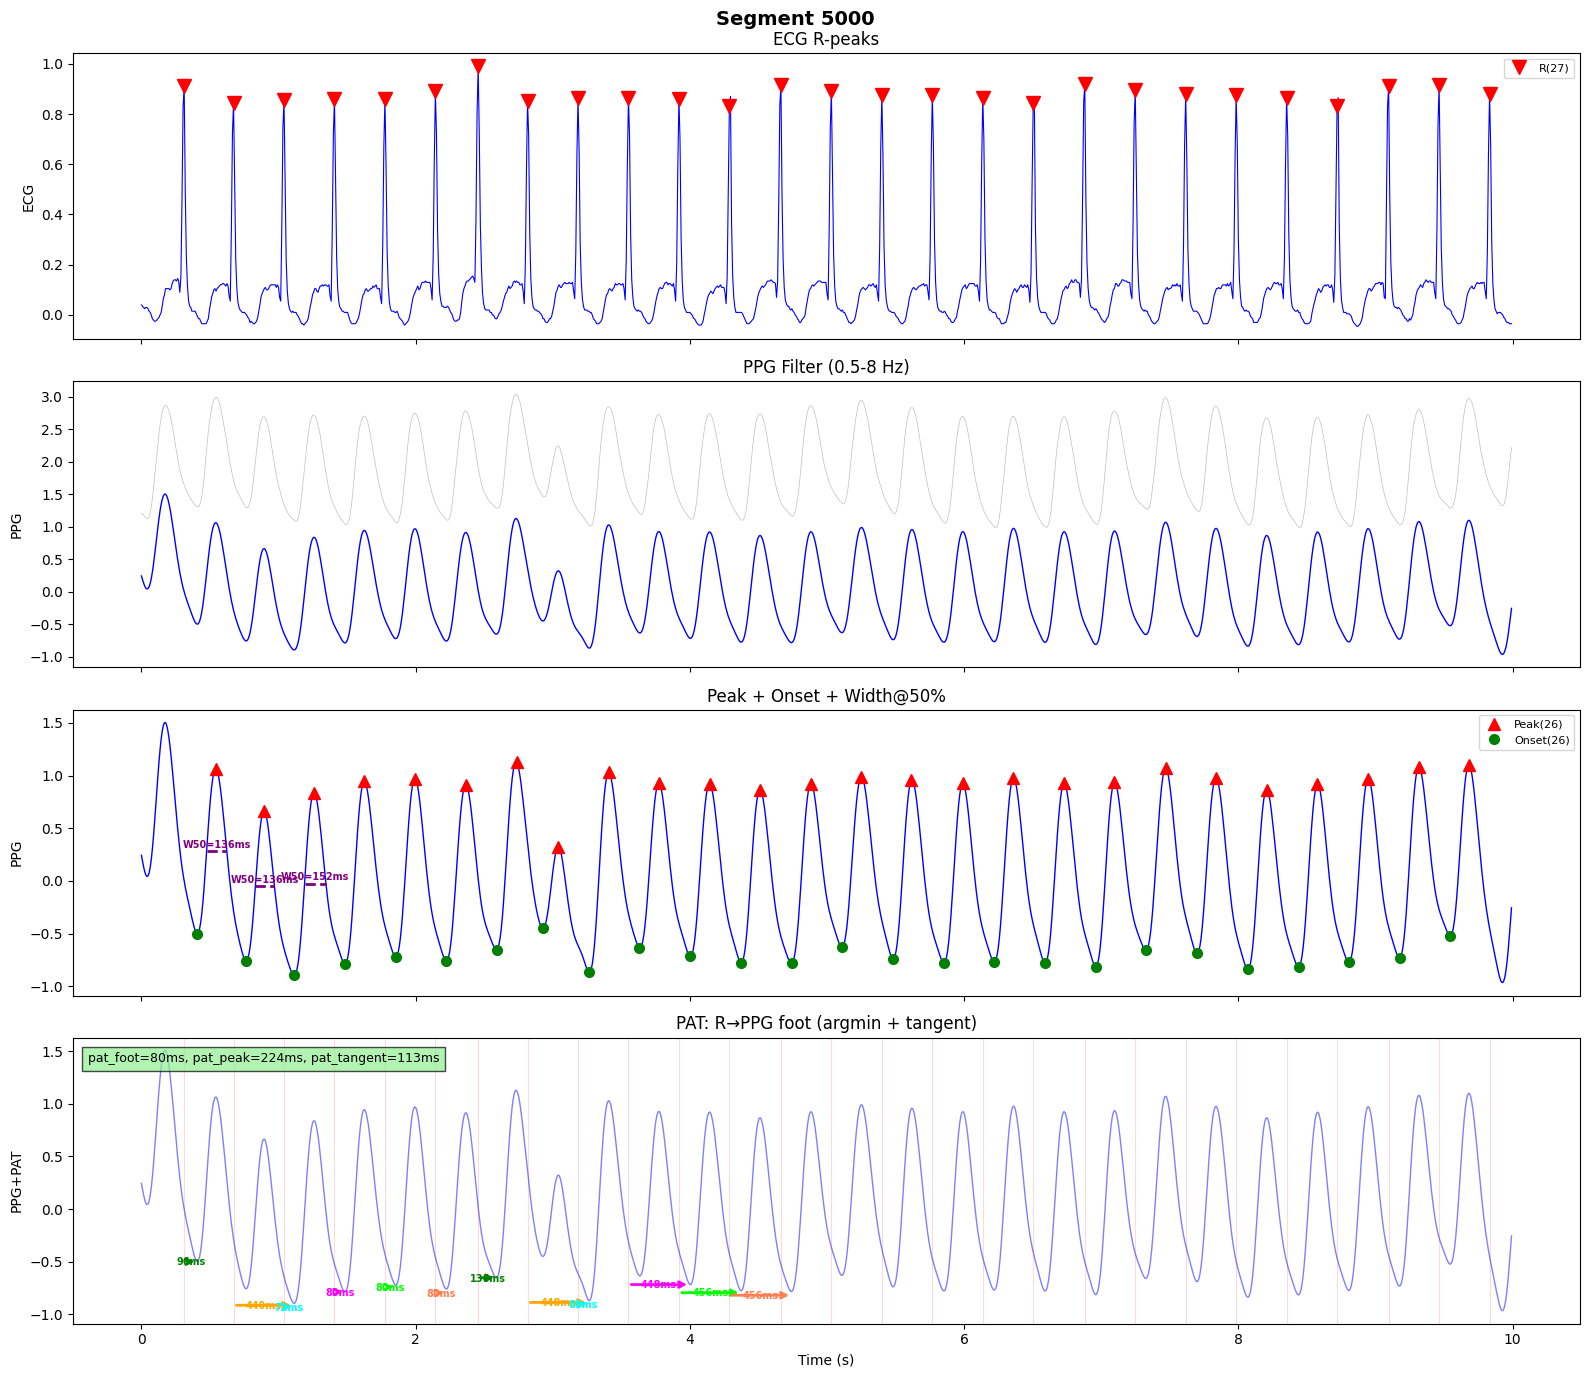

  ✅ pat_foot=80ms, pat_peak=224ms, pat_tangent=113ms

  Seg 10000 | SBP=122 DBP=57


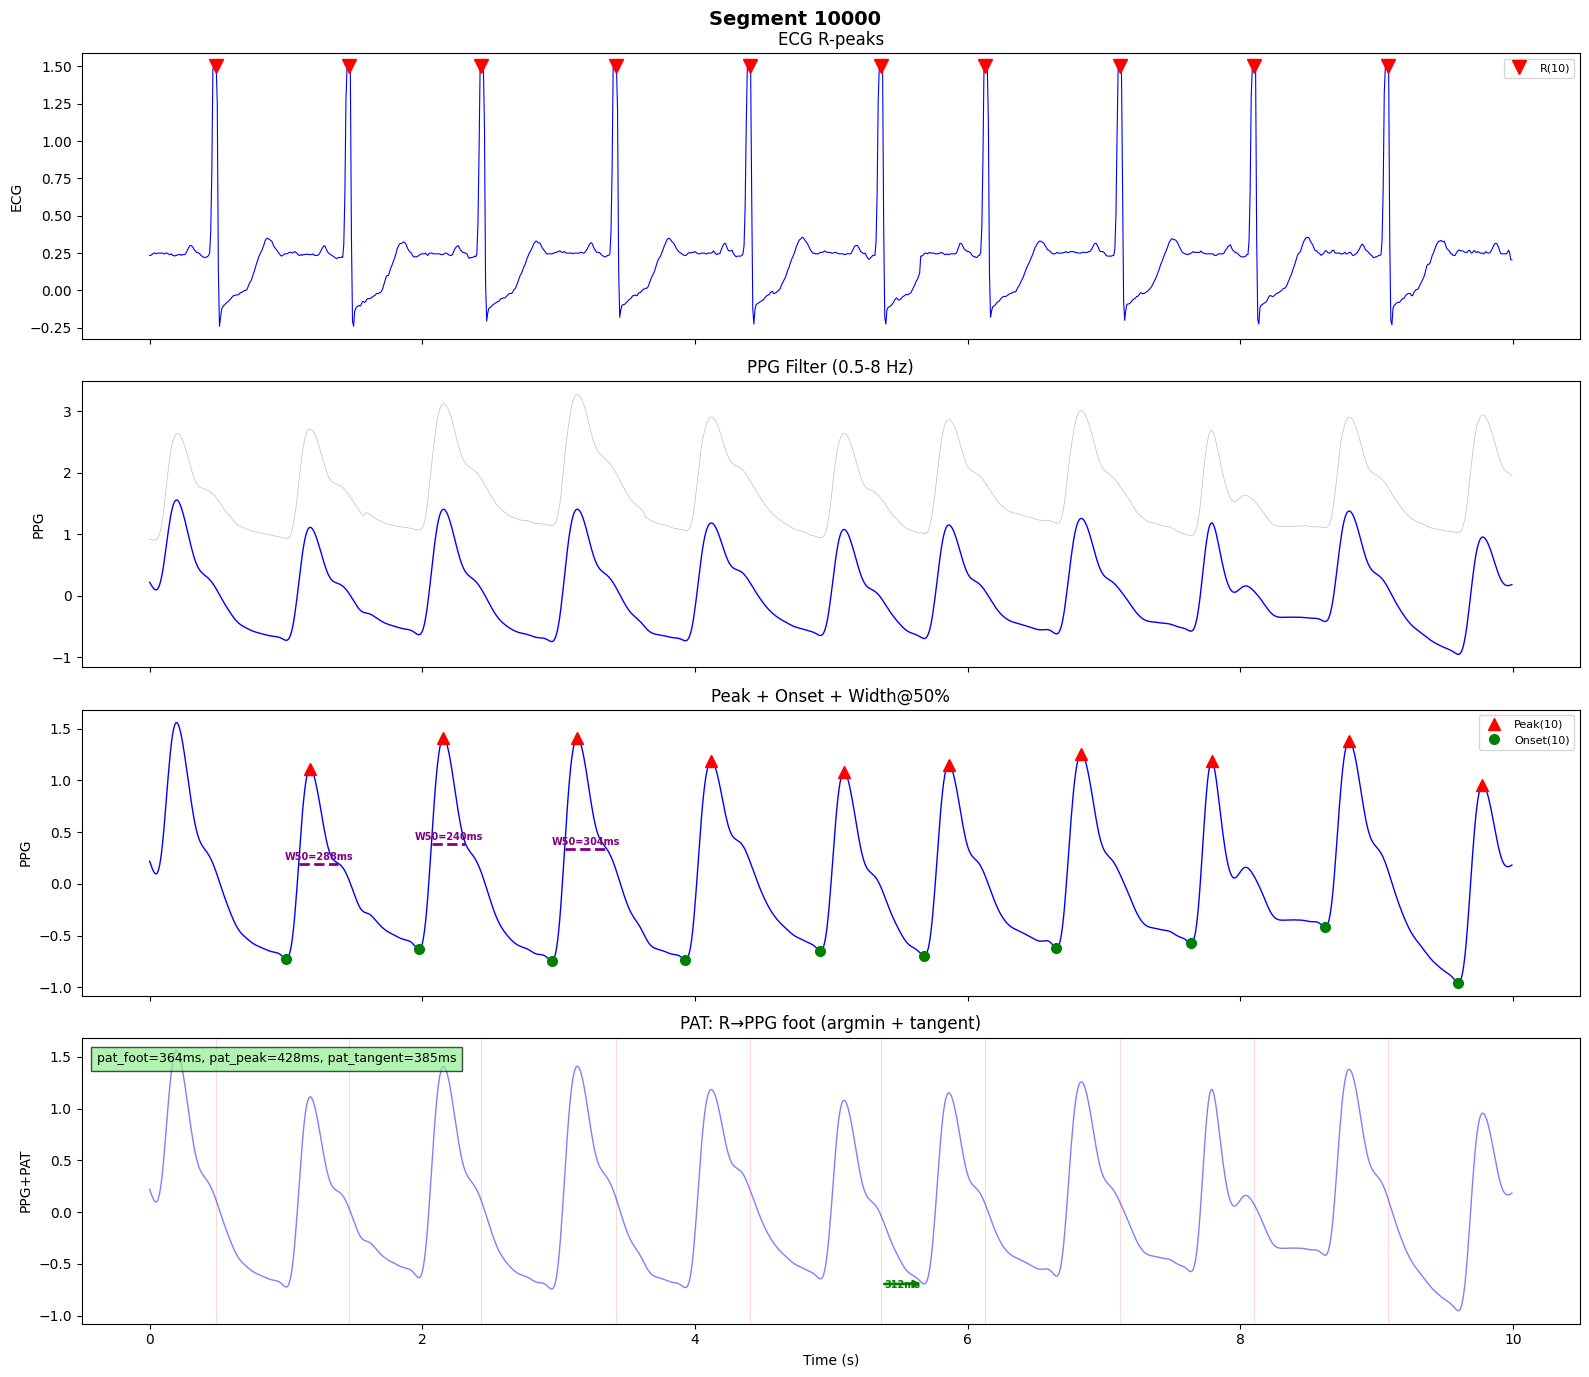

  ✅ pat_foot=364ms, pat_peak=428ms, pat_tangent=385ms
  EXTRACTION (v17)
  [     0/515601]   0.0% | 0s | 0/s
  [ 50000/515601]   9.7% | 582s | 86/s
  [100000/515601]  19.4% | 1192s | 84/s
  [150000/515601]  29.1% | 1801s | 83/s
  [200000/515601]  38.8% | 2416s | 83/s
  [250000/515601]  48.5% | 3030s | 82/s
  [300000/515601]  58.2% | 3643s | 82/s
  [350000/515601]  67.9% | 4263s | 82/s
  [400000/515601]  77.6% | 4902s | 82/s
  [450000/515601]  87.3% | 5504s | 82/s
  [500000/515601]  97.0% | 6136s | 81/s

✅ 6431s | 22 feat | 513,472 valid | 2,129 skip | 10,859 recs
✅ Cached to /kaggle/working/cache_cell3_v17.npz (1147 MB)

  PPG_raw: (513472, 1250) (1284 MB)

Feature               Mean       Std   NaN%   rSBP   rDBP
------------------------------------------------------------
  hr_mean          90.0177   16.3934   0.0% -0.103 +0.150 ★
  ecg_mobility      0.5101    0.1148   0.0% +0.049 +0.107 ★
  ecg_complexity    0.8380    0.1257   0.0% +0.071 +0.067
  ecg_entropy       2.7396    0.3143 

In [3]:
# CELL 3 — v17: v16 + ECG morphology (Hjorth, entropy, autocorr)
# Ref: Sevakula et al. 2025, Nature npj Cardiovascular Health
import time, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks, savgol_filter
from scipy.stats import pearsonr, skew

def _bpf(sig, lo, hi, fs=125, order=3):
    nyq = fs / 2.0; lo, hi = max(lo, 0.01), min(hi, nyq - 0.1)
    b, a = butter(order, [lo/nyq, hi/nyq], btype='band')
    if len(sig) < 3 * max(len(a), len(b)): return None
    return filtfilt(b, a, sig).astype(np.float64)

def detect_rpeaks(ecg, fs=125):
    ecg_bp = _bpf(ecg, 5.0, 15.0, fs, order=2)
    if ecg_bp is None: return np.array([], dtype=int)
    dsq = np.diff(ecg_bp, prepend=ecg_bp[0])**2
    mwi = np.convolve(dsq, np.ones(int(0.15*fs))/int(0.15*fs), mode='same')
    mx = np.max(mwi)
    if mx < 1e-10: return np.array([], dtype=int)
    cands, _ = find_peaks(mwi, distance=int(0.25*fs), height=0.20*mx)
    if len(cands) < 2: return np.array([], dtype=int)
    ecg_w = _bpf(ecg, 0.5, 40.0, fs)
    if ecg_w is None: return cands
    hw = int(0.05*fs)
    pc = sum(1 for p in cands if np.max(ecg_w[max(0,p-hw):min(len(ecg_w),p+hw)]) >
             abs(np.min(ecg_w[max(0,p-hw):min(len(ecg_w),p+hw)])))
    up = pc >= len(cands) - pc
    ref = []
    for p in cands:
        s, e = max(0, p-hw), min(len(ecg_w), p+hw)
        ref.append(s + (int(np.argmax(ecg_w[s:e])) if up else int(np.argmin(ecg_w[s:e]))))
    return np.array(ref, dtype=int)

def detect_ppg_beats(ppg_f, fs=125):
    std_p = np.std(ppg_f)
    if std_p < 1e-8: return None
    pks, _ = find_peaks(ppg_f, distance=int(0.3*fs), prominence=0.08*std_p)
    if len(pks) < 3: return None
    beats = []
    for i in range(len(pks)-1):
        pc, pn = pks[i], pks[i+1]
        seg = ppg_f[pc:pn]
        if len(seg) < 2: continue
        onset = pc + int(np.argmin(seg))
        amp = ppg_f[pn] - ppg_f[onset]
        if amp <= 0: continue
        beats.append({'onset': onset, 'peak': pn, 'amp': float(amp)})
    return beats if len(beats) >= 1 else None

# ── PAT: R→forward, dual method (argmin + intersecting tangents) ──
def compute_pat(ppg_f, r_peaks, fs=125):
    sg_win = min(15, len(ppg_f)//2*2 - 1)
    if sg_win < 5: return {}
    vpg = savgol_filter(ppg_f, sg_win, 3, deriv=1, delta=1.0/fs)
    pat_foot, pat_peak, pat_tangent = [], [], []
    if len(r_peaks) < 2: return {}
    for ri in range(len(r_peaks)):
        r = r_peaks[ri]
        ws = r + int(0.06*fs); we = r + int(0.50*fs)
        if we >= len(ppg_f) or ws < 0 or we - ws < 3: continue
        vpg_win = vpg[ws:we]; ppg_win = ppg_f[ws:we]
        # FIRST significant VPG peak = systolic upstroke
        vpg_pks, _ = find_peaks(vpg_win, distance=max(2, int(0.03*fs)),
                                prominence=0.1*np.max(np.abs(vpg_win)))
        if len(vpg_pks) == 0:
            if np.max(vpg_win) > 0:
                vpg_pks = np.array([int(np.argmax(vpg_win))])
            else: continue
        ms_l = vpg_pks[0]  # FIRST peak = systolic
        # Method 1: argmin foot (original)
        if ms_l >= 1:
            ft_l = int(np.argmin(ppg_win[:ms_l+1]))
            dt_foot = (ws + ft_l - r) / fs
            if 0.05 <= dt_foot <= 0.50: pat_foot.append(dt_foot)
        # Method 2: intersecting tangents (NEW)
        if ms_l >= 2:
            slope_at_max = vpg_win[ms_l]
            if abs(slope_at_max) > 1e-6:
                ppg_at_ms = ppg_win[ms_l]
                t_ms = ms_l / fs  # time of max slope within window
                # Tangent line: ppg(t) = ppg_at_ms + slope * (t - t_ms)
                # Baseline: horizontal at min PPG before max slope
                baseline = np.min(ppg_win[:ms_l+1])
                # Intersection: baseline = ppg_at_ms + slope * (t_int - t_ms)
                t_int = t_ms + (baseline - ppg_at_ms) / slope_at_max
                dt_tangent = (ws / fs + t_int) - (r / fs)
                if 0.03 <= dt_tangent <= 0.50:
                    pat_tangent.append(dt_tangent)
        # Systolic peak
        pk_region = ppg_win[ms_l:]
        if len(pk_region) > 0:
            pk_g = ws + ms_l + int(np.argmax(pk_region))
            dt_peak = (pk_g - r) / fs
            if 0.08 <= dt_peak <= 0.50: pat_peak.append(dt_peak)
    res = {}
    if len(pat_foot) >= 2: res['pat_foot'] = float(np.median(pat_foot))
    if len(pat_peak) >= 2: res['pat_peak'] = float(np.median(pat_peak))
    if len(pat_tangent) >= 2: res['pat_tangent'] = float(np.median(pat_tangent))
    return res

def extract_features(ppg_raw, ecg_raw, fs=125):
    f = {}
    ppg_f = _bpf(ppg_raw, 0.5, 8.0, fs)
    if ppg_f is None: return None
    rp = detect_rpeaks(ecg_raw, fs)
    if len(rp) < 2: return None
    rr = np.diff(rp) / fs; rr = rr[(rr > 0.25) & (rr < 2.5)]
    if len(rr) < 1: return None
    f['hr_mean'] = float(np.mean(60.0 / rr))

    # ── ECG Morphology Features (Sevakula 2025) ──
    # Bandpass 0.5-40 Hz: preserves QRS, T-wave, removes baseline wander
    ecg_bp = _bpf(ecg_raw, 0.5, 40.0, fs)
    if ecg_bp is not None and len(ecg_bp) > 10:
        # Hjorth Activity = variance (not stored, used as denominator)
        # Hjorth Mobility = S1/S0 = ratio of RMS(1st derivative) / RMS(signal)
        # Reflects mean frequency → cardiac electrical workload
        S0 = np.sqrt(np.mean(ecg_bp**2))
        d1 = np.diff(ecg_bp)
        S1 = np.sqrt(np.mean(d1**2))
        f['ecg_mobility'] = float(S1 / (S0 + 1e-10))

        # Hjorth Complexity = S2/S1 = bandwidth indicator
        # Higher = more complex waveform morphology (wider bandwidth)
        d2 = np.diff(d1)
        S2 = np.sqrt(np.mean(d2**2))
        f['ecg_complexity'] = float(S2 / (S1 + 1e-10))

        # Shannon Entropy of amplitude distribution
        # Hypertension → cardiac hypertrophy → altered ECG morphology → entropy change
        M_BINS = 50
        hist, _ = np.histogram(ecg_bp, bins=M_BINS, density=True)
        bin_width = (ecg_bp.max() - ecg_bp.min()) / M_BINS
        if bin_width > 1e-10:
            p = hist * bin_width  # normalize to probabilities
            p = p[p > 0]
            f['ecg_entropy'] = float(-np.sum(p * np.log(p)))
        else:
            f['ecg_entropy'] = np.nan

        # Autocorrelation at dominant period (median RR interval)
        # Measures beat-to-beat waveform consistency
        # High value = stable morphology, low = irregular/noisy
        median_rr_samples = int(np.median(rr) * fs)
        if 0 < median_rr_samples < len(ecg_bp) // 2:
            ecg_zm = ecg_bp - np.mean(ecg_bp)
            var_ecg = np.var(ecg_bp)
            if var_ecg > 1e-10:
                # Compute autocorrelation at lag = median RR
                n = len(ecg_zm)
                ac_val = np.sum(ecg_zm[:n-median_rr_samples] *
                                ecg_zm[median_rr_samples:]) / (n * var_ecg)
                f['ecg_autocorr'] = float(ac_val)
            else:
                f['ecg_autocorr'] = np.nan
        else:
            f['ecg_autocorr'] = np.nan
    else:
        f['ecg_mobility'] = np.nan
        f['ecg_complexity'] = np.nan
        f['ecg_entropy'] = np.nan
        f['ecg_autocorr'] = np.nan
    beats = detect_ppg_beats(ppg_f, fs)
    if beats is None: return None

    # ── SQI: beat-to-template correlation ──
    beat_waves = []
    RESAMP_LEN = 60
    for j in range(len(beats)):
        b = beats[j]
        if j < len(beats)-1: end = beats[j+1]['onset']
        else: end = min(b['peak'] + int(0.6*fs), len(ppg_f))
        seg = ppg_f[b['onset']:end]
        if len(seg) < 10: continue
        x_old = np.linspace(0, 1, len(seg))
        x_new = np.linspace(0, 1, RESAMP_LEN)
        resampled = np.interp(x_new, x_old, seg)
        s = np.std(resampled)
        if s > 1e-8: resampled = (resampled - np.mean(resampled)) / s
        beat_waves.append(resampled)
    if len(beat_waves) < 3: return None
    template = np.mean(beat_waves, axis=0)
    corrs = [float(np.corrcoef(bw, template)[0,1]) for bw in beat_waves]
    sqi = float(np.mean(corrs))
    if sqi < 0.5: return None

    # ── PAT (R→forward, dual method) ──
    pat = compute_pat(ppg_f, rp, fs)
    if pat: f.update(pat)

    # ── Morphology + APG + HRV ──
    vpg = np.gradient(ppg_f, 1.0/fs)
    sg_win = min(15, len(vpg)//2*2 - 1)
    apg = savgol_filter(vpg, sg_win, 3, deriv=1, delta=1.0/fs)

    ms_list, cts, sas, crs, sis = [], [], [], [], []
    ba_ratios, w50s = [], []
    diastolic_times, pulse_periods = [], []  # NEW

    for j in range(len(beats)):
        b = beats[j]
        on, pk, amp = b['onset'], b['peak'], b['amp']
        ct = (pk - on) / fs
        if pk - on < 2 or amp <= 0 or ct <= 0: continue

        ms_list.append(float(np.max(vpg[on:pk]) / (amp + 1e-9)))
        cts.append(ct)
        ss = ppg_f[on:pk] - ppg_f[on]
        if len(ss) > 1: sas.append(float(np.trapz(ss)/fs) / (amp*ct + 1e-9))

        # APG b/a ratio
        apg_seg = apg[on:pk]
        if len(apg_seg) > 8:
            a_pos = np.argmax(apg_seg); a_val = apg_seg[a_pos]
            if abs(a_val) > 1e-6 and a_pos < len(apg_seg) - 3:
                rest = apg_seg[a_pos:]
                b_cands, _ = find_peaks(-rest, distance=max(2, int(0.02*fs)))
                if len(b_cands) > 0:
                    b_val = rest[b_cands[0]]
                    ba_ratios.append(float(b_val / a_val))

        # ── NEW: width_50 (FWHM at 50% amplitude) — Elgendi 2012 ──
        if j < len(beats) - 1:
            next_on = beats[j+1]['onset']
            beat_seg = ppg_f[on:next_on]
            half_amp = ppg_f[on] + 0.5 * amp
            above = np.where(beat_seg >= half_amp)[0]
            if len(above) > 1:
                w50s.append((above[-1] - above[0]) / fs)

        # ── Multi-beat features ──
        if j < len(beats) - 1:
            next_on = beats[j+1]['onset']
            pd_s = (next_on - on) / fs  # pulse period
            dt_s = (next_on - pk) / fs  # diastolic time
            if 0.2 < pd_s < 2.5:
                crs.append(ct / pd_s)
                pulse_periods.append(pd_s)         # NEW
                if dt_s > 0.03:
                    sis.append(pd_s / (pd_s - ct))
                    diastolic_times.append(dt_s)    # NEW

    f['vpg_slope'] = float(np.mean(ms_list)) if len(ms_list) >= 1 else np.nan
    f['crest_time'] = float(np.mean(cts)) if len(cts) >= 1 else np.nan
    f['sys_area'] = float(np.mean(sas)) if len(sas) >= 1 else np.nan
    f['crest_ratio'] = float(np.mean(crs)) if len(crs) >= 2 else np.nan
    f['si_proxy'] = float(np.mean(sis)) if len(sis) >= 2 else np.nan
    f['apg_ba'] = float(np.mean(ba_ratios)) if len(ba_ratios) >= 2 else np.nan

    # NEW features
    f['diastolic_time'] = float(np.mean(diastolic_times)) if len(diastolic_times) >= 2 else np.nan
    f['pulse_period'] = float(np.mean(pulse_periods)) if len(pulse_periods) >= 2 else np.nan
    f['width_50'] = float(np.mean(w50s)) if len(w50s) >= 2 else np.nan

    # Spectral + skewness
    N = len(ppg_f)
    psd = np.abs(np.fft.rfft(ppg_f * np.hanning(N)))**2
    freqs = np.fft.rfftfreq(N, 1.0/fs)
    f['spec_cardiac'] = float(np.sum(psd[(freqs >= 0.5) & (freqs <= 4.0)]) / (np.sum(psd) + 1e-12))
    f['ppg_skew'] = float(skew(ppg_f))

    # Interactions
    hr = f['hr_mean']
    f['hr_x_pat'] = hr * f.get('pat_foot', np.nan) if 'pat_foot' in f else np.nan
    f['hr_x_crest'] = hr * f.get('crest_ratio', np.nan)
    # ECG mobility × PAT: captures vascular stiffness with cardiac load
    if 'pat_foot' in f and np.isfinite(f.get('ecg_mobility', np.nan)):
        f['ecg_mob_x_pat'] = f['ecg_mobility'] * f['pat_foot']
    else:
        f['ecg_mob_x_pat'] = np.nan

    return f

# ═══ VISUALIZATION ═══
def plot_steps(ppg_raw, ecg_raw, si, fs=125):
    t = np.arange(len(ppg_raw)) / fs
    ppg_f = _bpf(ppg_raw, 0.5, 8.0, fs)
    if ppg_f is None: return
    rp = detect_rpeaks(ecg_raw, fs)
    beats = detect_ppg_beats(ppg_f, fs)
    vpg = np.gradient(ppg_f, 1.0/fs)
    fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
    fig.suptitle(f'Segment {si}', fontsize=14, fontweight='bold')
    # P1: ECG R-peaks
    ax = axes[0]; ax.plot(t, ecg_raw, 'b-', lw=0.8)
    if len(rp): ax.plot(t[rp], ecg_raw[rp], 'rv', ms=10, label=f'R({len(rp)})')
    ax.legend(fontsize=8); ax.set_ylabel('ECG'); ax.set_title('ECG R-peaks')
    # P2: PPG filter
    ax = axes[1]; ax.plot(t, ppg_raw, 'gray', lw=0.5, alpha=0.5); ax.plot(t, ppg_f, 'b-', lw=1)
    ax.set_ylabel('PPG'); ax.set_title('PPG Filter (0.5-8 Hz)')
    # P3: Peak + Onset + width_50
    ax = axes[2]; ax.plot(t, ppg_f, 'b-', lw=1)
    if beats:
        pk = [b['peak'] for b in beats]; on = [b['onset'] for b in beats]
        ax.plot(t[pk], ppg_f[pk], 'r^', ms=9, label=f'Peak({len(pk)})')
        ax.plot(t[on], ppg_f[on], 'go', ms=7, label=f'Onset({len(on)})')
        # Show width_50 for first 3 beats
        for bi in range(min(3, len(beats)-1)):
            b = beats[bi]; next_on = beats[bi+1]['onset']
            half = ppg_f[b['onset']] + 0.5 * b['amp']
            seg = ppg_f[b['onset']:next_on]
            above = np.where(seg >= half)[0]
            if len(above) > 1:
                t0 = t[b['onset'] + above[0]]; t1 = t[b['onset'] + above[-1]]
                ax.hlines(half, t0, t1, colors='purple', lw=2, linestyles='--')
                ax.text((t0+t1)/2, half + 0.02*b['amp'], f'W50={1000*(t1-t0):.0f}ms',
                       ha='center', fontsize=7, color='purple', fontweight='bold')
    ax.legend(fontsize=8); ax.set_ylabel('PPG'); ax.set_title('Peak + Onset + Width@50%')
    # P4: PAT (R→forward, both methods)
    ax = axes[3]; ax.plot(t, ppg_f, 'b-', lw=1, alpha=0.5)
    for r in rp: ax.axvline(t[r], color='red', alpha=0.15, lw=0.8)
    pat = compute_pat(ppg_f, rp, fs)
    colors = ['green', 'orange', 'cyan', 'magenta', 'lime', 'coral']
    arrow_count = 0
    for ri in range(min(len(rp), 12)):
        r = rp[ri]; ws = r + int(0.05*fs); we = r + int(0.55*fs)
        if we >= len(ppg_f) or ws < 0 or we - ws < 3: continue
        vpg_win = vpg[ws:we]; ppg_win = ppg_f[ws:we]
        ms_l = int(np.argmax(vpg_win))
        if ms_l < 1: continue
        ft_l = int(np.argmin(ppg_win[:ms_l+1]))
        foot_g = ws + ft_l; dt = (foot_g - r) / fs
        if not (0.05 <= dt <= 0.50): continue
        c = colors[arrow_count % len(colors)]
        ya = ppg_f[foot_g] - 0.03 * np.std(ppg_f) * (arrow_count % 3)
        ax.annotate('', xy=(t[foot_g], ya), xytext=(t[r], ya),
                   arrowprops=dict(arrowstyle='->', color=c, lw=2))
        ax.text((t[r]+t[foot_g])/2, ya - 0.06*np.std(ppg_f),
               f'{dt*1000:.0f}ms', color=c, fontsize=7, ha='center', fontweight='bold')
        arrow_count += 1
    info = ", ".join(f"{k}={v*1000:.0f}ms" for k, v in pat.items()) if pat else "N/A"
    ax.text(0.01, 0.95, info, transform=ax.transAxes, fontsize=9, va='top',
           bbox=dict(facecolor='lightgreen', alpha=0.7))
    ax.set_ylabel('PPG+PAT'); ax.set_xlabel('Time (s)')
    ax.set_title('PAT: R→PPG foot (argmin + tangent)')
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/det_v17_seg{si}.png', dpi=150, bbox_inches='tight')
    plt.show(); print(f"  ✅ {info}")

# ═══ RUN ═══
print("="*60 + "\n  VISUALIZATION\n" + "="*60)
for si in [0, 1000, 5000, 10000]:
    if si < len(all_segments):
        seg = all_segments[si]
        print(f"\n  Seg {si} | SBP={seg['sbp']:.0f} DBP={seg['dbp']:.0f}")
        plot_steps(seg['ppg'], seg['ecg'], si, FS)

import os as _os
CACHE = '/kaggle/working/cache_cell3_v17.npz'
if _os.path.exists(CACHE):
    print("═══ LOADING FROM CACHE ═══")
    _d = np.load(CACHE, allow_pickle=True)
    X = _d['X']; y = _d['y']; groups = _d['groups']; PPG_raw = _d['PPG_raw']
    feat_cols = list(_d['feat_cols'])
    X_df = pd.DataFrame(X, columns=feat_cols)
    print(f"✅ Loaded: {X.shape[0]:,} segs, {X.shape[1]} feat, PPG {PPG_raw.shape}")
else:
    print("="*60 + "\n  EXTRACTION (v17)\n" + "="*60)
    t0 = time.time(); fl, lb, ri, ppg_store = [], [], [], []; sk = 0
    SEG_LEN = 1250
    for i, seg in enumerate(all_segments):
        if i % 50000 == 0:
            el = time.time() - t0; r = i/el if el > 0 else 0
            print(f"  [{i:>6d}/{len(all_segments)}] {100*i/len(all_segments):5.1f}% | {el:.0f}s | {r:.0f}/s")
        feat = extract_features(seg['ppg'], seg['ecg'], FS)
        if feat is None: sk += 1; continue
        ppg_f = _bpf(seg['ppg'], 0.5, 8.0, FS)
        if ppg_f is not None:
            if len(ppg_f) >= SEG_LEN: ppg_store.append(ppg_f[:SEG_LEN])
            else: ppg_store.append(np.pad(ppg_f, (0, SEG_LEN-len(ppg_f))))
        else: ppg_store.append(np.zeros(SEG_LEN))
        fl.append(feat); lb.append([seg['sbp'], seg['dbp']]); ri.append(seg['record_id'])
    X_df = pd.DataFrame(fl)
    y = np.array(lb, dtype=np.float32); groups = np.array(ri)
    X = X_df.values.astype(np.float32)
    PPG_raw = np.array(ppg_store, dtype=np.float16)
    del ppg_store
    v = np.isfinite(y).all(axis=1); X, y, groups, PPG_raw = X[v], y[v], groups[v], PPG_raw[v]
    X_df = X_df[v].reset_index(drop=True)
    np.savez_compressed(CACHE, X=X, y=y, groups=groups, PPG_raw=PPG_raw,
                        feat_cols=np.array(list(X_df.columns)))
    el = time.time() - t0
    print(f"\n{'='*70}")
    print(f"✅ {el:.0f}s | {X.shape[1]} feat | {len(X):,} valid | {sk:,} skip | {len(np.unique(groups)):,} recs")
    print(f"✅ Cached to {CACHE} ({_os.path.getsize(CACHE)/1e6:.0f} MB)")

feat_names = list(X_df.columns)
print(f"\n  PPG_raw: {PPG_raw.shape} ({PPG_raw.nbytes/1e6:.0f} MB)")
print(f"\n{'Feature':<16s} {'Mean':>9s} {'Std':>9s} {'NaN%':>6s} {'rSBP':>6s} {'rDBP':>6s}")
print("-"*60)
for ci, col in enumerate(X_df.columns):
    v2 = X[:, ci]; m = np.isfinite(v2)
    if m.sum() < 10: continue
    rs, _ = pearsonr(v2[m], y[m, 0]); rd, _ = pearsonr(v2[m], y[m, 1])
    fl2 = " ★★" if abs(rs) > 0.25 or abs(rd) > 0.25 else (" ★" if abs(rs) > 0.10 or abs(rd) > 0.10 else "")
    print(f"  {col:<14s} {np.nanmean(v2):>9.4f} {np.nanstd(v2):>9.4f} "
          f"{100*(1-m.mean()):>5.1f}% {rs:>+.3f} {rd:>+.3f}{fl2}")



  SIGNAL VISUALIZATION

  Seg 0 | SBP=123 DBP=68


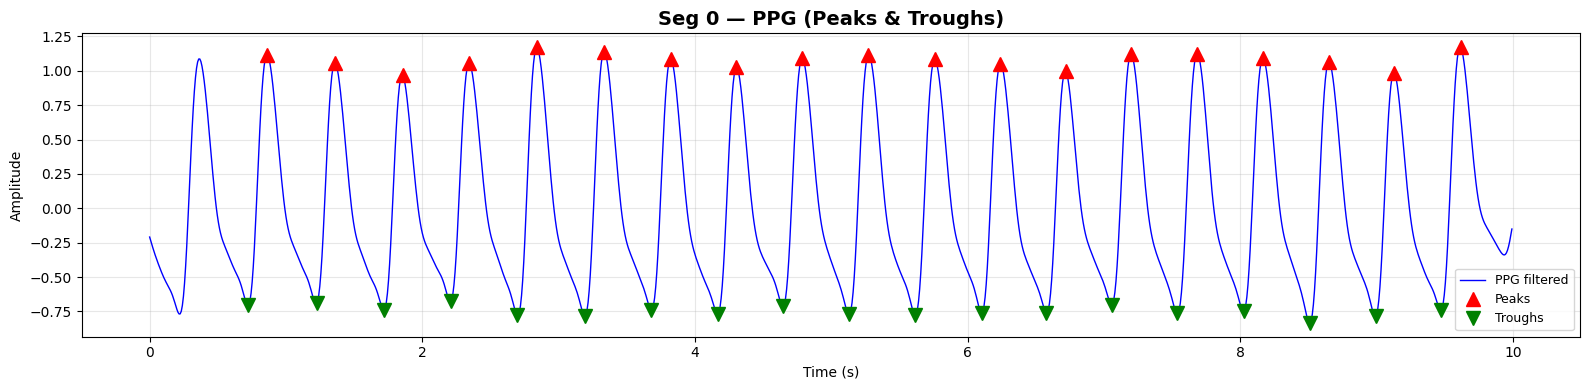

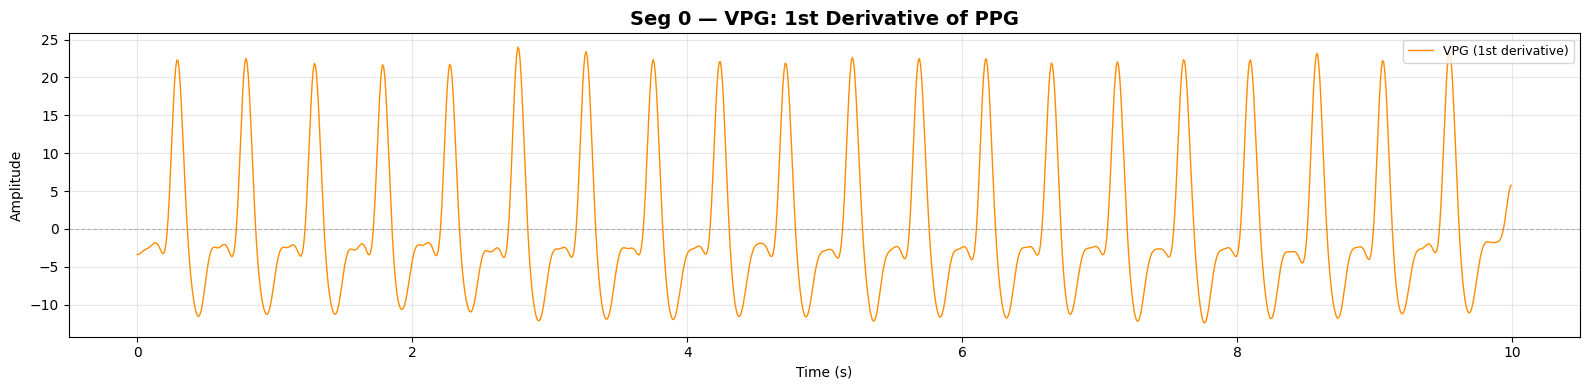

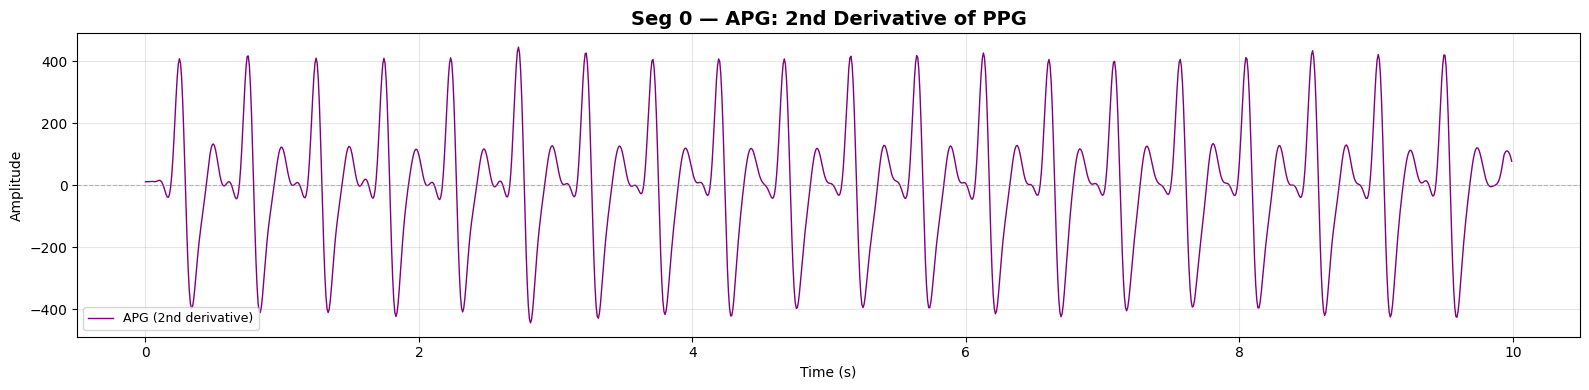

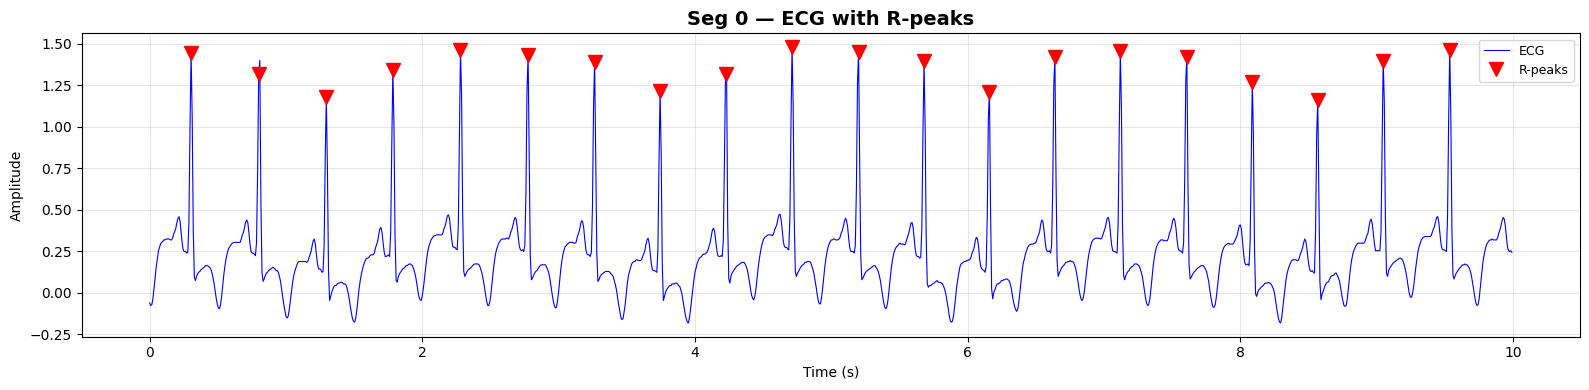

  ✅ Segment 0 — 4 figures saved.

  Seg 10 | SBP=129 DBP=70


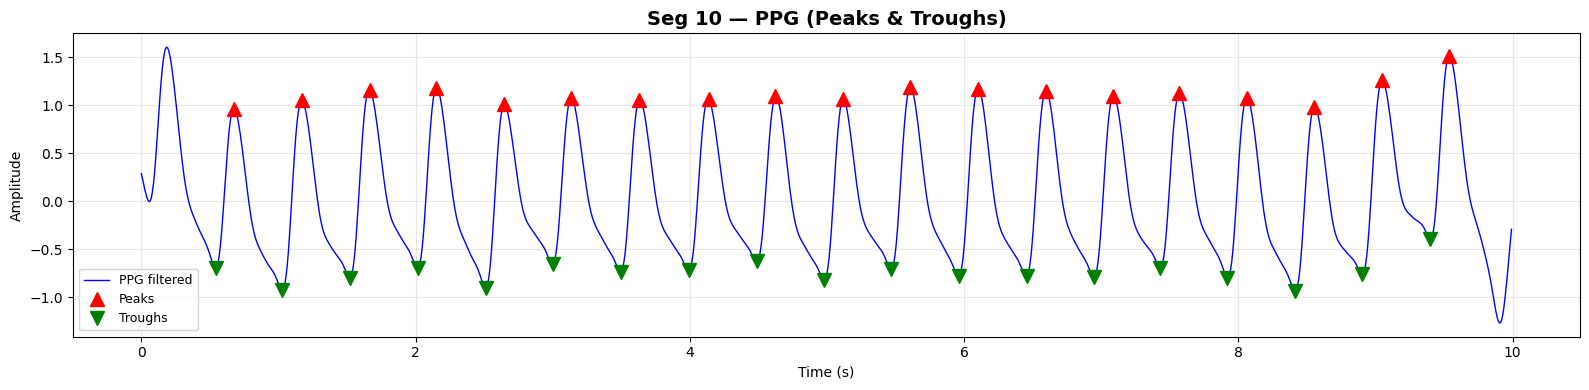

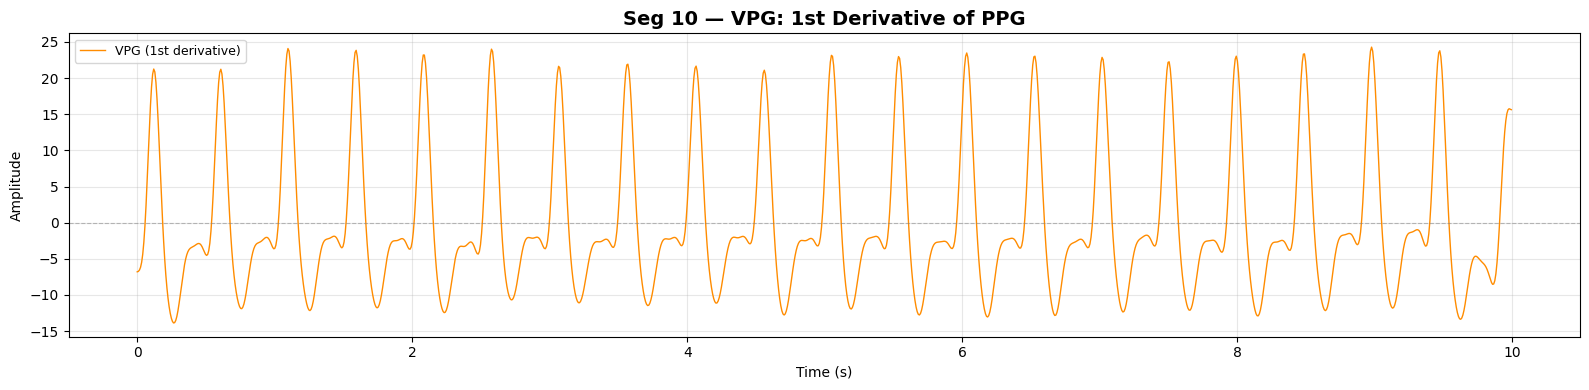

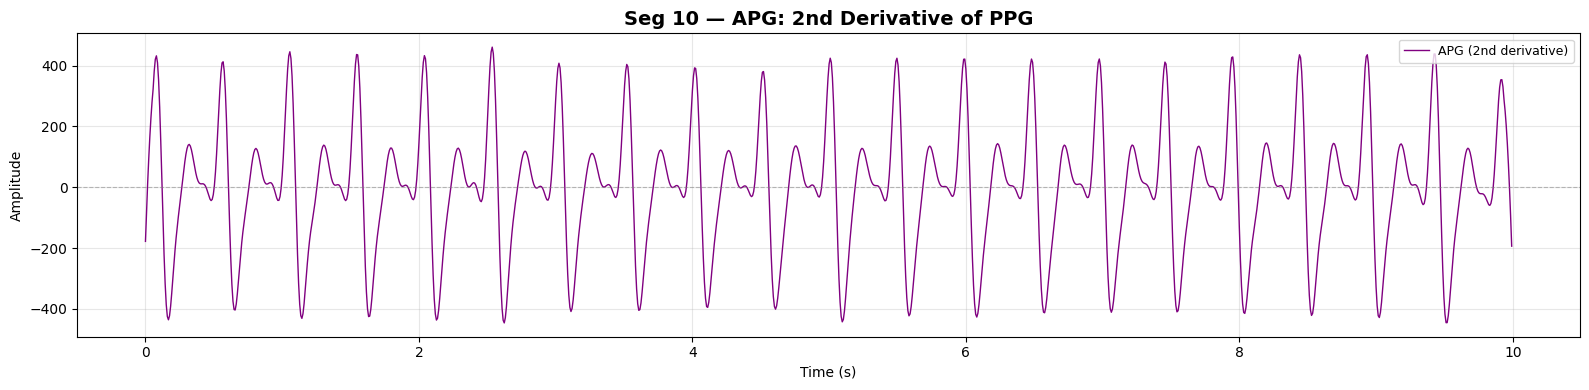

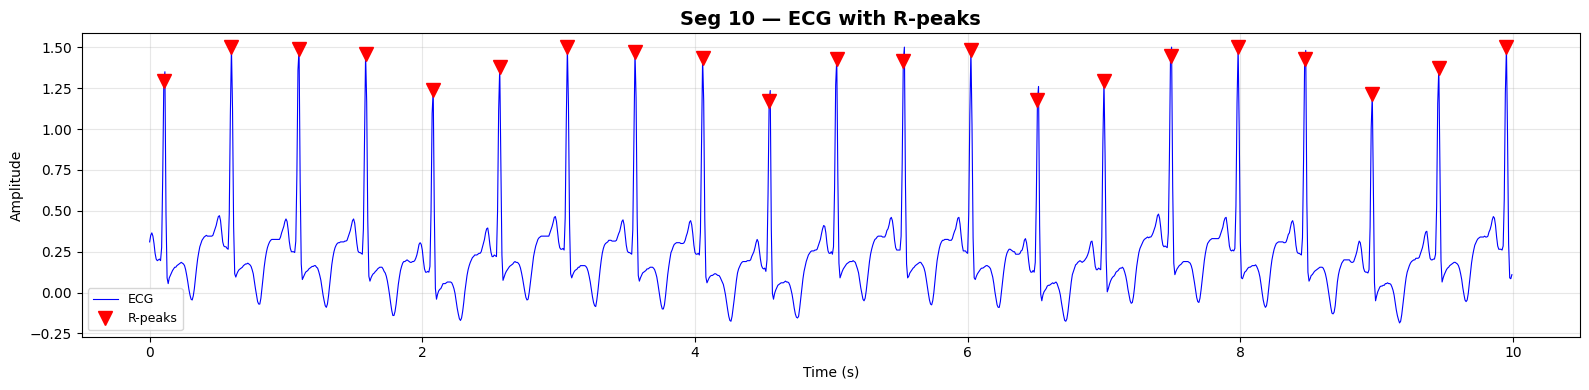

  ✅ Segment 10 — 4 figures saved.

  Seg 50 | SBP=136 DBP=74


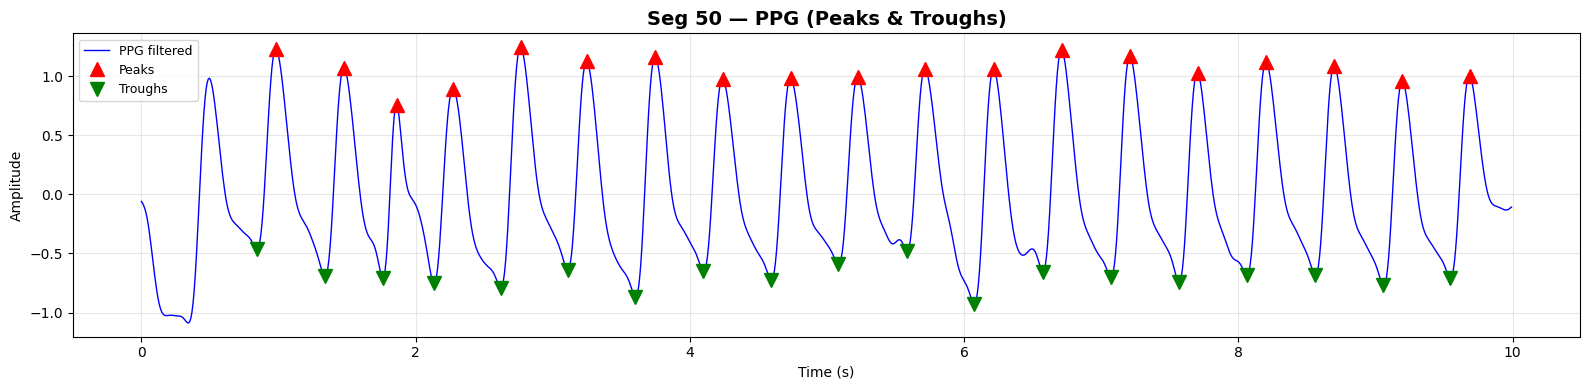

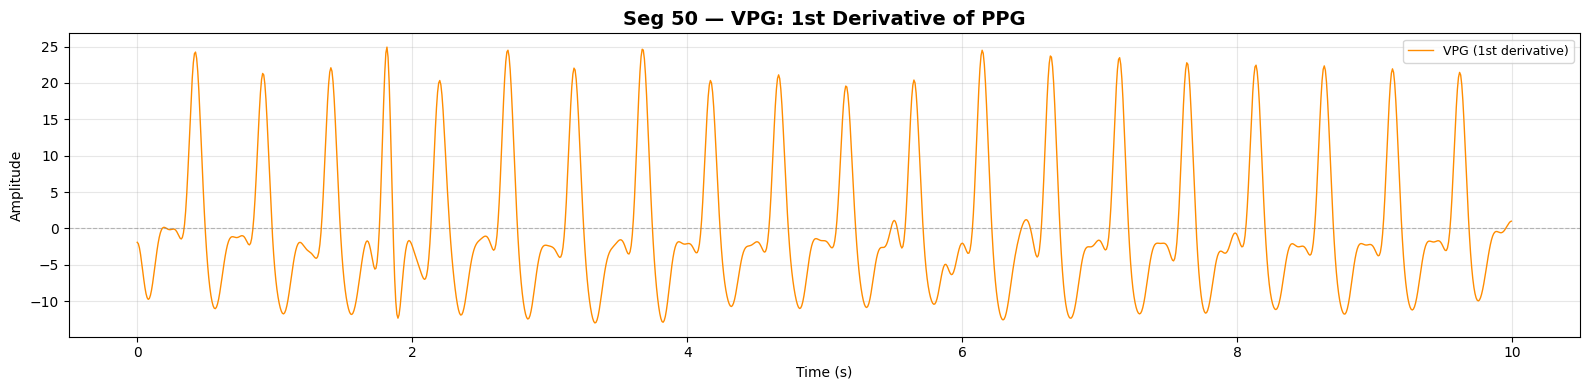

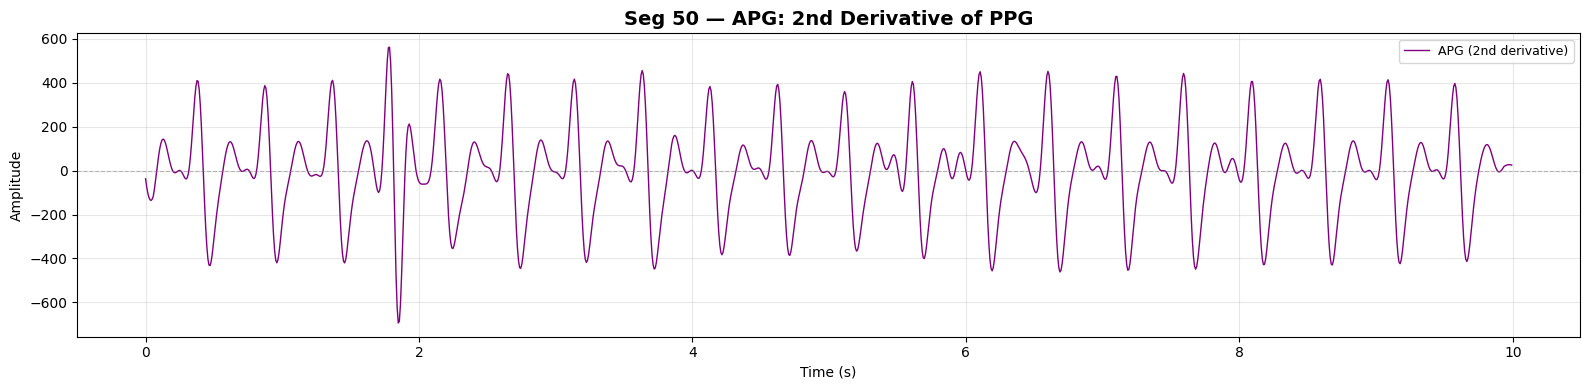

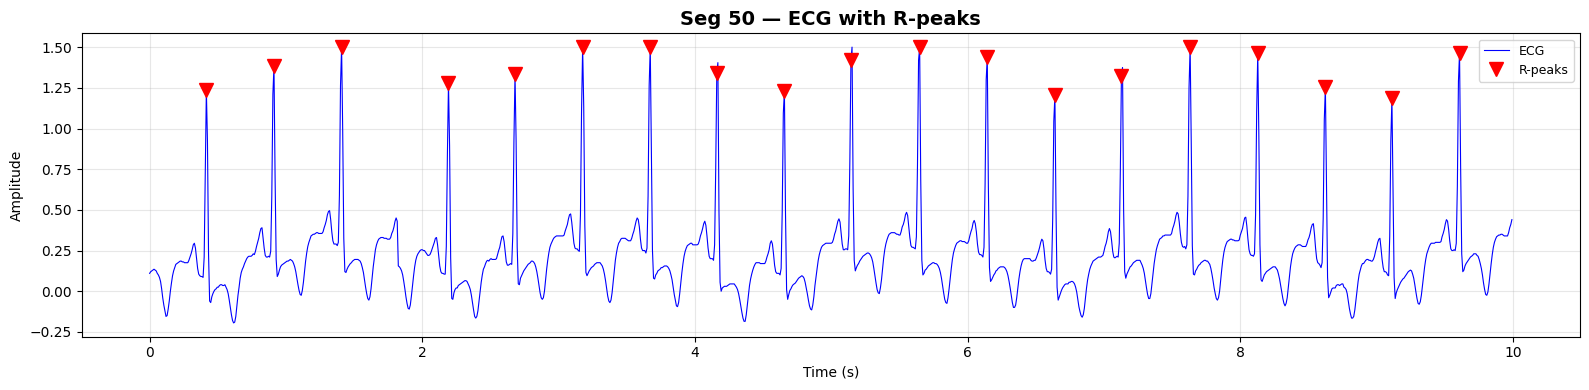

  ✅ Segment 50 — 4 figures saved.

  Seg 100 | SBP=131 DBP=68


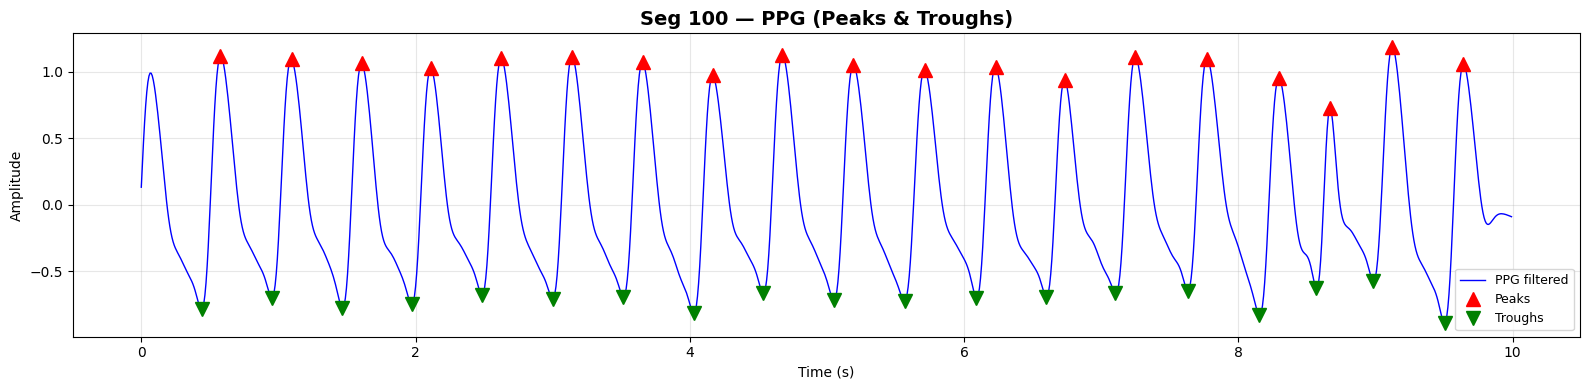

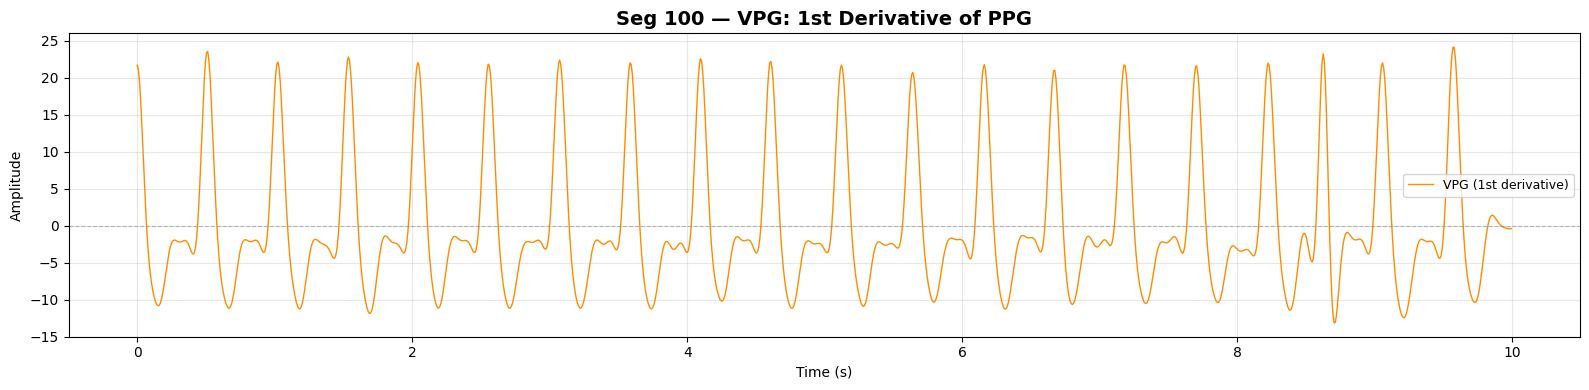

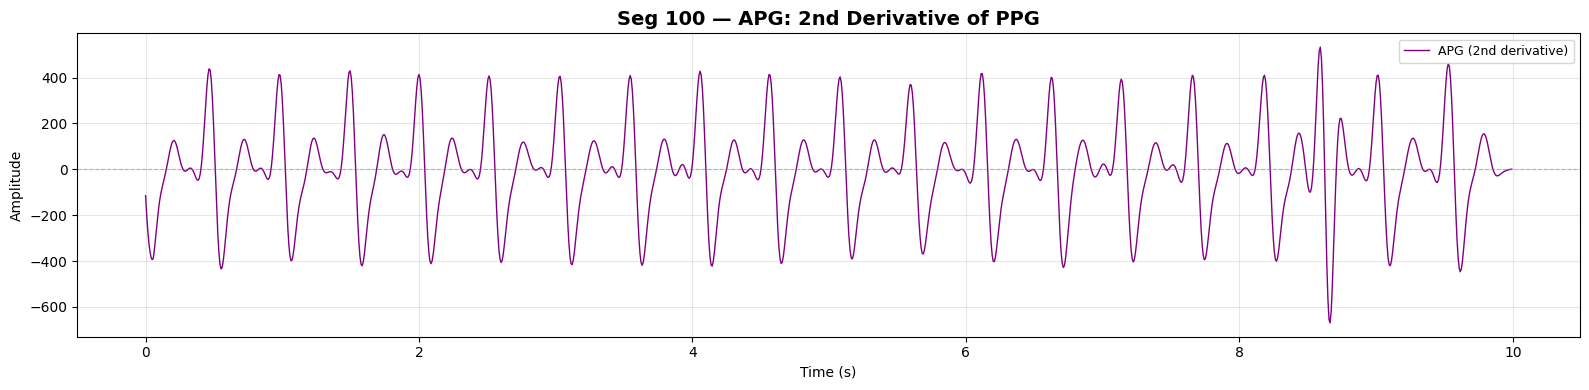

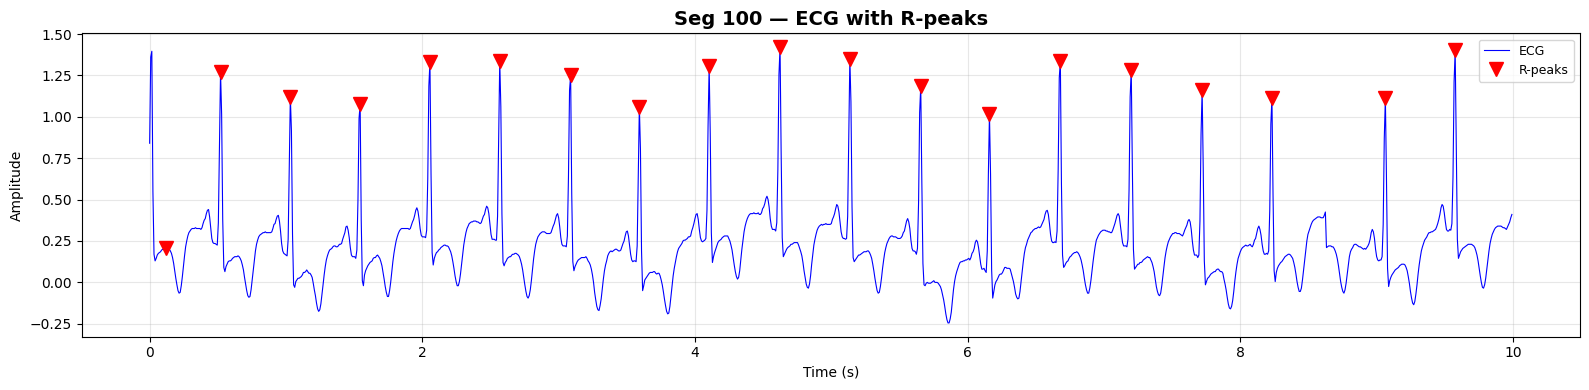

  ✅ Segment 100 — 4 figures saved.

  Seg 125 | SBP=131 DBP=69


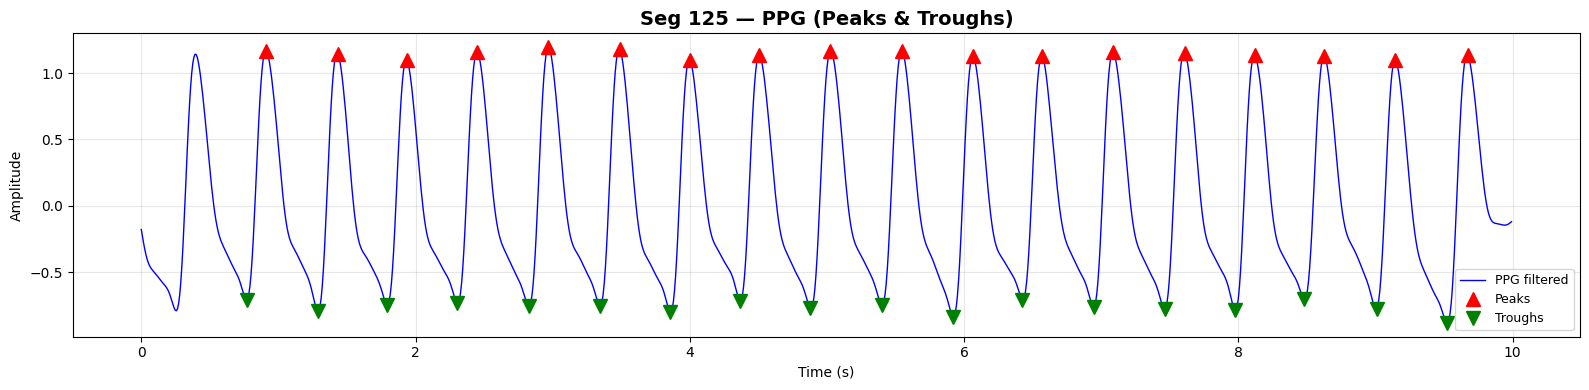

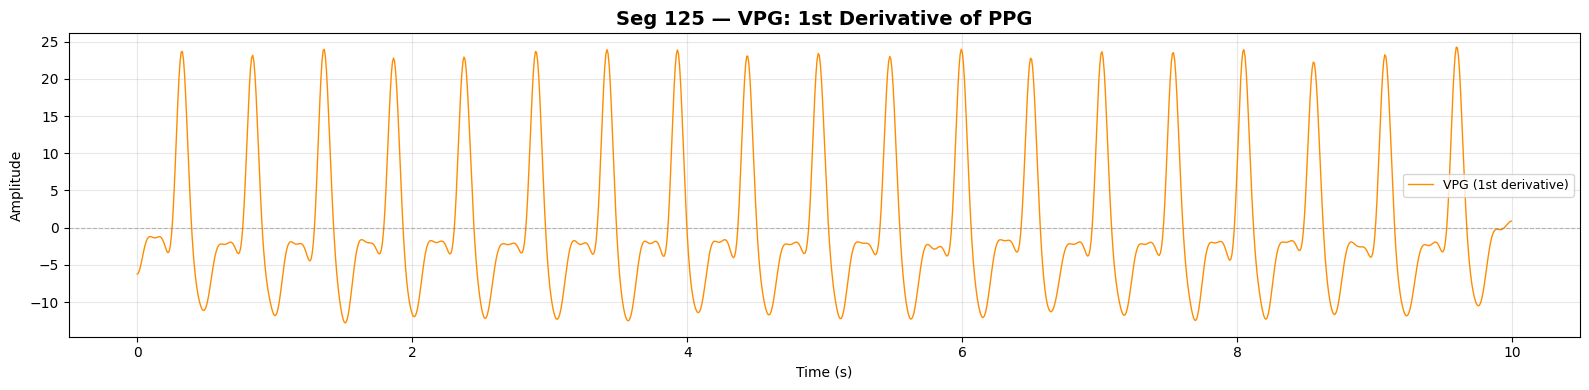

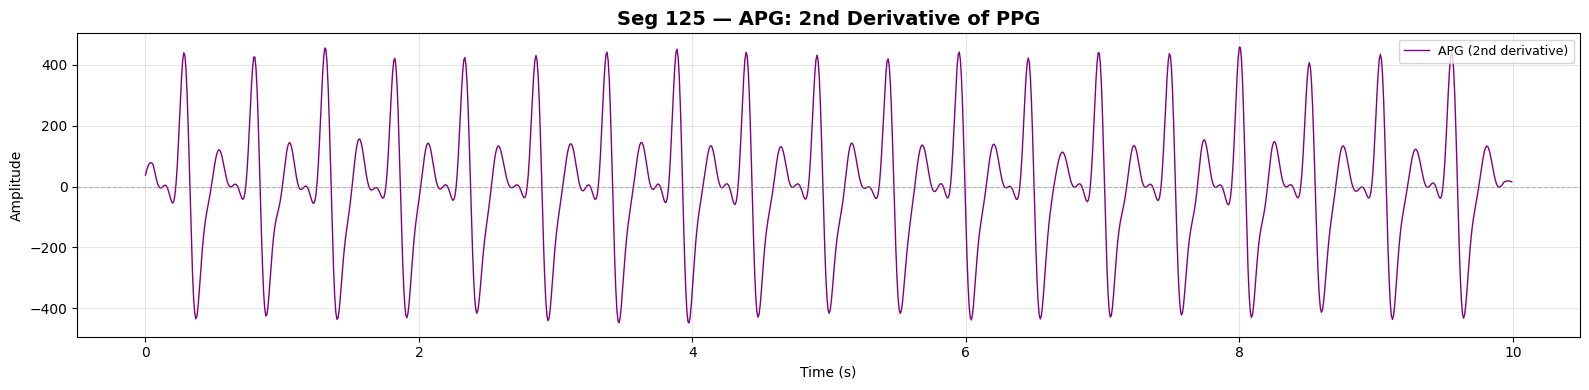

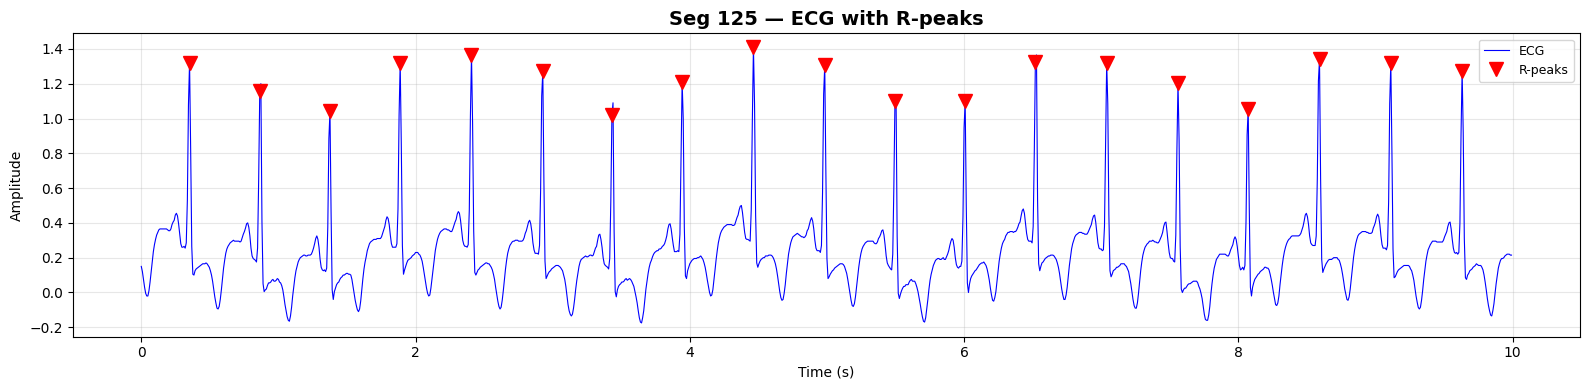

  ✅ Segment 125 — 4 figures saved.

  Seg 200 | SBP=113 DBP=59


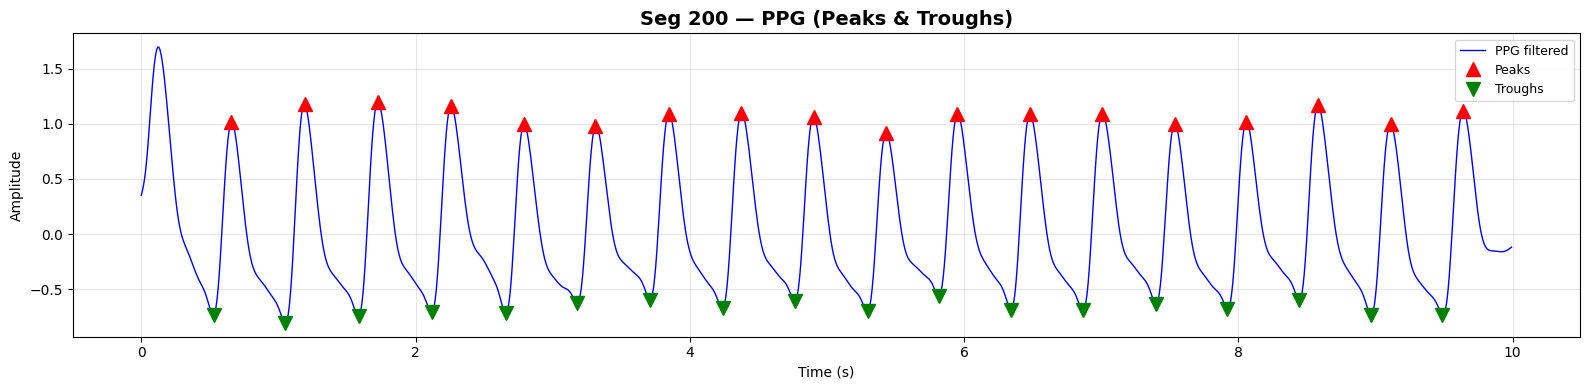

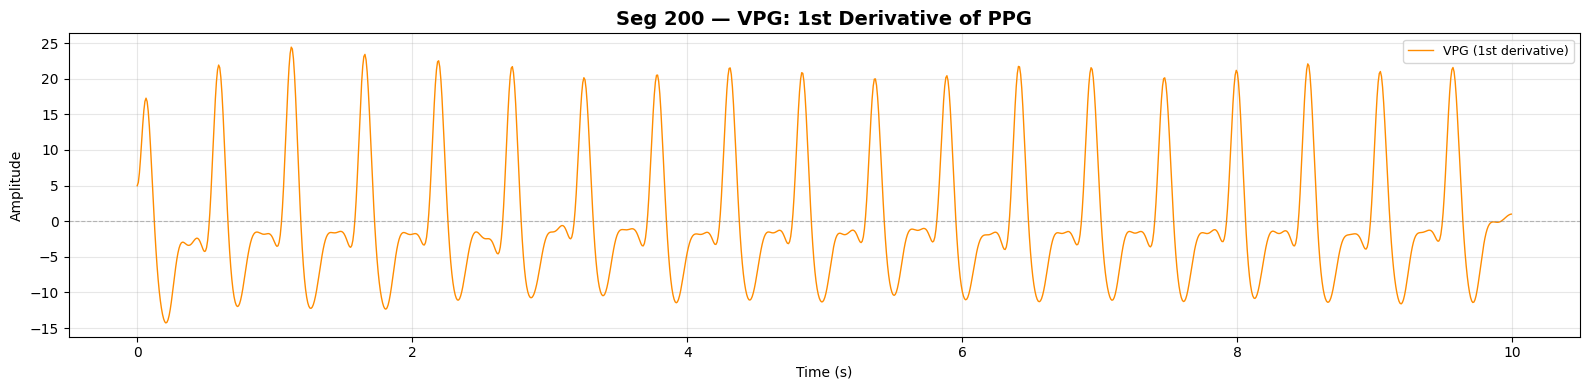

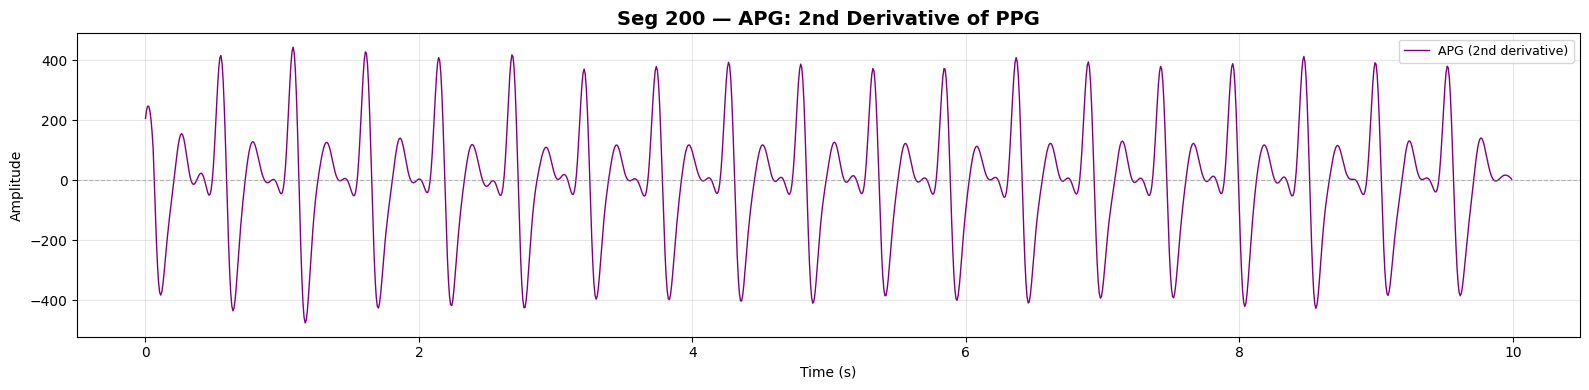

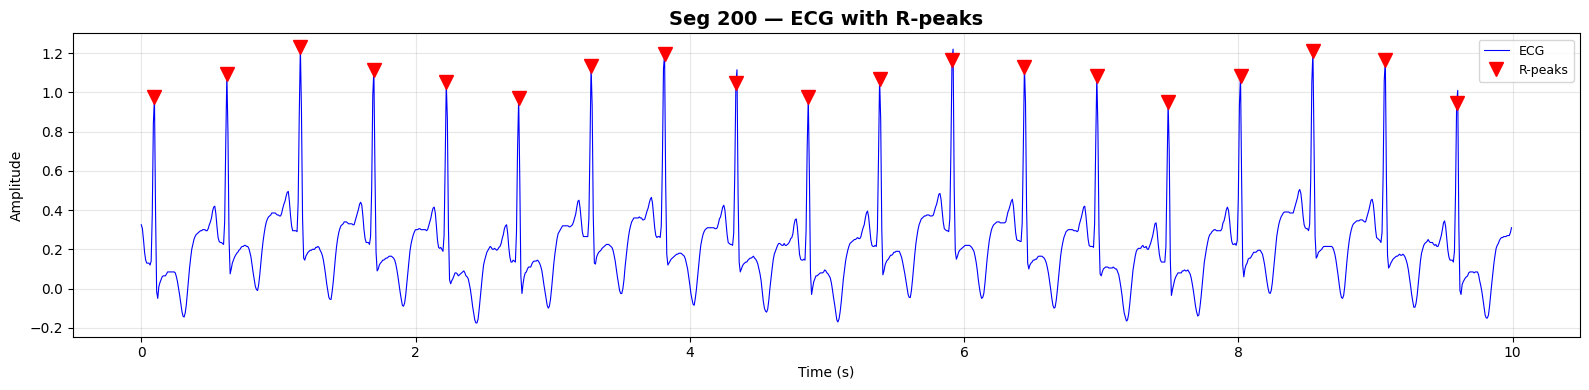

  ✅ Segment 200 — 4 figures saved.

  Seg 300 | SBP=128 DBP=71


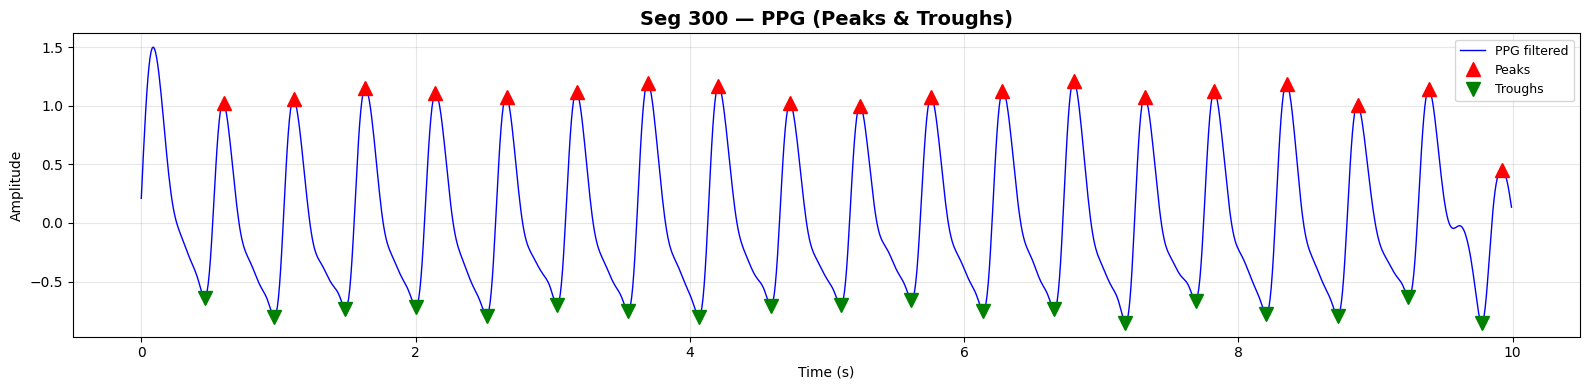

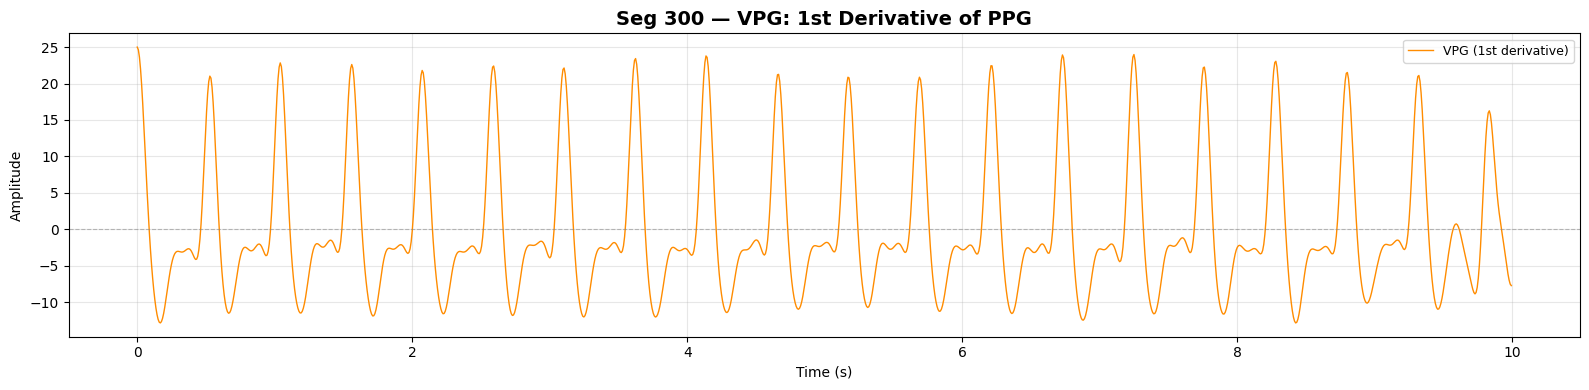

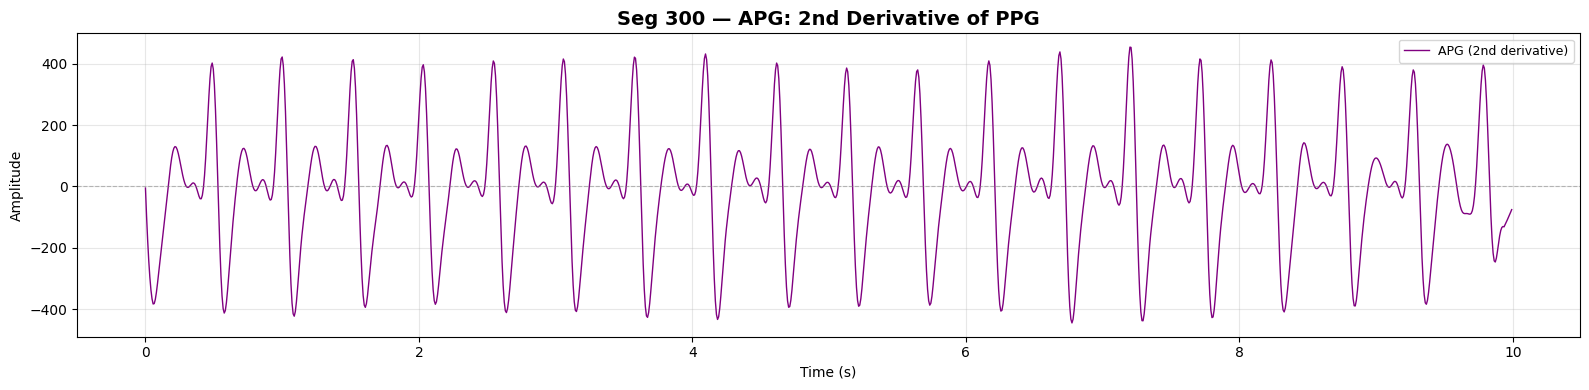

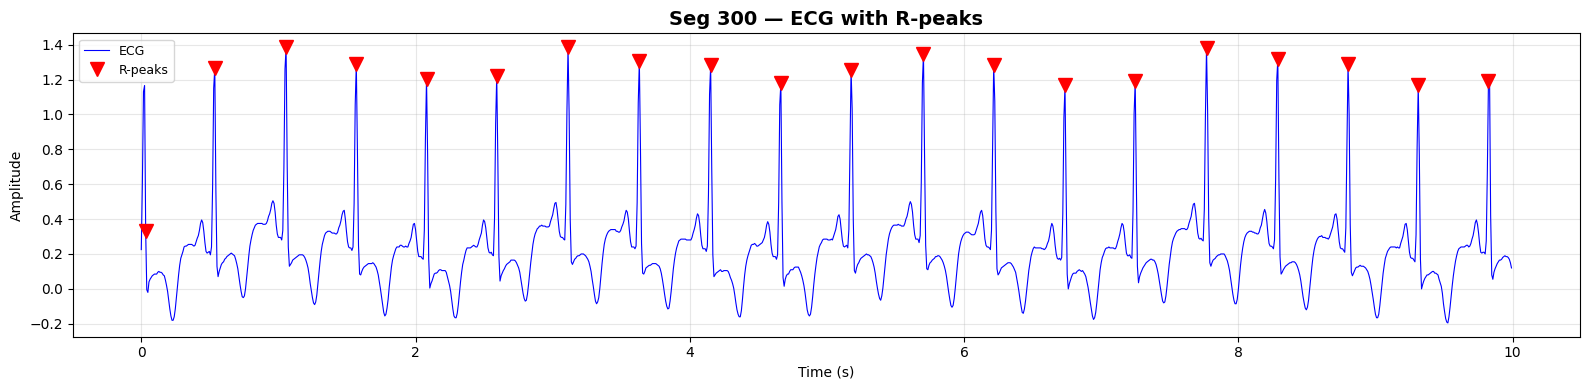

  ✅ Segment 300 — 4 figures saved.

  Seg 1000 | SBP=109 DBP=70


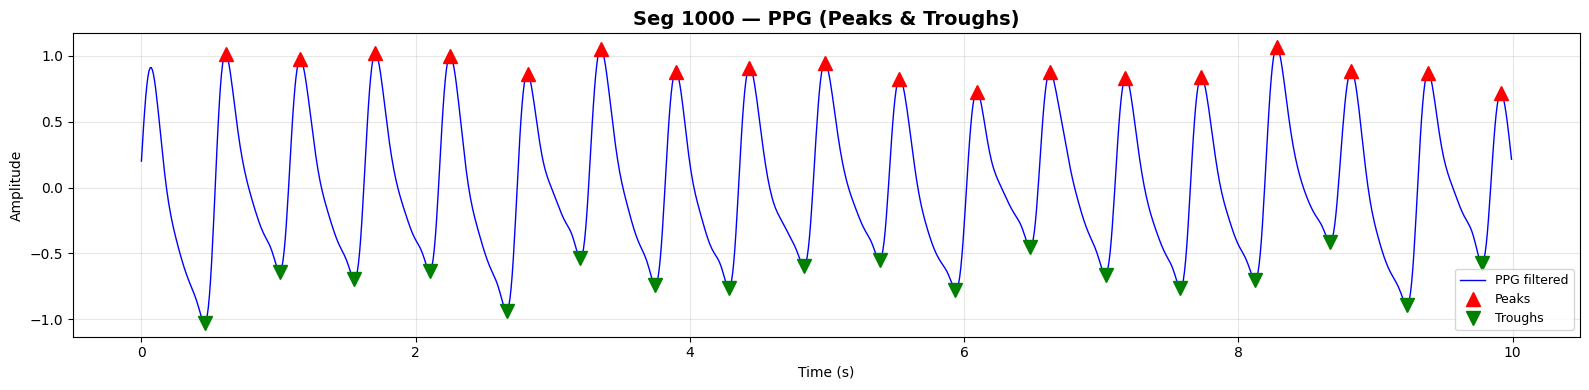

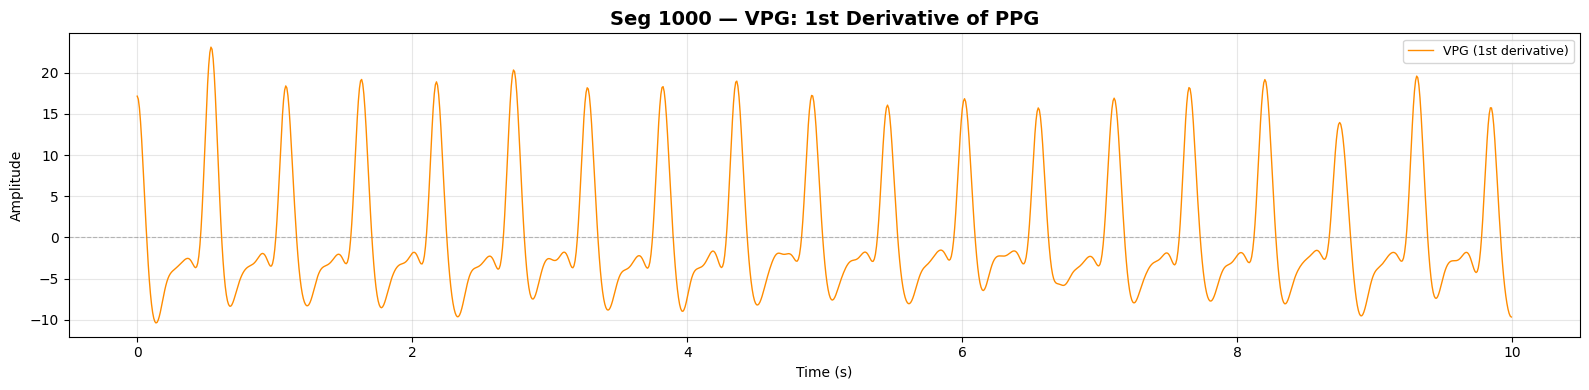

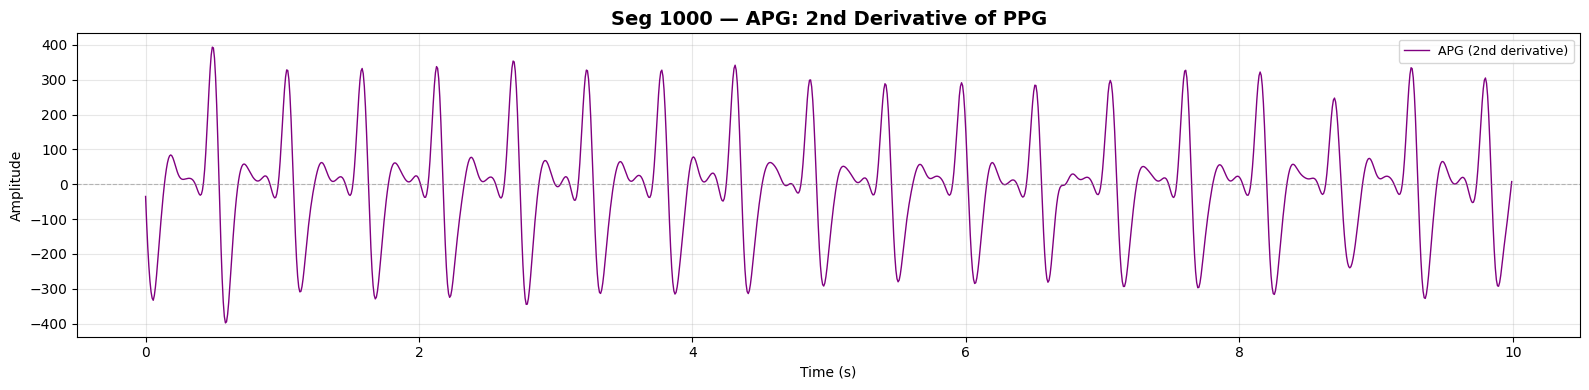

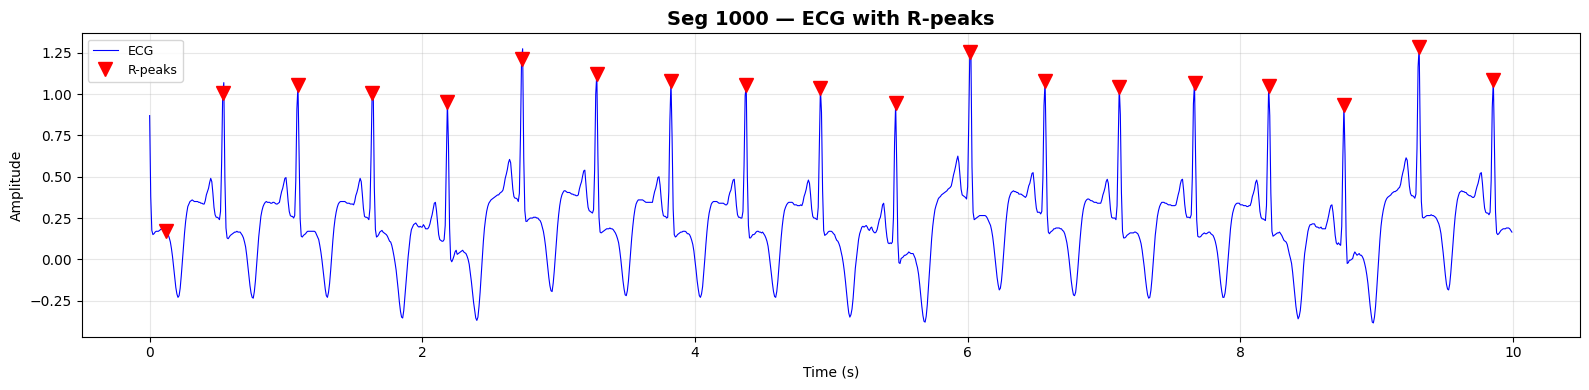

  ✅ Segment 1000 — 4 figures saved.

  Seg 5000 | SBP=122 DBP=76


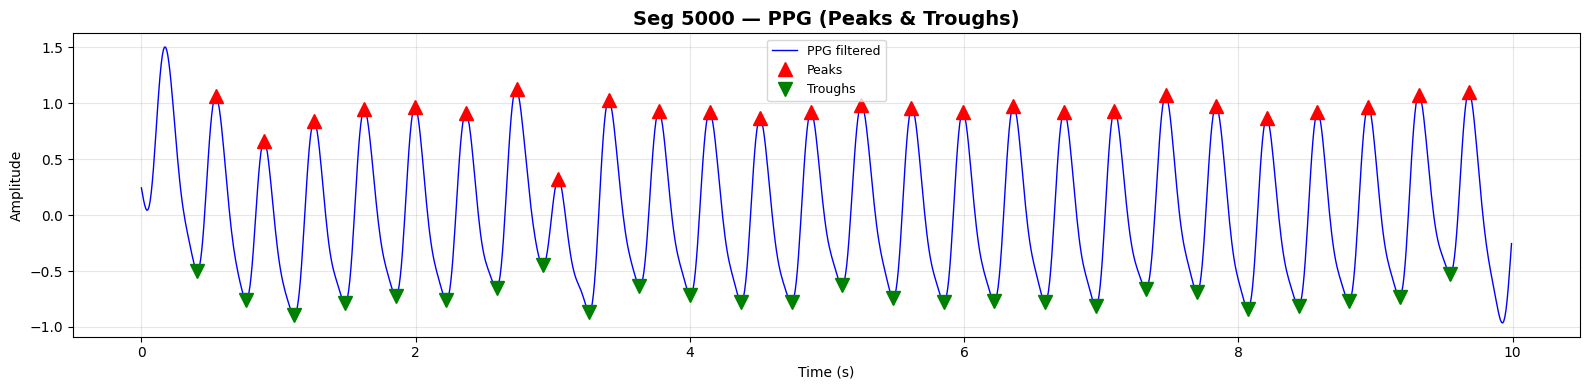

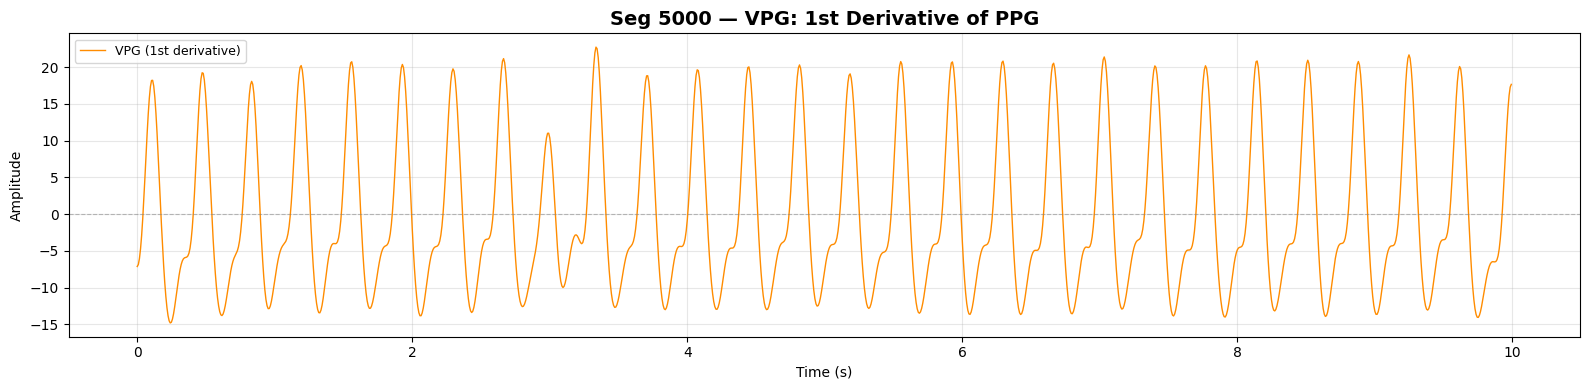

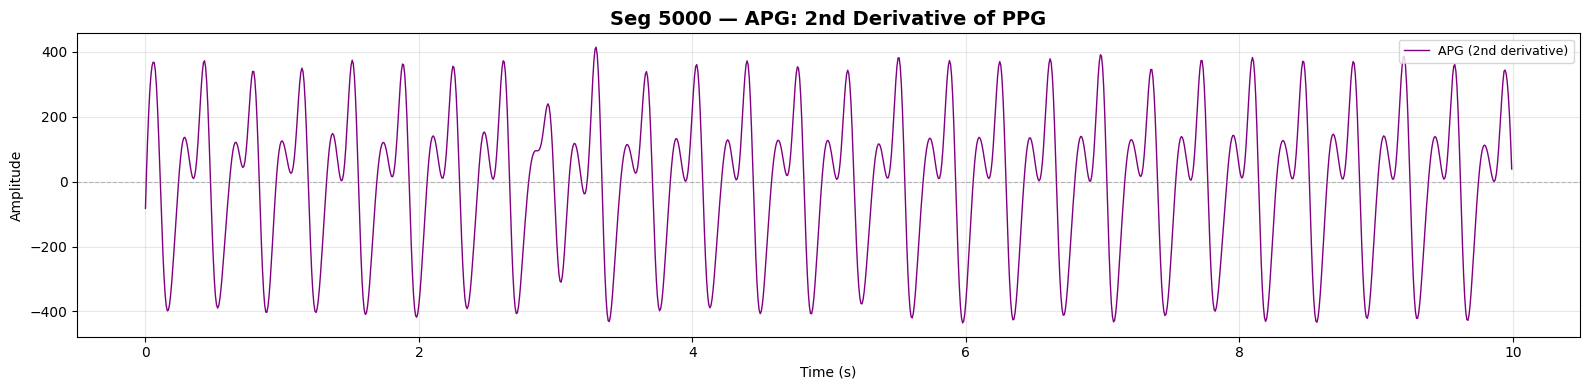

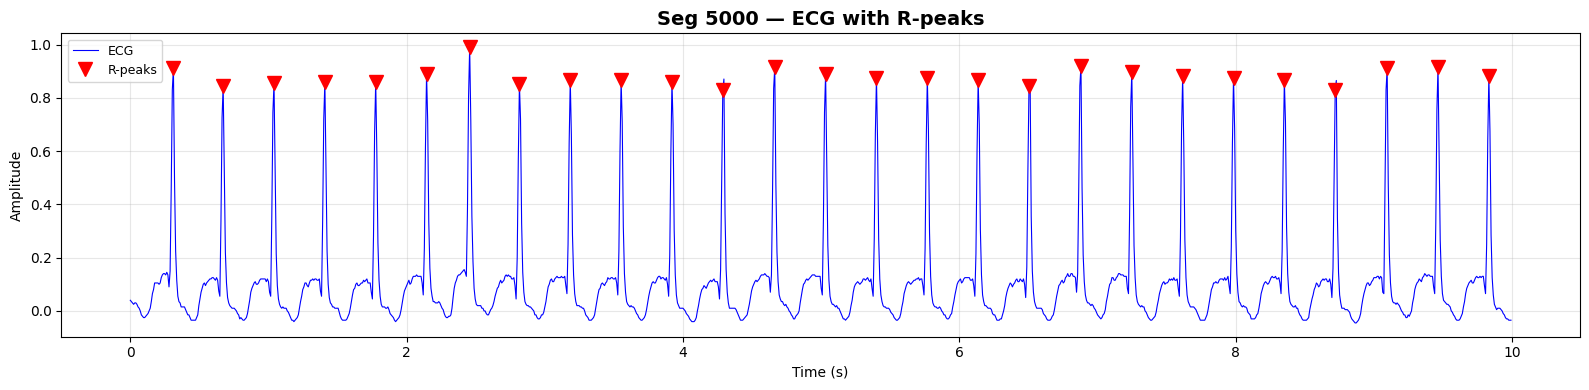

  ✅ Segment 5000 — 4 figures saved.

  Seg 10000 | SBP=122 DBP=57


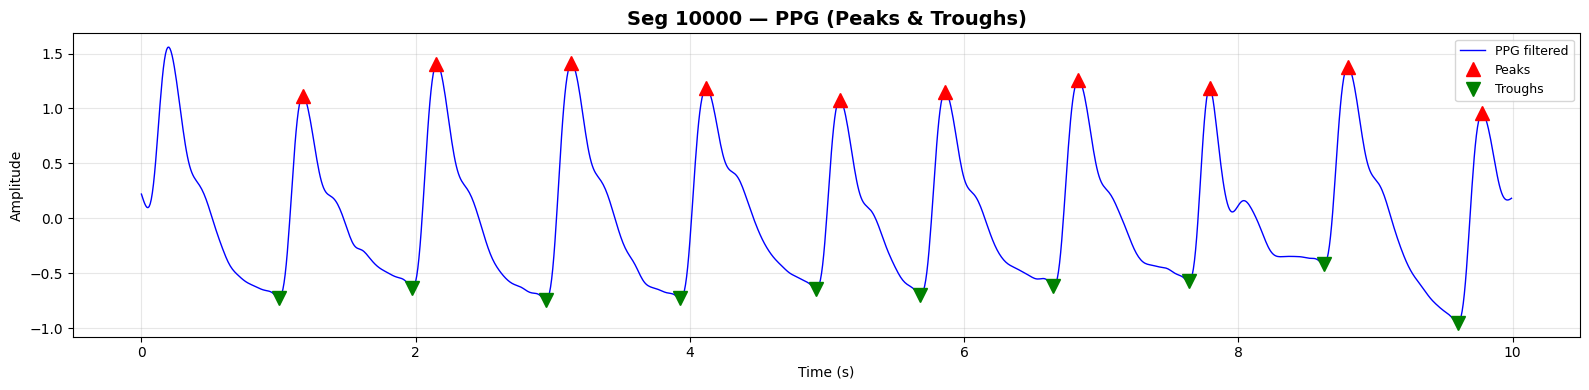

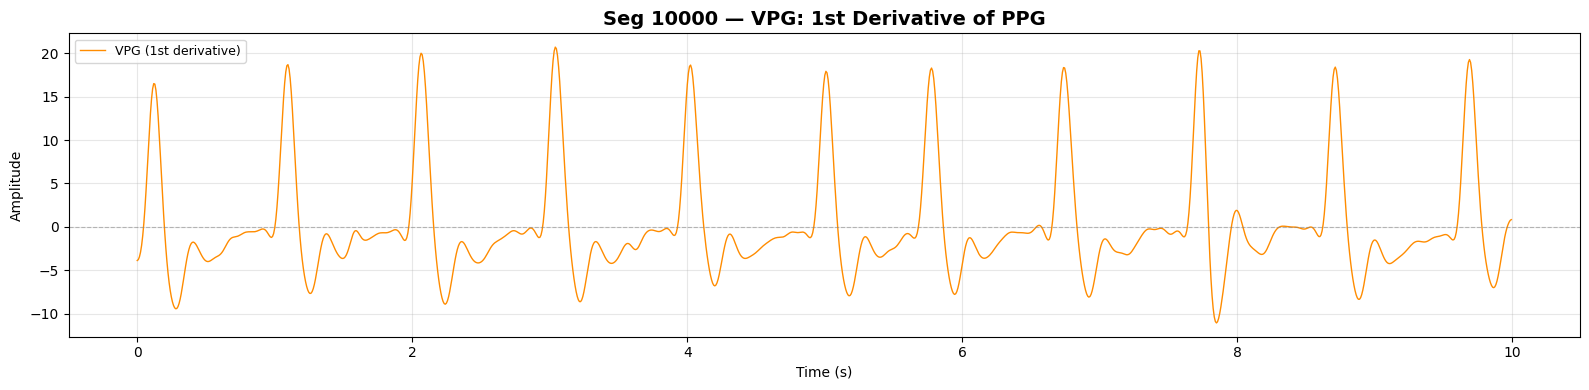

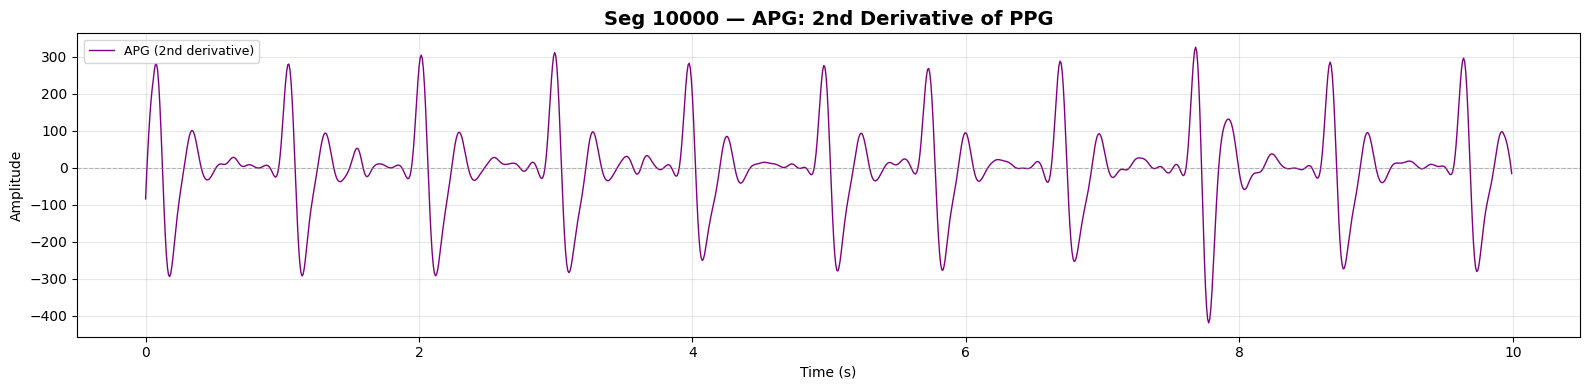

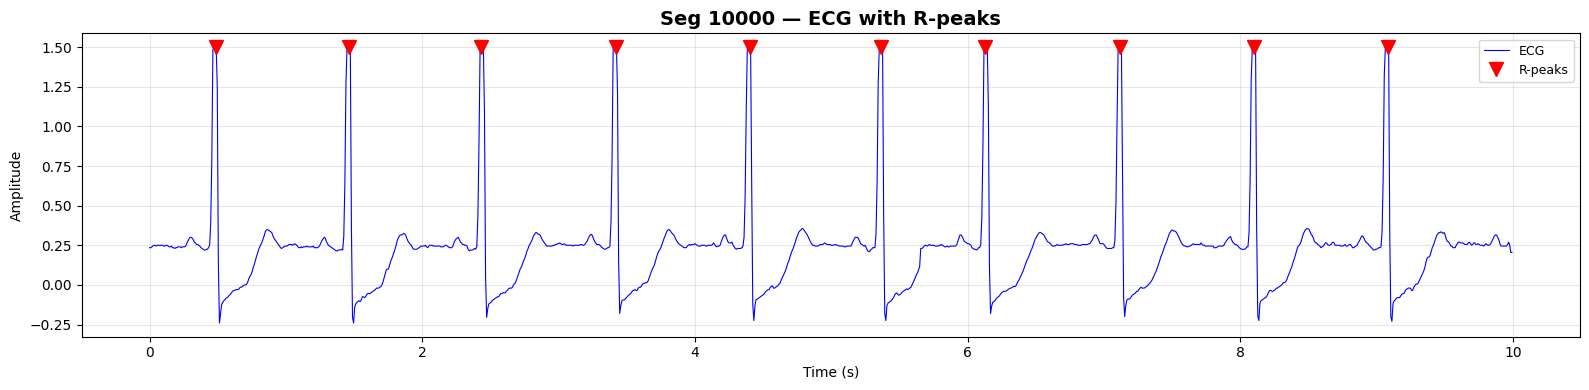

  ✅ Segment 10000 — 4 figures saved.


In [9]:
# Visualization: PPG + peaks/troughs, VPG, APG, ECG + R-peaks
import numpy as np, matplotlib.pyplot as plt
from scipy.signal import savgol_filter

def plot_signal_details(ppg_raw, ecg_raw, seg_idx, fs=125):
    t = np.arange(len(ppg_raw)) / fs

    # ── PPG filtered ──
    ppg_f = _bpf(ppg_raw, 0.5, 8.0, fs)
    if ppg_f is None:
        print(f"  ⚠️ Seg {seg_idx}: PPG filter failed, skip.")
        return

    # ── Detect PPG peaks & onsets ──
    beats = detect_ppg_beats(ppg_f, fs)
    ppg_peaks = np.array([b['peak'] for b in beats]) if beats else np.array([], dtype=int)
    ppg_onsets = np.array([b['onset'] for b in beats]) if beats else np.array([], dtype=int)

    # ── VPG: 1st derivative ──
    vpg = np.gradient(ppg_f, 1.0 / fs)

    # ── APG: 2nd derivative ──
    sg_win = min(15, len(vpg) // 2 * 2 - 1)
    if sg_win < 5: sg_win = 5
    apg = savgol_filter(vpg, sg_win, 3, deriv=1, delta=1.0 / fs)

    # ── ECG R-peaks ──
    rp = detect_rpeaks(ecg_raw, fs)

    # ── FIGURE 1: PPG + Peaks & Onsets ──
    fig, ax = plt.subplots(figsize=(16, 4))
    ax.plot(t, ppg_f, 'b-', lw=1, label='PPG filtered')
    if len(ppg_peaks):
        ax.plot(t[ppg_peaks], ppg_f[ppg_peaks], 'r^', ms=10, label=f'Peaks')
    if len(ppg_onsets):
        ax.plot(t[ppg_onsets], ppg_f[ppg_onsets], 'gv', ms=10, label=f'Troughs')
    ax.set_title(f'Seg {seg_idx} — PPG (Peaks & Troughs)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Amplitude')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/seg{seg_idx}_ppg.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── FIGURE 2: VPG (1st derivative) ──
    fig, ax = plt.subplots(figsize=(16, 4))
    ax.plot(t, vpg, 'darkorange', lw=1, label='VPG (1st derivative)')
    ax.axhline(0, color='gray', ls='--', lw=0.8, alpha=0.5)
    ax.set_title(f'Seg {seg_idx} — VPG: 1st Derivative of PPG', fontsize=14, fontweight='bold')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Amplitude')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/seg{seg_idx}_vpg.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── FIGURE 3: APG (2nd derivative) ──
    fig, ax = plt.subplots(figsize=(16, 4))
    ax.plot(t, apg, 'purple', lw=1, label='APG (2nd derivative)')
    ax.axhline(0, color='gray', ls='--', lw=0.8, alpha=0.5)
    ax.set_title(f'Seg {seg_idx} — APG: 2nd Derivative of PPG', fontsize=14, fontweight='bold')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Amplitude')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/seg{seg_idx}_apg.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── FIGURE 4: ECG + R-peaks ──
    fig, ax = plt.subplots(figsize=(16, 4))
    ax.plot(t, ecg_raw, 'b-', lw=0.8, label='ECG')
    if len(rp):
        ax.plot(t[rp], ecg_raw[rp], 'rv', ms=10, label=f'R-peaks')
    ax.set_title(f'Seg {seg_idx} — ECG with R-peaks', fontsize=14, fontweight='bold')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Amplitude')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/seg{seg_idx}_ecg.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"  ✅ Segment {seg_idx} — 4 figures saved.")

# ═══ RUN ═══
print("=" * 60 + "\n  SIGNAL VISUALIZATION\n" + "=" * 60)
for si in [0, 10, 50, 100, 125, 200, 300, 1000, 5000, 10000]:
    if si < len(all_segments):
        seg = all_segments[si]
        print(f"\n  Seg {si} | SBP={seg['sbp']:.0f} DBP={seg['dbp']:.0f}")
        plot_signal_details(seg['ppg'], seg['ecg'], si, FS)


In [ ]:
# Quick correlation check
from scipy.stats import pearsonr
for fi, fn in enumerate(X_df.columns):
    r_sbp, _ = pearsonr(X[:, fi], y[:, 0])
    r_dbp, _ = pearsonr(X[:, fi], y[:, 1])
    print(f"  {fn:<15s}  SBP r={r_sbp:+.3f}  DBP r={r_dbp:+.3f}")


cell 4 - Split

In [ ]:
# CELL 4 — Data info (NO preprocessing — done inside fold loops)
import numpy as np
from sklearn.model_selection import GroupKFold

print(f"  Data: {X.shape[0]:,} segments, {X.shape[1]} features, {len(np.unique(groups)):,} records")
print(f"  PPG:  {PPG_raw.shape} ({PPG_raw.nbytes/1e6:.0f} MB)")
print(f"  BP range: SBP [{y[:,0].min():.0f}, {y[:,0].max():.0f}] DBP [{y[:,1].min():.0f}, {y[:,1].max():.0f}]")
print(f"  ⚠ Impute/Scale happens INSIDE each fold (no leakage)")



  Data: 513,472 segments, 22 features, 10,859 records
  BP range: SBP [70, 198] DBP [50, 120]

  N_CAL = 10
  Delta: 418,595 segs (8,122 subjects)
  Fold 0: cal_only=5.59/3.14  XGB=5.25/2.88  LGB=5.25/2.87  RF=5.26/2.88  Ridge=5.48/3.00  ENet=5.47/3.00  W_Stack=5.27/2.88
  Fold 1: cal_only=5.42/2.95  XGB=5.13/2.73  LGB=5.14/2.73  RF=5.19/2.76  Ridge=5.39/2.86  ENet=5.38/2.85  W_Stack=5.17/2.74
  Fold 2: cal_only=5.44/3.10  XGB=5.02/2.83  LGB=5.04/2.84  RF=5.09/2.87  Ridge=5.25/2.97  ENet=5.26/2.97  W_Stack=5.06/2.86
  Fold 3: cal_only=5.12/2.93  XGB=4.91/2.67  LGB=4.91/2.67  RF=4.93/2.67  Ridge=5.12/2.82  ENet=5.10/2.82  W_Stack=4.92/2.68
  Fold 4: cal_only=5.62/3.12  XGB=5.24/2.80  LGB=5.27/2.81  RF=5.32/2.84  Ridge=5.49/2.97  ENet=5.49/2.97  W_Stack=5.29/2.84
  Fold 5: cal_only=5.59/2.90  XGB=5.21/2.63  LGB=5.22/2.62  RF=5.25/2.64  Ridge=5.43/2.77  ENet=5.43/2.77  W_Stack=5.23/2.65
  Fold 6: cal_only=5.62/2.96  XGB=5.25/2.64  LGB=5.25/2.64  RF=5.30/2.65  Ridge=5.44/2.76  ENet=5.43/2.

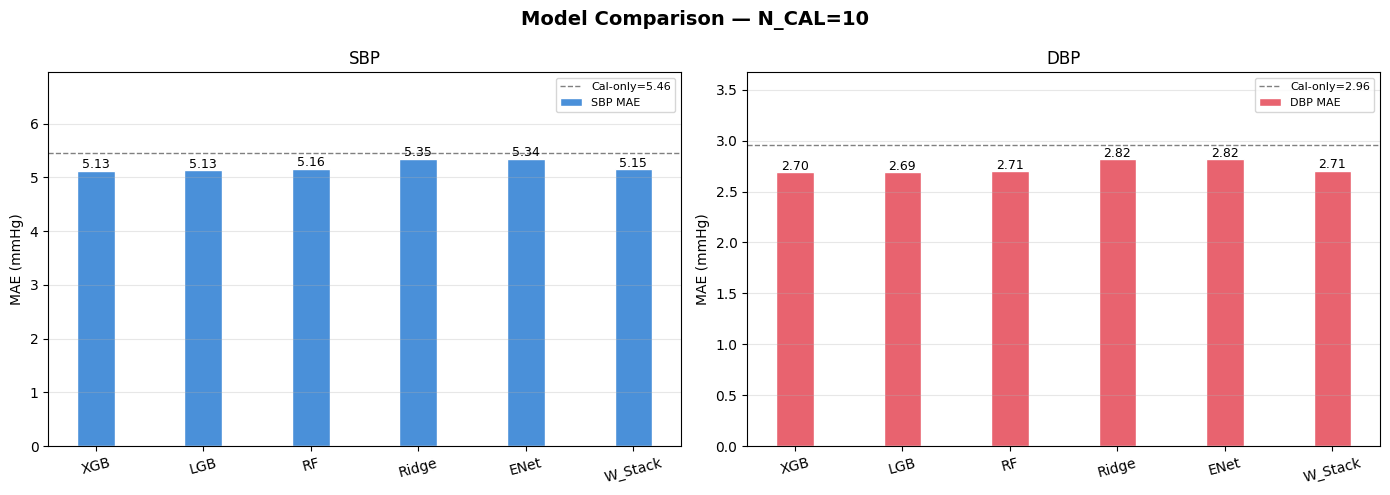

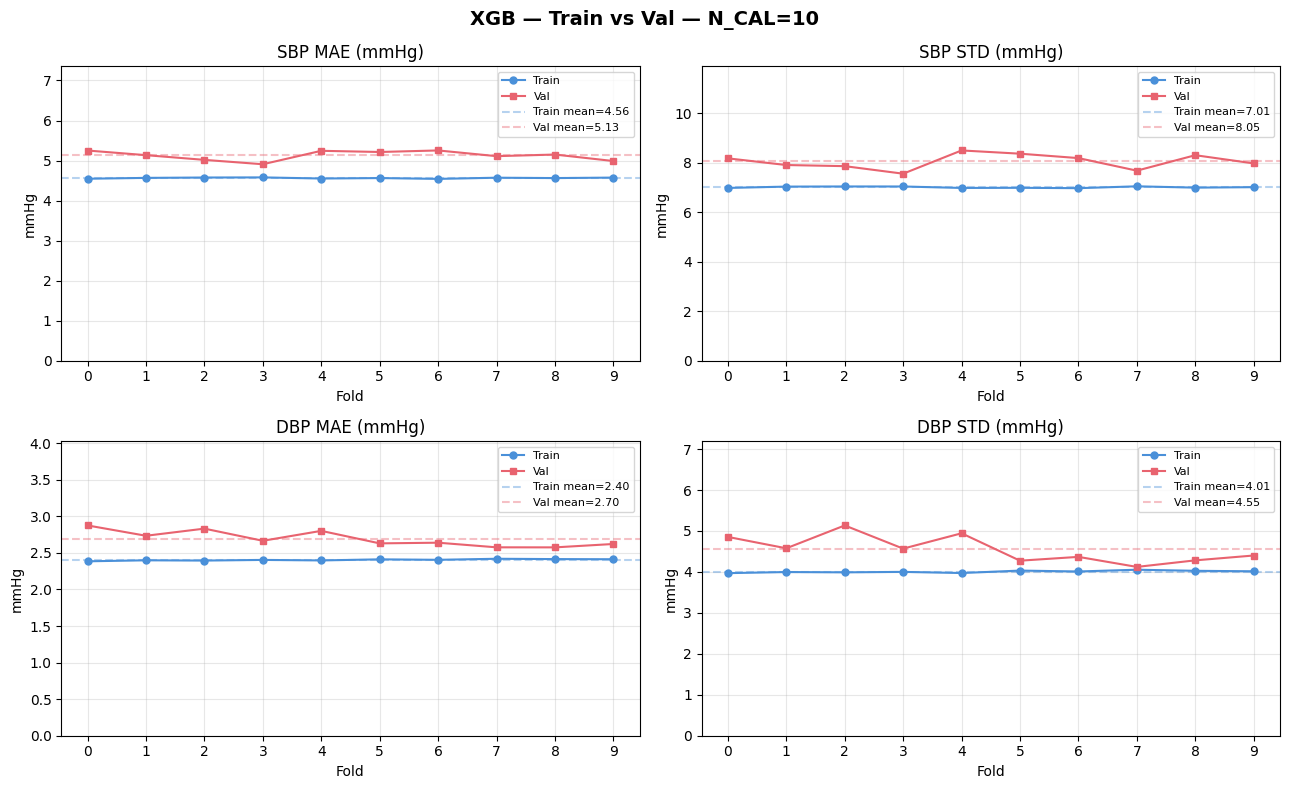

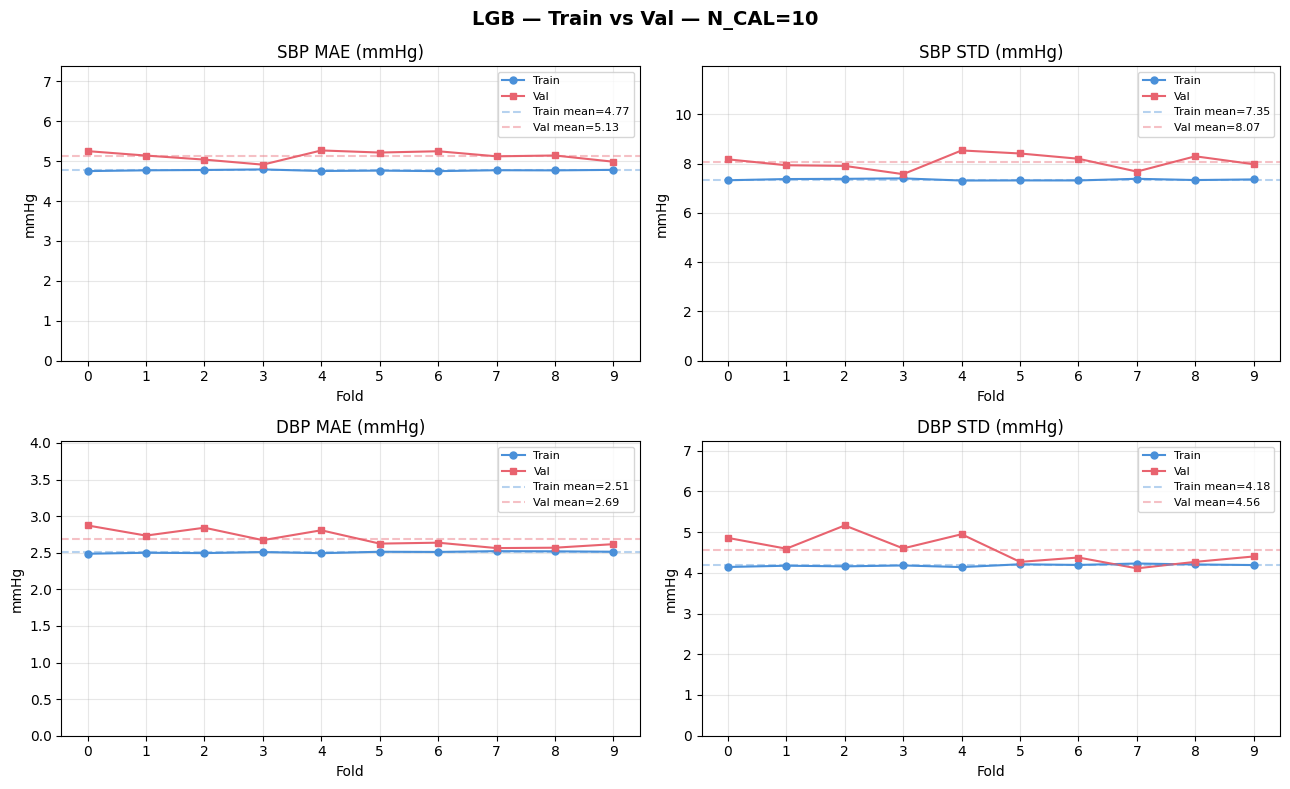

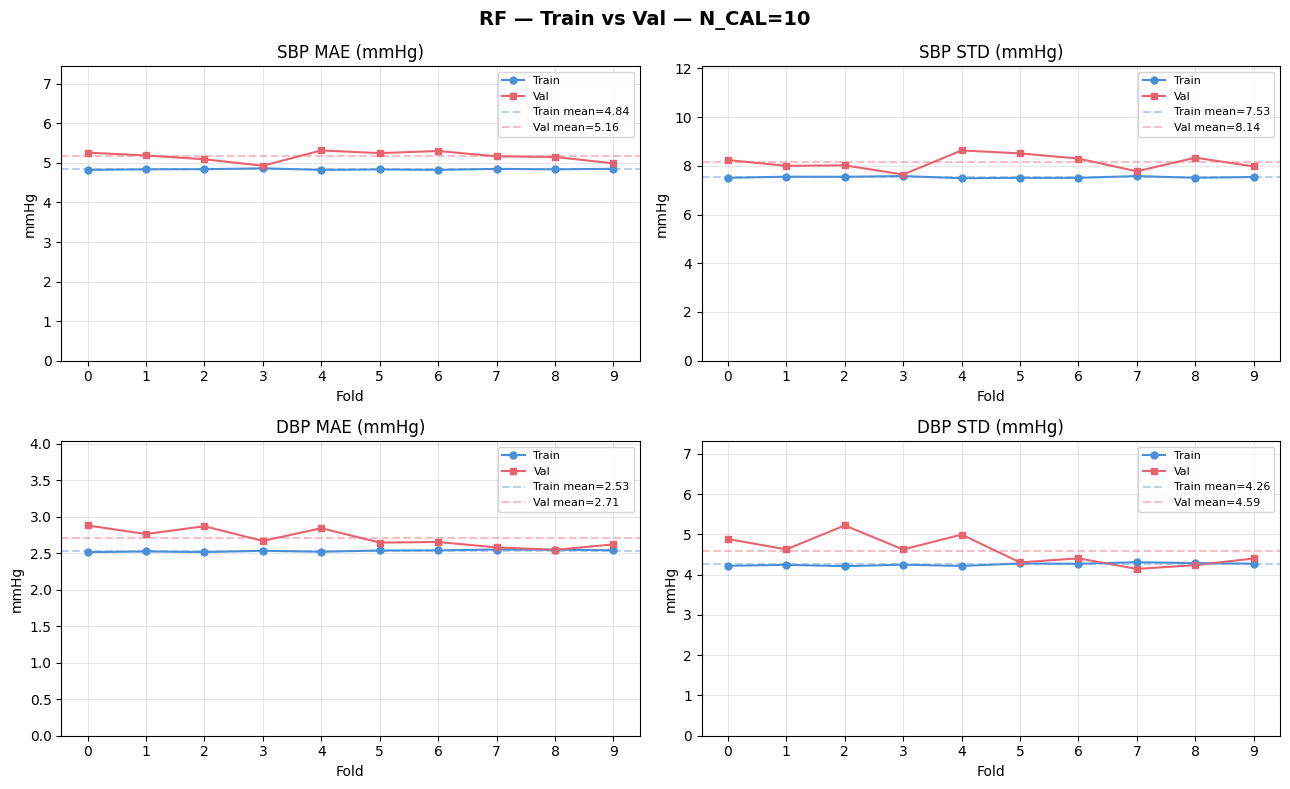

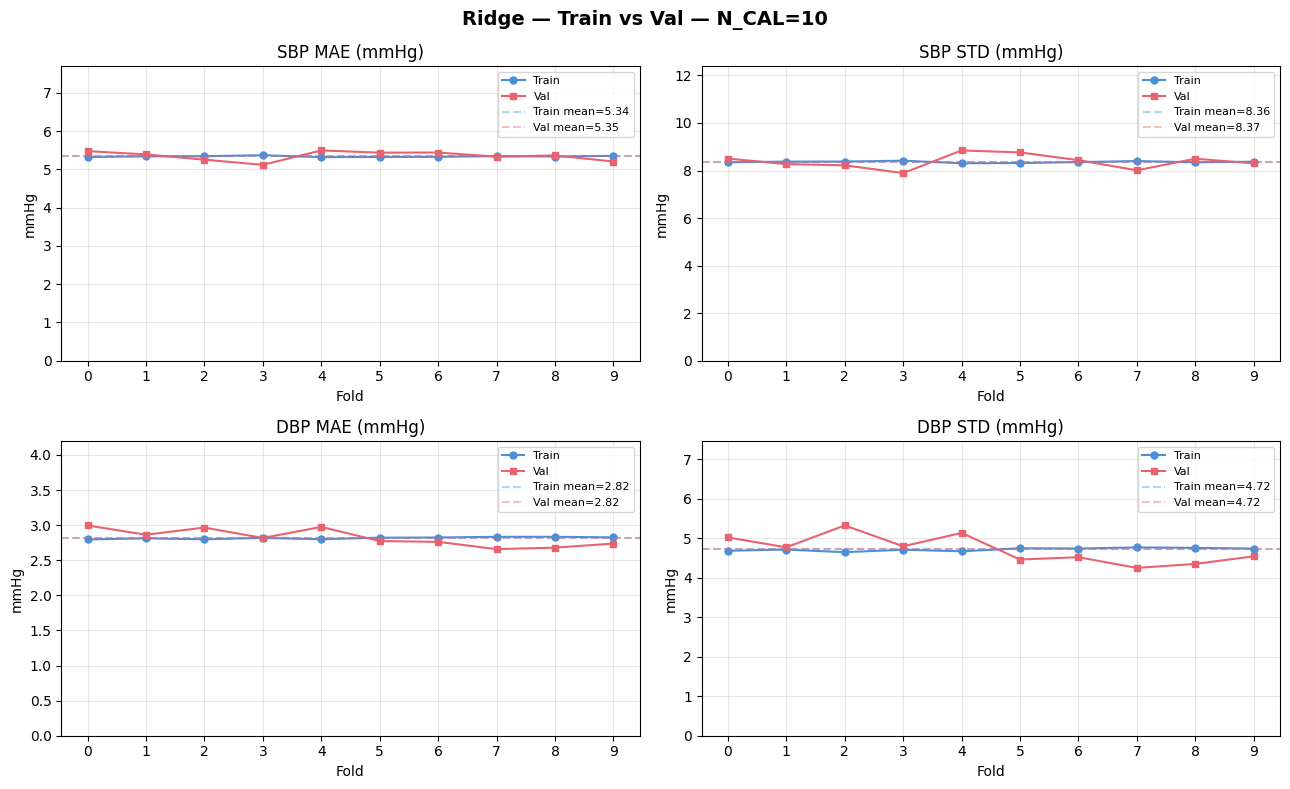

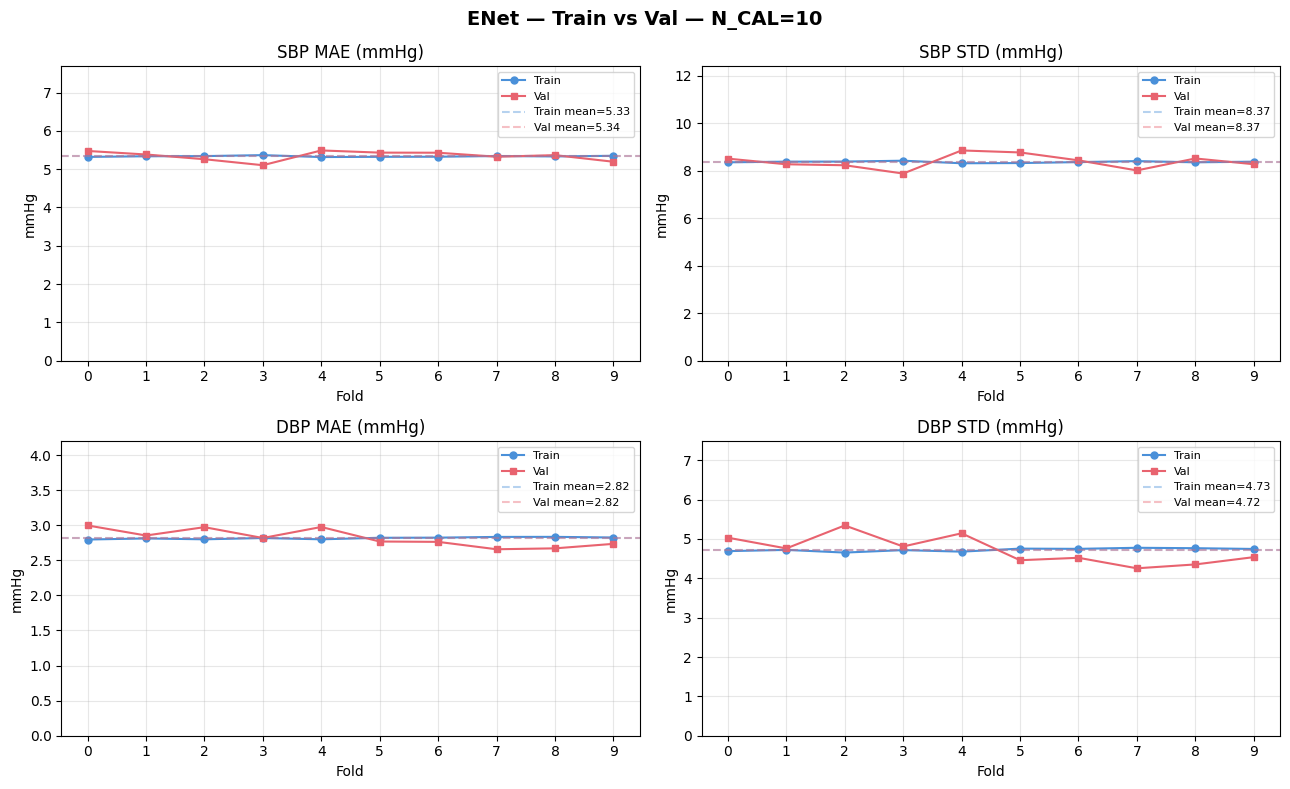


  N_CAL = 15
  Delta: 379,392 segs (7,446 subjects)
  Fold 0: cal_only=5.45/3.11  XGB=5.09/2.83  LGB=5.09/2.84  RF=5.10/2.84  Ridge=5.34/2.97  ENet=5.34/2.97  W_Stack=5.12/2.85
  Fold 1: cal_only=5.34/2.83  XGB=4.99/2.61  LGB=4.99/2.60  RF=5.06/2.62  Ridge=5.27/2.74  ENet=5.25/2.72  W_Stack=5.03/2.61
  Fold 2: cal_only=5.18/2.94  XGB=4.73/2.65  LGB=4.76/2.65  RF=4.82/2.69  Ridge=4.98/2.79  ENet=4.99/2.79  W_Stack=4.78/2.67
  Fold 3: cal_only=4.94/2.84  XGB=4.63/2.56  LGB=4.66/2.56  RF=4.68/2.57  Ridge=4.91/2.72  ENet=4.90/2.71  W_Stack=4.67/2.58
  Fold 4: cal_only=5.49/3.02  XGB=5.11/2.68  LGB=5.11/2.68  RF=5.16/2.72  Ridge=5.34/2.85  ENet=5.34/2.85  W_Stack=5.13/2.72
  Fold 5: cal_only=5.48/2.79  XGB=5.10/2.52  LGB=5.11/2.52  RF=5.16/2.54  Ridge=5.33/2.67  ENet=5.32/2.67  W_Stack=5.13/2.54
  Fold 6: cal_only=5.58/2.96  XGB=5.18/2.60  LGB=5.17/2.60  RF=5.23/2.63  Ridge=5.37/2.73  ENet=5.36/2.73  W_Stack=5.19/2.62
  Fold 7: cal_only=5.32/2.76  XGB=5.01/2.51  LGB=5.02/2.51  RF=5.05/2.52

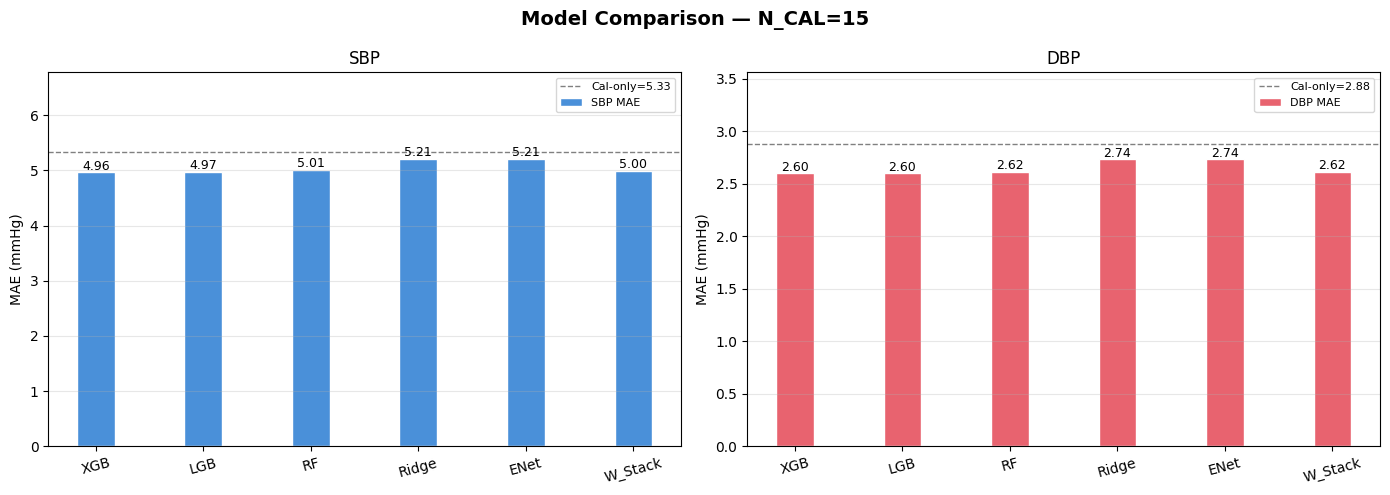

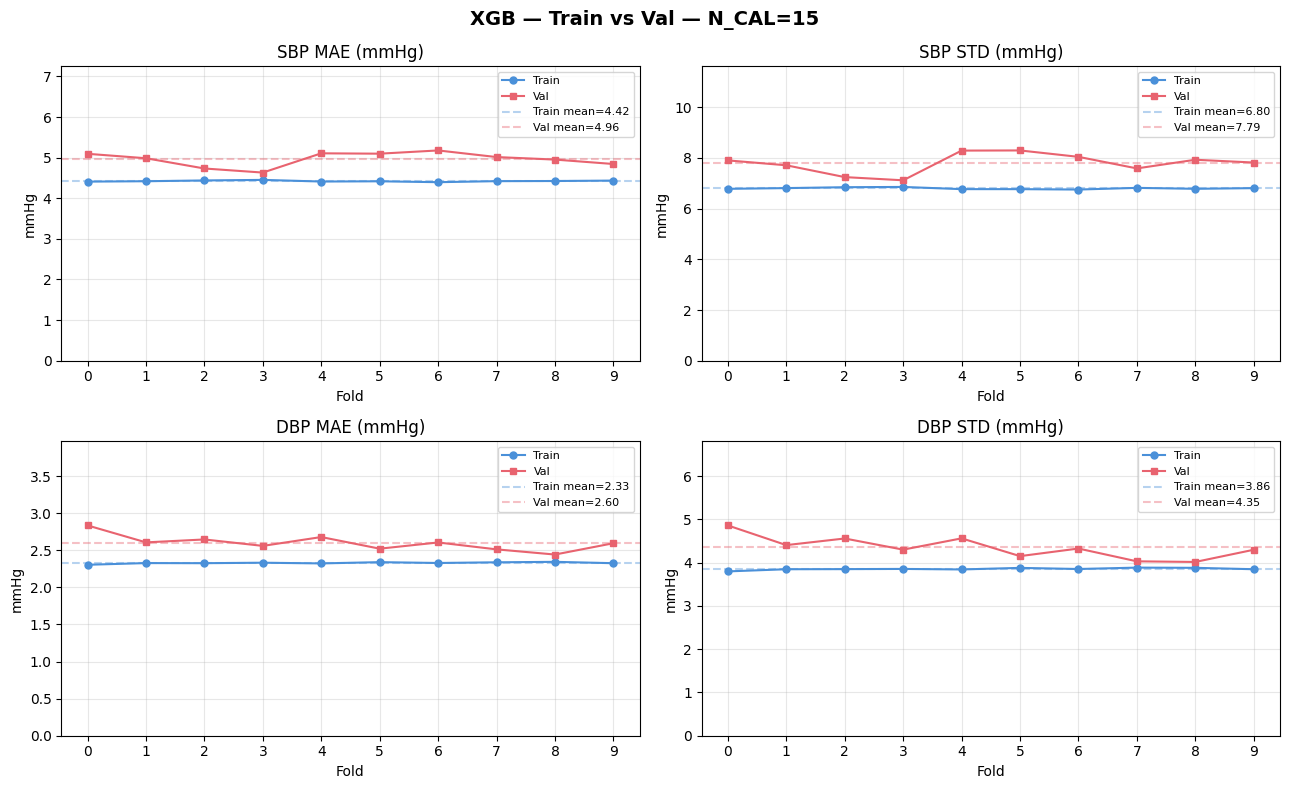

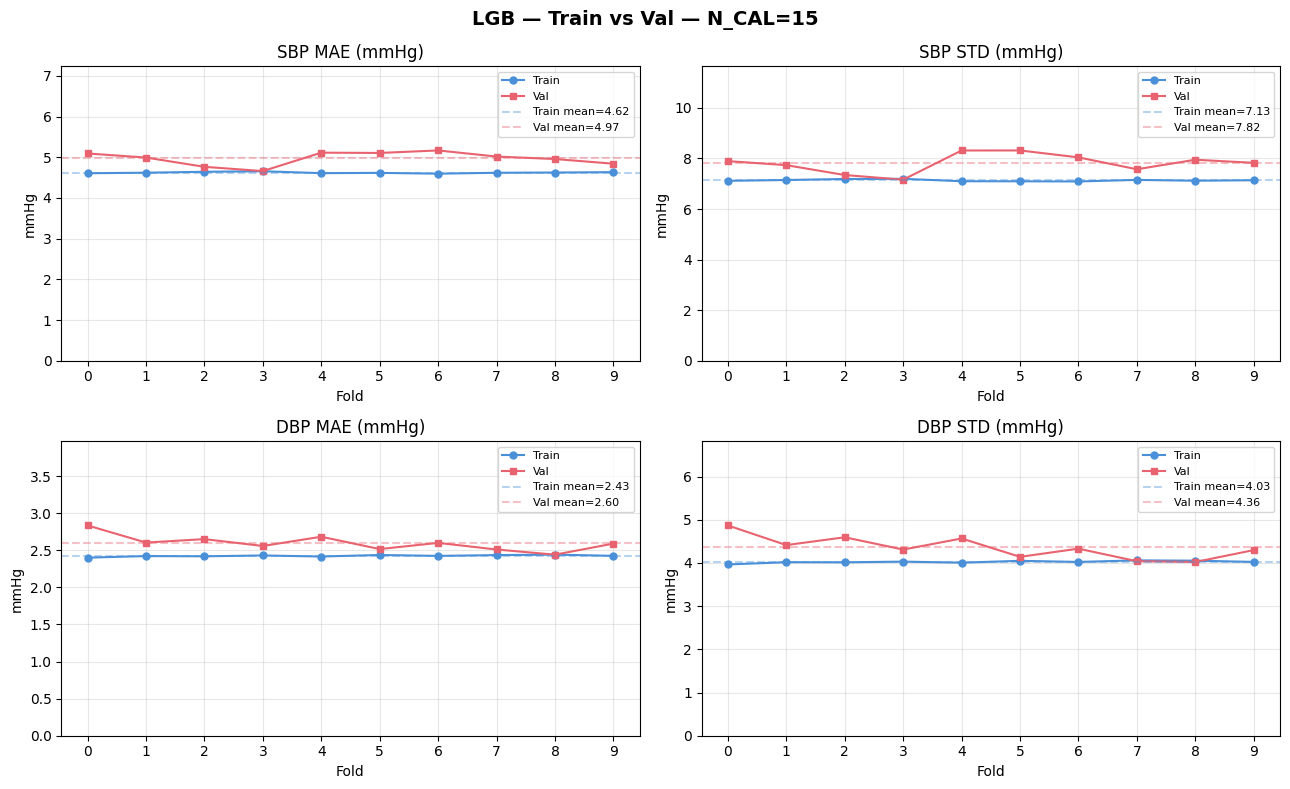

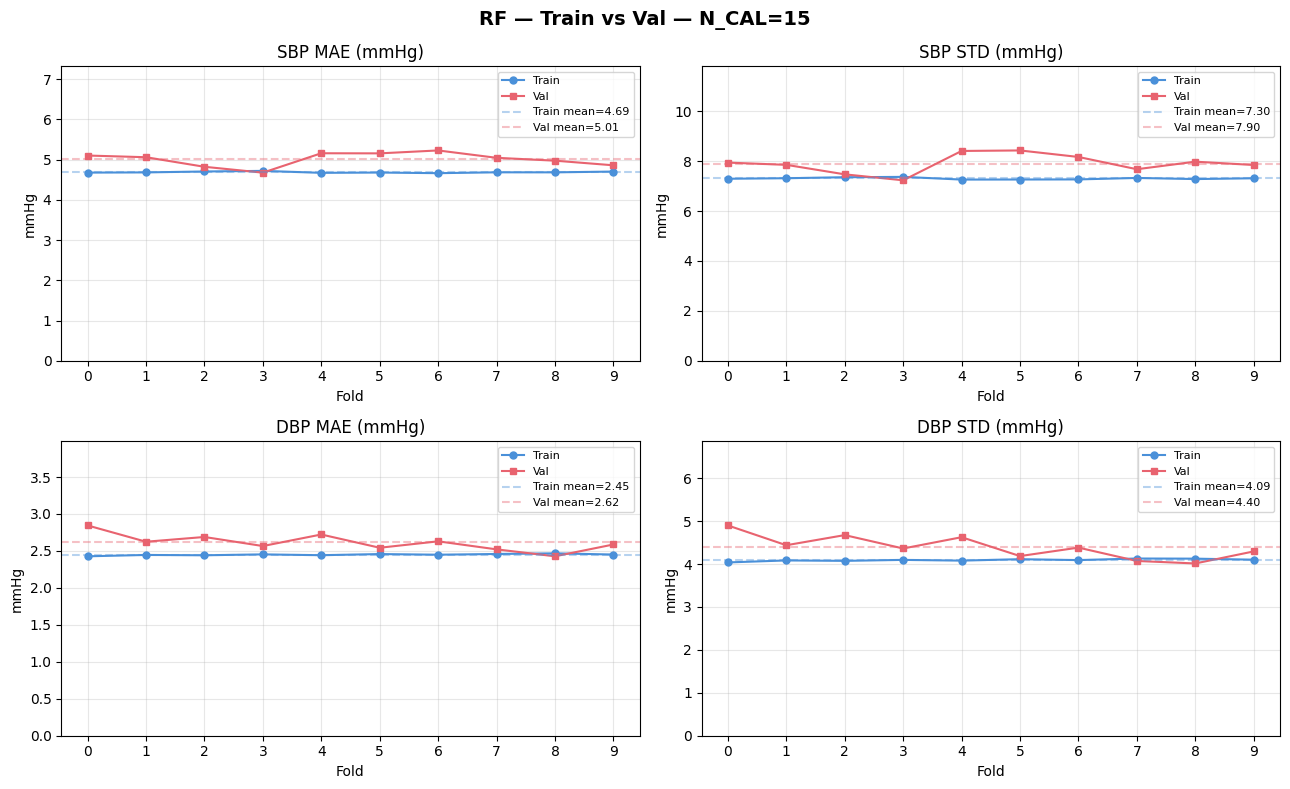

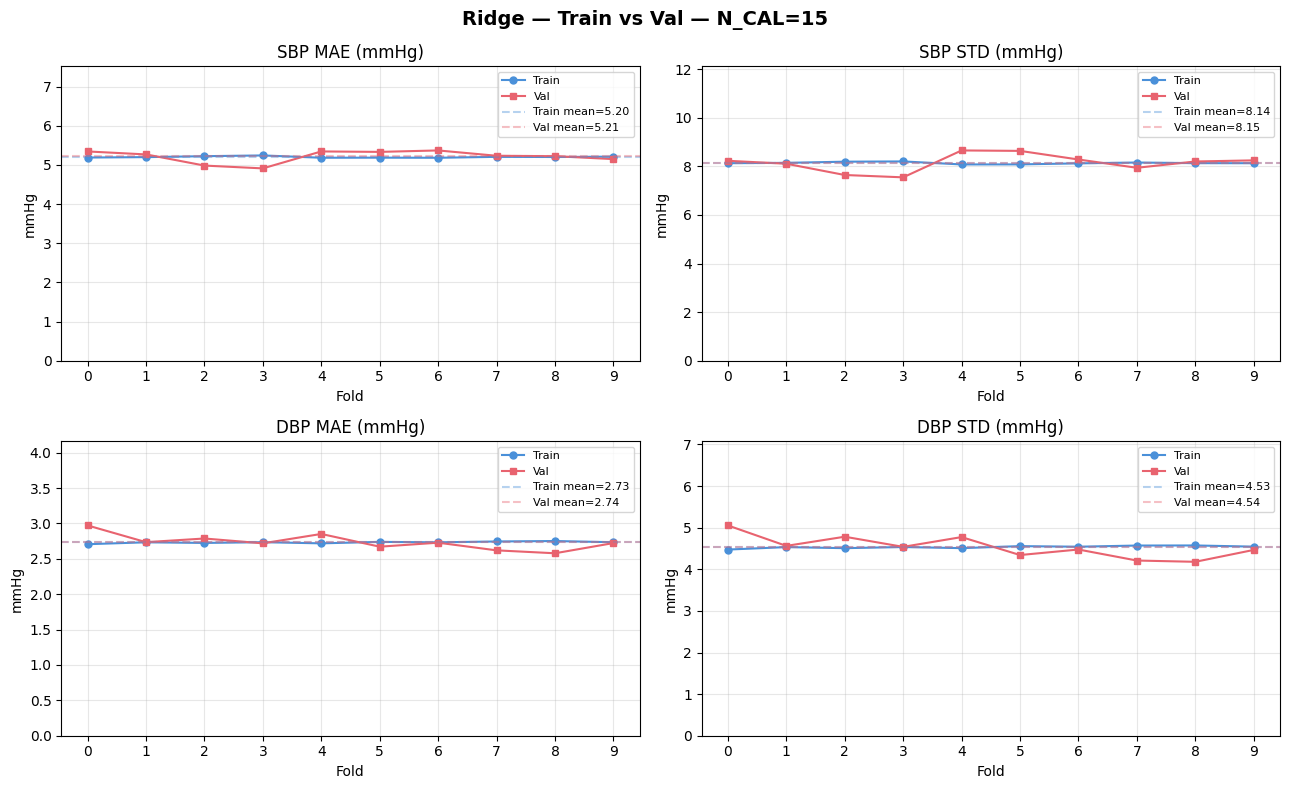

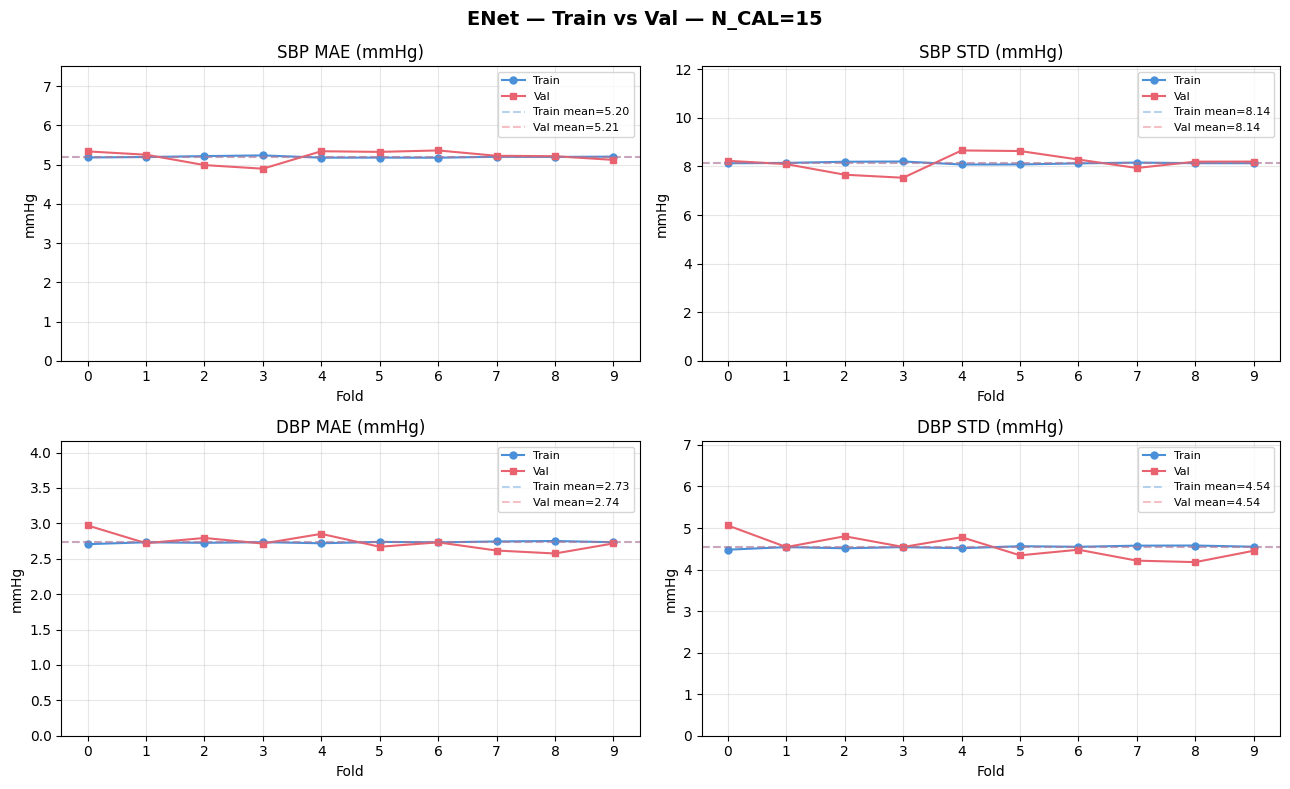


  N_CAL COMPARISON (best models)

  N_CAL=10:
    Best SBP: XGB = 5.13 (STD=8.05)
    Best DBP: LGB = 2.69 (STD=4.56)

  N_CAL=15:
    Best SBP: XGB = 4.96 (STD=7.79)
    Best DBP: XGB = 2.60 (STD=4.35)

═══ SAVING ═══
✅ Saved to /kaggle/working/checkpoints/run_20260519_053030/


In [5]:
# CELL 4 — Data info
import numpy as np
print(f"  Data: {X.shape[0]:,} segments, {X.shape[1]} features, {len(np.unique(groups)):,} records")
print(f"  BP range: SBP [{y[:,0].min():.0f}, {y[:,0].max():.0f}] DBP [{y[:,1].min():.0f}, {y[:,1].max():.0f}]")

# CELL 5 — v18: 5 diverse models, independent comparison, proper stacking
# Self-critique summary:
#   1. v16 XGB≈LGB vì cùng params GBDT → thêm RF (bagging), ElasticNet (sparse)
#   2. XGB quá regularized (min_child=30, lambda=3) → giảm reg cho delta yếu
#   3. Naive avg 1/3 → learned weighted stack (inv-MAE weights từ val)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GroupKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
import numpy as np, pandas as pd, joblib, os, json, matplotlib.pyplot as plt
from datetime import datetime

CKPT = '/kaggle/working/checkpoints'
os.makedirs(CKPT, exist_ok=True)
run_id = datetime.now().strftime('%Y%m%d_%H%M%S')
run_dir = os.path.join(CKPT, f'run_{run_id}')
os.makedirs(run_dir, exist_ok=True)

feat_names = list(X_df.columns)
N_CAL_LIST = [10, 15]
N_SPLITS = 10

# ═══ 5 Models — mỗi model tận dụng ưu điểm riêng ═══
MODEL_DEFS = {
    # XGBoost: deeper trees, less regularization → capture non-linear interactions
    'XGB': {
        'cls': XGBRegressor,
        'params': dict(n_estimators=250, max_depth=7, learning_rate=0.05,
                       min_child_weight=20, subsample=0.7, colsample_bytree=0.7,
                       reg_alpha=0.3, reg_lambda=1.5, random_state=42,
                       tree_method='hist', n_jobs=-1),
        'fit_kw': {'verbose': 0},
    },
    # LightGBM: leaf-wise (khác level-wise XGB), more trees, slower lr
    'LGB': {
        'cls': LGBMRegressor,
        'params': dict(n_estimators=500, num_leaves=63, max_depth=-1,
                       learning_rate=0.015, min_child_samples=40,
                       subsample=0.7, colsample_bytree=0.7, subsample_freq=1,
                       reg_alpha=1.0, reg_lambda=5.0, random_state=42,
                       n_jobs=-1, verbose=-1),
        'fit_kw': {},
    },
    # RandomForest: bagging (không boosting), sqrt features → low variance
    'RF': {
        'cls': RandomForestRegressor,
        'params': dict(n_estimators=200, max_depth=12, min_samples_leaf=20,
                       max_features='sqrt', bootstrap=True, random_state=42,
                       n_jobs=-1),
        'fit_kw': {},
    },
    # Ridge: linear baseline, captures main linear trends
    'Ridge': {
        'cls': Ridge,
        'params': dict(alpha=1.0),
        'fit_kw': {},
    },
    # ElasticNet: sparse feature selection, L1 loại feature yếu tự động
    'ENet': {
        'cls': ElasticNet,
        'params': dict(alpha=0.05, l1_ratio=0.7, max_iter=5000, random_state=42),
        'fit_kw': {},
    },
}
model_names = list(MODEL_DEFS.keys())

def compute_metrics(true, pred, recs):
    err = pred - true
    sme = []
    for rec in np.unique(recs):
        mk = recs == rec
        if mk.sum() < 3: continue
        sme.append(float(np.mean(err[mk])))
    return {
        'mae': float(mean_absolute_error(true, pred)),
        'me_seg': float(np.mean(err)),
        'std_seg': float(np.std(err, ddof=1)),
        'me_subj': float(np.mean(sme)) if sme else 0.0,
        'std_subj': float(np.std(sme)) if sme else 0.0,
    }

# ═══ Run ═══
all_ncal_results = {}

for N_CAL in N_CAL_LIST:
    print(f"\n{'='*110}")
    print(f"  N_CAL = {N_CAL}")
    print(f"{'='*110}")

    # Build delta arrays
    subject_cal_feat = {}; subject_cal_bp = {}
    delta_mask = np.zeros(len(X), dtype=bool)
    X_delta = np.zeros_like(X); y_delta = np.zeros_like(y)
    for rec in np.unique(groups):
        idx = np.where(groups == rec)[0]
        if len(idx) <= N_CAL: continue
        cal_idx = idx[:N_CAL]
        subject_cal_feat[rec] = np.nanmedian(X[cal_idx], axis=0)
        subject_cal_bp[rec] = np.median(y[cal_idx], axis=0)
        post_cal = idx[N_CAL:]
        delta_mask[post_cal] = True
        X_delta[post_cal] = X[post_cal] - subject_cal_feat[rec]
        y_delta[post_cal] = y[post_cal] - subject_cal_bp[rec]
    print(f"  Delta: {delta_mask.sum():,} segs ({len(subject_cal_feat):,} subjects)")

    gkf = GroupKFold(n_splits=N_SPLITS)
    # results: per model + cal_only + weighted_stack
    all_modes = ['cal_only'] + model_names + ['W_Stack']
    all_results = {m: [] for m in all_modes}
    train_log = {m: [] for m in model_names}  # train metrics per fold

    for fi, (tr_idx, te_idx) in enumerate(gkf.split(X, y, groups)):
        tr_delta = tr_idx[delta_mask[tr_idx]]
        imp_d = SimpleImputer(strategy='median')
        sc_d = RobustScaler()
        Xtr_d = sc_d.fit_transform(imp_d.fit_transform(X_delta[tr_delta]))

        # Train all models
        models_sbp = {}; models_dbp = {}
        for mname, mdef in MODEL_DEFS.items():
            ms = mdef['cls'](**mdef['params']); md = mdef['cls'](**mdef['params'])
            ms.fit(Xtr_d, y_delta[tr_delta, 0], **mdef['fit_kw'])
            md.fit(Xtr_d, y_delta[tr_delta, 1], **mdef['fit_kw'])
            models_sbp[mname] = ms; models_dbp[mname] = md
            # Train metrics
            tr_ps = ms.predict(Xtr_d); tr_pd = md.predict(Xtr_d)
            train_log[mname].append({
                'sbp_mae': float(np.mean(np.abs(tr_ps - y_delta[tr_delta, 0]))),
                'sbp_std': float(np.std(tr_ps - y_delta[tr_delta, 0])),
                'dbp_mae': float(np.mean(np.abs(tr_pd - y_delta[tr_delta, 1]))),
                'dbp_std': float(np.std(tr_pd - y_delta[tr_delta, 1])),
            })

        # Per-subject evaluation
        y_te = y[te_idx]; g_te = groups[te_idx]
        ev = {m: {'ps':[],'pd':[],'ts':[],'td':[],'recs':[]} for m in all_modes}

        for rec in np.unique(g_te):
            rm = np.where(g_te == rec)[0]
            if len(rm) <= N_CAL: continue
            ci, ti = rm[:N_CAL], rm[N_CAL:]
            cal_s = float(np.median(y_te[ci, 0]))
            cal_d = float(np.median(y_te[ci, 1]))
            cal_feat = np.nanmedian(X[te_idx[ci]], axis=0)
            Xte_d = sc_d.transform(imp_d.transform((X[te_idx[ti]] - cal_feat).reshape(len(ti),-1)))

            # Cal-only
            ev['cal_only']['ps'].extend([cal_s]*len(ti))
            ev['cal_only']['pd'].extend([cal_d]*len(ti))

            # Each model independently
            preds_s = {}; preds_d = {}
            for mname in model_names:
                ps = models_sbp[mname].predict(Xte_d); pd2 = models_dbp[mname].predict(Xte_d)
                preds_s[mname] = ps; preds_d[mname] = pd2
                ev[mname]['ps'].extend(cal_s + ps)
                ev[mname]['pd'].extend(cal_d + pd2)

            # Weighted stack: inv-MAE weights from train performance
            w = {}
            for mname in model_names:
                w[mname] = 1.0 / (train_log[mname][-1]['sbp_mae'] + 0.01)
            w_sum = sum(w.values())
            ws_pred = sum(preds_s[m] * w[m] / w_sum for m in model_names)
            wd = {}
            for mname in model_names:
                wd[mname] = 1.0 / (train_log[mname][-1]['dbp_mae'] + 0.01)
            wd_sum = sum(wd.values())
            wd_pred = sum(preds_d[m] * wd[m] / wd_sum for m in model_names)
            ev['W_Stack']['ps'].extend(cal_s + ws_pred)
            ev['W_Stack']['pd'].extend(cal_d + wd_pred)

            for m in all_modes:
                ev[m]['ts'].extend(y_te[ti, 0]); ev[m]['td'].extend(y_te[ti, 1])
                ev[m]['recs'].extend([rec]*len(ti))

        # Compute fold metrics
        fold_str = []
        for m in all_modes:
            ps, ts = np.array(ev[m]['ps']), np.array(ev[m]['ts'])
            pd2, td = np.array(ev[m]['pd']), np.array(ev[m]['td'])
            recs = np.array(ev[m]['recs'])
            ms_r = compute_metrics(ts, ps, recs); md_r = compute_metrics(td, pd2, recs)
            all_results[m].append({
                'sbp_mae': ms_r['mae'], 'sbp_me_seg': ms_r['me_seg'],
                'sbp_std_seg': ms_r['std_seg'], 'sbp_me_subj': ms_r['me_subj'],
                'sbp_std_subj': ms_r['std_subj'],
                'dbp_mae': md_r['mae'], 'dbp_me_seg': md_r['me_seg'],
                'dbp_std_seg': md_r['std_seg'], 'dbp_me_subj': md_r['me_subj'],
                'dbp_std_subj': md_r['std_subj'], 'n': len(ts)})
            fold_str.append(f"{m}={ms_r['mae']:.2f}/{md_r['mae']:.2f}")

        print(f"  Fold {fi}: " + "  ".join(fold_str))

    # ── Summary table ──
    print(f"\n{'='*110}")
    print(f"  SUMMARY ({N_SPLITS}-Fold, N_CAL={N_CAL})")
    print(f"{'='*110}")
    print(f"  {'Model':<14s} │ {'SBP MAE':>7s} {'ME':>6s} {'STD_s':>6s} {'STD_r':>6s} │ "
          f"{'DBP MAE':>7s} {'ME':>6s} {'STD_s':>6s} {'STD_r':>6s} │ {'AAMI':>6s}")
    print("  " + "─"*85)

    ncal_summary = {}
    for m in all_modes:
        df = pd.DataFrame(all_results[m])
        row = {k: float(df[k].mean()) for k in df.columns if k != 'n'}
        ncal_summary[m] = row
        aami_s = abs(row['sbp_me_seg']) <= 5 and row['sbp_std_seg'] <= 8
        aami_d = abs(row['dbp_me_seg']) <= 5 and row['dbp_std_seg'] <= 8
        aami = '✅' if (aami_s and aami_d) else ('½' if aami_d else '❌')
        print(f"  {m:<14s} │ {row['sbp_mae']:>7.2f} {row['sbp_me_seg']:>+6.2f} "
              f"{row['sbp_std_seg']:>6.2f} {row['sbp_std_subj']:>6.2f} │ "
              f"{row['dbp_mae']:>7.2f} {row['dbp_me_seg']:>+6.2f} "
              f"{row['dbp_std_seg']:>6.2f} {row['dbp_std_subj']:>6.2f} │ {aami:>6s}")

    # Improvement over cal-only
    cal_r = ncal_summary['cal_only']
    print(f"\n  Improvement vs Cal-only:")
    for m in model_names + ['W_Stack']:
        r = ncal_summary[m]
        ds = cal_r['sbp_mae'] - r['sbp_mae']; dd = cal_r['dbp_mae'] - r['dbp_mae']
        print(f"    {m:<14s}: SBP {ds:+.3f}  DBP {dd:+.3f}")

    all_ncal_results[N_CAL] = ncal_summary

    # ── Train vs Val per model ──
    print(f"\n  TRAIN vs VAL (per model mean):")
    print(f"  {'Model':<10s} │ {'Tr SBP':>7s} {'Va SBP':>7s} {'gap':>5s} │ "
          f"{'Tr DBP':>7s} {'Va DBP':>7s} {'gap':>5s}")
    print("  " + "─"*55)
    for mname in model_names:
        tr = pd.DataFrame(train_log[mname])
        ts_m = float(tr['sbp_mae'].mean()); td_m = float(tr['dbp_mae'].mean())
        vs_m = ncal_summary[mname]['sbp_mae']; vd_m = ncal_summary[mname]['dbp_mae']
        print(f"  {mname:<10s} │ {ts_m:>7.2f} {vs_m:>7.2f} {vs_m-ts_m:>+5.2f} │ "
              f"{td_m:>7.2f} {vd_m:>7.2f} {vd_m-td_m:>+5.2f}")

    # ── Feature importance (XGB, last fold) ──
    for bp, mdl in [('SBP', models_sbp['XGB']), ('DBP', models_dbp['XGB'])]:
        if hasattr(mdl, 'feature_importances_'):
            imp = mdl.feature_importances_
            si = np.argsort(imp)[::-1][:8]
            top = " | ".join(f"{feat_names[i]}={imp[i]:.3f}" for i in si)
            print(f"  XGB {bp}: {top}")

    # ═══ PLOTS ═══
    folds = np.arange(N_SPLITS)

    # ── Plot 1: Model comparison bar chart ──
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Model Comparison — N_CAL={N_CAL}', fontsize=14, fontweight='bold')
    compare_models = model_names + ['W_Stack']
    sbp_vals = [ncal_summary[m]['sbp_mae'] for m in compare_models]
    dbp_vals = [ncal_summary[m]['dbp_mae'] for m in compare_models]

    x = np.arange(len(compare_models)); w = 0.35
    ax = axes[0]
    ax.bar(x, sbp_vals, w, label='SBP MAE', color='#4A90D9', edgecolor='white')
    ax.axhline(cal_r['sbp_mae'], color='gray', ls='--', lw=1, label=f"Cal-only={cal_r['sbp_mae']:.2f}")
    ax.set_ylabel('MAE (mmHg)'); ax.set_title('SBP')
    ax.set_xticks(x); ax.set_xticklabels(compare_models, rotation=15)
    ax.set_ylim(0, max(sbp_vals)*1.3); ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(sbp_vals): ax.text(i, v+0.05, f'{v:.2f}', ha='center', fontsize=9)

    ax = axes[1]
    ax.bar(x, dbp_vals, w, label='DBP MAE', color='#E8636F', edgecolor='white')
    ax.axhline(cal_r['dbp_mae'], color='gray', ls='--', lw=1, label=f"Cal-only={cal_r['dbp_mae']:.2f}")
    ax.set_ylabel('MAE (mmHg)'); ax.set_title('DBP')
    ax.set_xticks(x); ax.set_xticklabels(compare_models, rotation=15)
    ax.set_ylim(0, max(dbp_vals)*1.3); ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(dbp_vals): ax.text(i, v+0.02, f'{v:.2f}', ha='center', fontsize=9)

    plt.tight_layout()
    plt.savefig(f'/kaggle/working/model_compare_ncal{N_CAL}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Plot 2: Individual train vs val per MODEL (1 figure per model) ──
    colors_tv = {'train': '#4A90D9', 'val': '#E8636F'}
    for mname in model_names:
        fig, axes = plt.subplots(2, 2, figsize=(13, 8))
        fig.suptitle(f'{mname} — Train vs Val — N_CAL={N_CAL}', fontsize=14, fontweight='bold')

        for ax, tr_key, val_key, title in [
            (axes[0,0], 'sbp_mae', 'sbp_mae', 'SBP MAE (mmHg)'),
            (axes[0,1], 'sbp_std', 'sbp_std_seg', 'SBP STD (mmHg)'),
            (axes[1,0], 'dbp_mae', 'dbp_mae', 'DBP MAE (mmHg)'),
            (axes[1,1], 'dbp_std', 'dbp_std_seg', 'DBP STD (mmHg)'),
        ]:
            tr_vals = [train_log[mname][fi][tr_key] for fi in range(N_SPLITS)]
            val_vals = [all_results[mname][fi][val_key] for fi in range(N_SPLITS)]
            ax.plot(folds, tr_vals, '-o', ms=5, lw=1.5, color=colors_tv['train'], label='Train')
            ax.plot(folds, val_vals, '-s', ms=5, lw=1.5, color=colors_tv['val'], label='Val')
            ax.axhline(np.mean(tr_vals), color=colors_tv['train'], ls='--', alpha=0.4,
                       label=f'Train mean={np.mean(tr_vals):.2f}')
            ax.axhline(np.mean(val_vals), color=colors_tv['val'], ls='--', alpha=0.4,
                       label=f'Val mean={np.mean(val_vals):.2f}')
            ax.set_ylim(0, max(max(tr_vals), max(val_vals)) * 1.4)
            ax.set_ylabel('mmHg'); ax.set_xlabel('Fold'); ax.set_xticks(folds)
            ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_title(title)

        plt.tight_layout()
        plt.savefig(f'/kaggle/working/{mname}_train_val_ncal{N_CAL}.png', dpi=150, bbox_inches='tight')
        plt.show()

# ═══ N_CAL Comparison ═══
print(f"\n{'='*110}")
print(f"  N_CAL COMPARISON (best models)")
print(f"{'='*110}")
for nc in N_CAL_LIST:
    r = all_ncal_results[nc]
    print(f"\n  N_CAL={nc}:")
    best_s = min(model_names + ['W_Stack'], key=lambda m: r[m]['sbp_mae'])
    best_d = min(model_names + ['W_Stack'], key=lambda m: r[m]['dbp_mae'])
    print(f"    Best SBP: {best_s} = {r[best_s]['sbp_mae']:.2f} (STD={r[best_s]['sbp_std_seg']:.2f})")
    print(f"    Best DBP: {best_d} = {r[best_d]['dbp_mae']:.2f} (STD={r[best_d]['dbp_std_seg']:.2f})")

# ═══ Save ═══
print(f"\n═══ SAVING ═══")
for mname in model_names:
    joblib.dump(models_sbp[mname], os.path.join(run_dir, f'{mname}_sbp.joblib'))
    joblib.dump(models_dbp[mname], os.path.join(run_dir, f'{mname}_dbp.joblib'))
joblib.dump(imp_d, os.path.join(run_dir, 'imputer.joblib'))
joblib.dump(sc_d, os.path.join(run_dir, 'scaler.joblib'))

def to_json(obj):
    if isinstance(obj, dict): return {k: to_json(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)): return [to_json(v) for v in obj]
    elif isinstance(obj, (np.floating, np.float32, np.float64)): return float(obj)
    elif isinstance(obj, (np.integer, np.int32, np.int64)): return int(obj)
    elif isinstance(obj, np.ndarray): return obj.tolist()
    return obj

results_json = to_json({
    'run_id': run_id, 'n_cal_list': N_CAL_LIST, 'n_splits': N_SPLITS,
    'features': feat_names, 'models': model_names,
    'results': all_ncal_results, 'train_log': train_log,
})
with open(os.path.join(run_dir, 'results.json'), 'w') as f:
    json.dump(results_json, f, indent=2)
print(f"✅ Saved to {run_dir}/")



thông số, hình ảnh, bảng

  COLLECTING PREDICTIONS (will be cached)

  XGBoost (N_CAL=15)...
    Fold 1/10 done
    Fold 2/10 done
    Fold 3/10 done
    Fold 4/10 done
    Fold 5/10 done
    Fold 6/10 done
    Fold 7/10 done
    Fold 8/10 done
    Fold 9/10 done
    Fold 10/10 done
    ⏱ 195s

  RF (N_CAL=10)...
    Fold 1/10 done
    Fold 2/10 done
    Fold 3/10 done
    Fold 4/10 done
    Fold 5/10 done
    Fold 6/10 done
    Fold 7/10 done
    Fold 8/10 done
    Fold 9/10 done
    Fold 10/10 done
    ⏱ 4950s

✅ Predictions cached to /kaggle/working/pub_eval_cache.npz

  EVALUATION METRICS
   XGBoost SBP: MAE=4.96  RMSE=7.81  R²=0.8726  ME=+0.04 ± 7.81
   XGBoost DBP: MAE=2.60  RMSE=4.36  R²=0.8295  ME=+0.03 ± 4.36
        RF SBP: MAE=5.16  RMSE=8.15  R²=0.8617  ME=+0.03 ± 8.15
        RF DBP: MAE=2.71  RMSE=4.60  R²=0.8125  ME=+0.02 ± 4.60

  TABLE 1 — Model Parameters
  Parameter                 │         XGBoost │   Random Forest
  ────────────────────────────────────────────────────────────
  Algorithm  

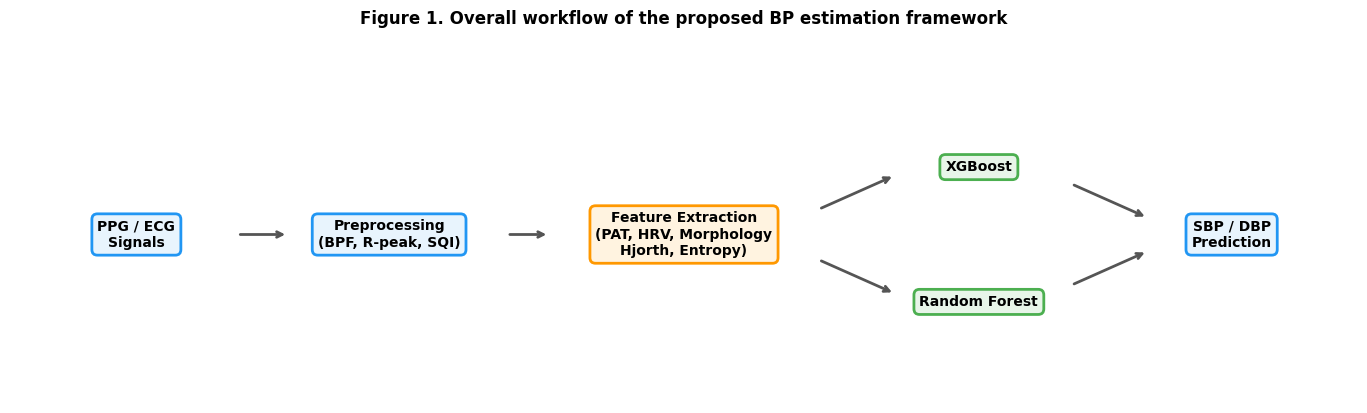

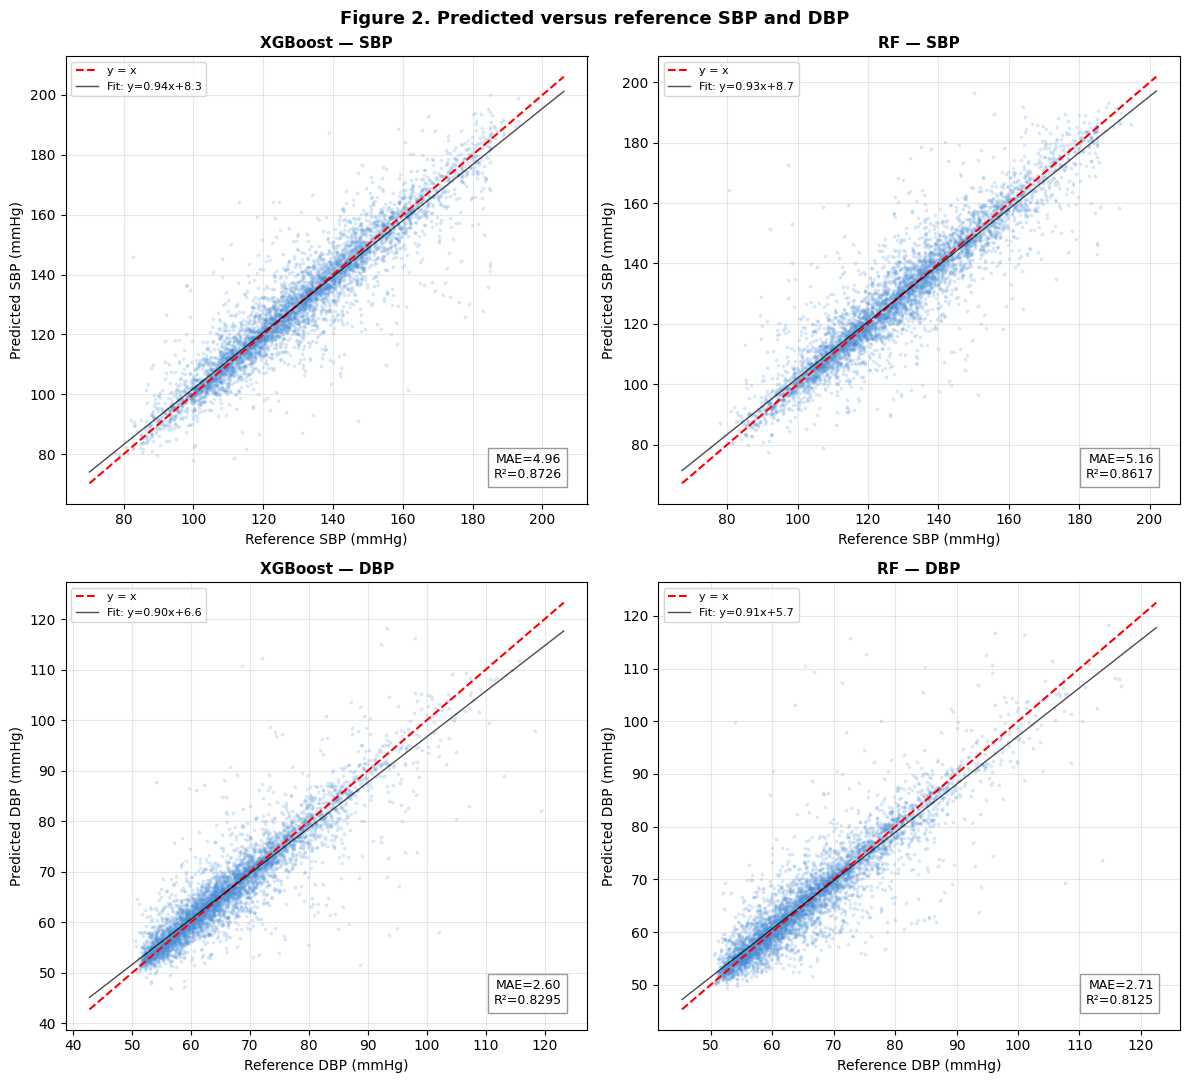

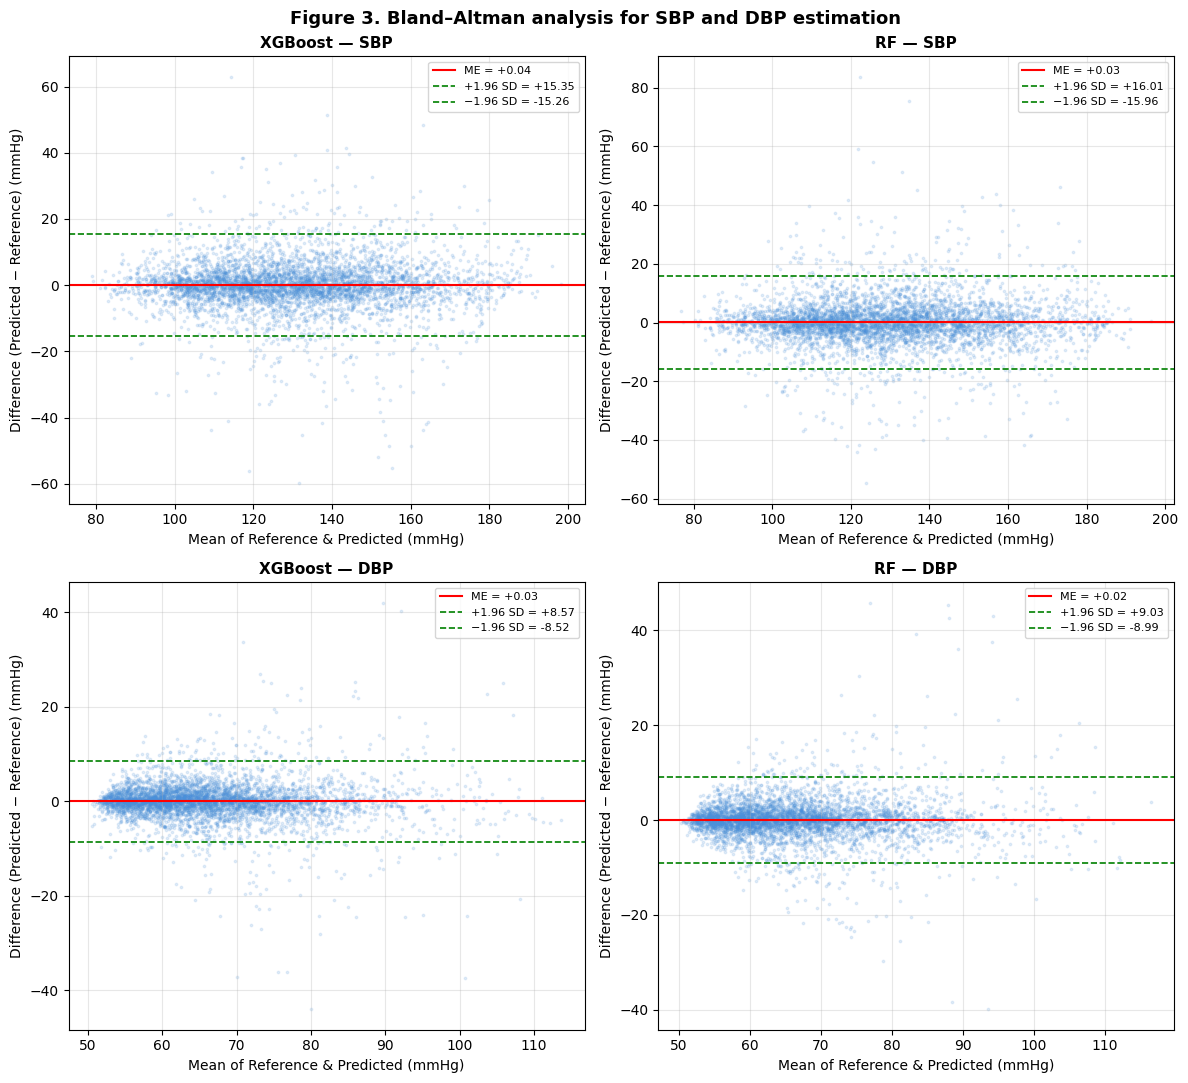

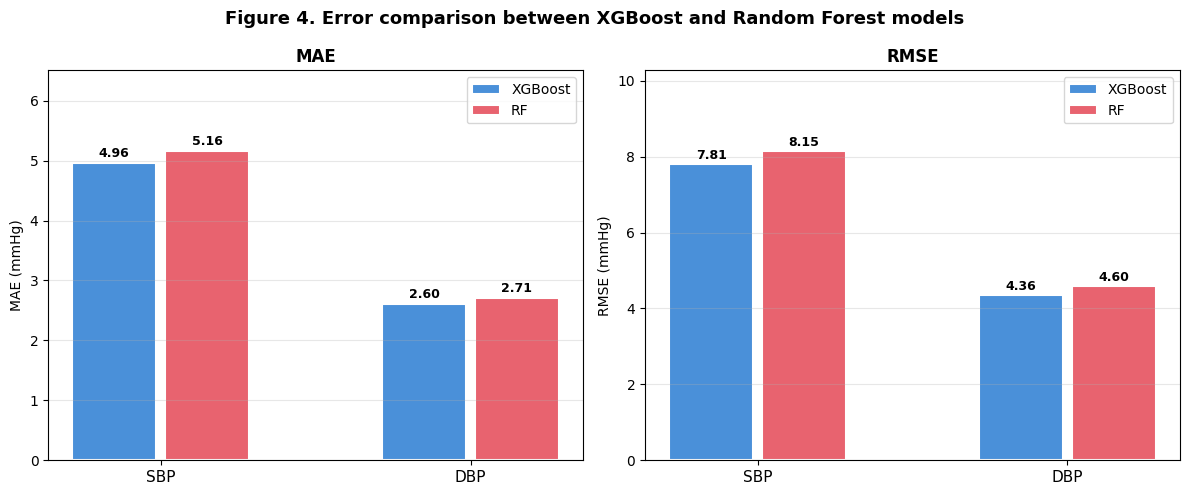


✅ All 4 figures + 2 tables completed.


In [8]:
# CELL — Publication Evaluation: Figures & Tables for Scientific Paper
# Run AFTER Cell 5 (training complete)
# Evaluates: XGBoost (N_CAL=15) vs RF (N_CAL=10) — for paper comparison
import numpy as np, pandas as pd, matplotlib.pyplot as plt, time, os
from sklearn.model_selection import GroupKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import warnings; warnings.filterwarnings('ignore')

SAVE_DIR = '/kaggle/working'
N_SPLITS = 10
CACHE_FILE = os.path.join(SAVE_DIR, 'pub_eval_cache.npz')

# ─── Model configs (same as Cell 5) ───
MODELS_CONFIG = {
    'XGBoost': {
        'cls': XGBRegressor,
        'params': dict(n_estimators=250, max_depth=7, learning_rate=0.05,
                       min_child_weight=20, subsample=0.7, colsample_bytree=0.7,
                       reg_alpha=0.3, reg_lambda=1.5, random_state=42,
                       tree_method='hist', n_jobs=-1),
        'fit_kw': {'verbose': 0},
        'n_cal': 15,
    },
    'RF': {
        'cls': RandomForestRegressor,
        'params': dict(n_estimators=200, max_depth=12, min_samples_leaf=20,
                       max_features='sqrt', bootstrap=True, random_state=42,
                       n_jobs=-1),
        'fit_kw': {},
        'n_cal': 10,
    },
}

feat_names = list(X_df.columns)

# ═══════════════════════════════════════════
# HELPER: Compute all metrics
# ═══════════════════════════════════════════
def compute_all_metrics(y_true, y_pred):
    errors = y_pred - y_true
    return dict(
        MAE=float(mean_absolute_error(y_true, y_pred)),
        RMSE=float(np.sqrt(mean_squared_error(y_true, y_pred))),
        R2=float(r2_score(y_true, y_pred)),
        ME=float(np.mean(errors)),
        SD=float(np.std(errors, ddof=1)),
    )

# ═══════════════════════════════════════════
# COLLECT RAW PREDICTIONS (with cache)
# ═══════════════════════════════════════════
if os.path.exists(CACHE_FILE):
    print("═══ LOADING PREDICTIONS FROM CACHE ═══")
    _cache = np.load(CACHE_FILE, allow_pickle=True)
    results_all = _cache['results_all'].item()
    print("✅ Loaded.")
else:
    print("=" * 70)
    print("  COLLECTING PREDICTIONS (will be cached)")
    print("=" * 70)
    results_all = {}

    for model_label, config in MODELS_CONFIG.items():
        N_CAL = config['n_cal']
        ModelClass = config['cls']
        params = config['params']
        fit_kw = config['fit_kw']

        print(f"\n  {model_label} (N_CAL={N_CAL})...")

        # Build delta arrays
        delta_mask = np.zeros(len(X), dtype=bool)
        X_delta = np.zeros_like(X); y_delta = np.zeros_like(y)
        subject_cal_feat = {}; subject_cal_bp = {}
        for rec in np.unique(groups):
            idx = np.where(groups == rec)[0]
            if len(idx) <= N_CAL: continue
            cal_idx = idx[:N_CAL]
            subject_cal_feat[rec] = np.nanmedian(X[cal_idx], axis=0)
            subject_cal_bp[rec] = np.median(y[cal_idx], axis=0)
            post_cal = idx[N_CAL:]
            delta_mask[post_cal] = True
            X_delta[post_cal] = X[post_cal] - subject_cal_feat[rec]
            y_delta[post_cal] = y[post_cal] - subject_cal_bp[rec]

        gkf = GroupKFold(n_splits=N_SPLITS)
        all_sbp_true, all_sbp_pred = [], []
        all_dbp_true, all_dbp_pred = [], []

        t0 = time.time()
        for fi, (tr_idx, te_idx) in enumerate(gkf.split(X, y, groups)):
            tr_delta = tr_idx[delta_mask[tr_idx]]
            imp_d = SimpleImputer(strategy='median')
            sc_d = RobustScaler()
            Xtr_d = sc_d.fit_transform(imp_d.fit_transform(X_delta[tr_delta]))

            ms = ModelClass(**params); md = ModelClass(**params)
            ms.fit(Xtr_d, y_delta[tr_delta, 0], **fit_kw)
            md.fit(Xtr_d, y_delta[tr_delta, 1], **fit_kw)

            y_te = y[te_idx]; g_te = groups[te_idx]
            for rec in np.unique(g_te):
                rm = np.where(g_te == rec)[0]
                if len(rm) <= N_CAL: continue
                ci, ti = rm[:N_CAL], rm[N_CAL:]
                cal_s = float(np.median(y_te[ci, 0]))
                cal_d = float(np.median(y_te[ci, 1]))
                cal_feat = np.nanmedian(X[te_idx[ci]], axis=0)
                Xte_d = sc_d.transform(imp_d.transform(
                    (X[te_idx[ti]] - cal_feat).reshape(len(ti), -1)))
                ps = ms.predict(Xte_d); pd2 = md.predict(Xte_d)
                all_sbp_true.extend(y_te[ti, 0])
                all_sbp_pred.extend(cal_s + ps)
                all_dbp_true.extend(y_te[ti, 1])
                all_dbp_pred.extend(cal_d + pd2)
            print(f"    Fold {fi+1}/{N_SPLITS} done")

        print(f"    ⏱ {time.time()-t0:.0f}s")
        results_all[model_label] = {
            'sbp_true': np.array(all_sbp_true), 'sbp_pred': np.array(all_sbp_pred),
            'dbp_true': np.array(all_dbp_true), 'dbp_pred': np.array(all_dbp_pred),
        }

    np.savez_compressed(CACHE_FILE, results_all=results_all)
    print(f"\n✅ Predictions cached to {CACHE_FILE}")

# ═══════════════════════════════════════════
# COMPUTE METRICS
# ═══════════════════════════════════════════
print("\n" + "=" * 70)
print("  EVALUATION METRICS")
print("=" * 70)

metrics_table = []
for model_label in ['XGBoost', 'RF']:
    r = results_all[model_label]
    for target, t_key, p_key in [('SBP', 'sbp_true', 'sbp_pred'),
                                  ('DBP', 'dbp_true', 'dbp_pred')]:
        m = compute_all_metrics(r[t_key], r[p_key])
        metrics_table.append({
            'Model': model_label, 'Target': target,
            'MAE': m['MAE'], 'RMSE': m['RMSE'], 'R²': m['R2'],
            'ME': m['ME'], 'SD': m['SD'],
        })
        print(f"  {model_label:>8s} {target}: MAE={m['MAE']:.2f}  RMSE={m['RMSE']:.2f}  "
              f"R²={m['R2']:.4f}  ME={m['ME']:+.2f} ± {m['SD']:.2f}")

# ═══════════════════════════════════════════
# TABLE 1: Model Parameters
# ═══════════════════════════════════════════
print("\n" + "=" * 70)
print("  TABLE 1 — Model Parameters")
print("=" * 70)
print(f"  {'Parameter':<25s} │ {'XGBoost':>15s} │ {'Random Forest':>15s}")
print("  " + "─" * 60)
xgb_p = MODELS_CONFIG['XGBoost']['params']
rf_p = MODELS_CONFIG['RF']['params']
print(f"  {'Algorithm':<25s} │ {'Gradient Boost':>15s} │ {'Bagging':>15s}")
print(f"  {'Number of trees':<25s} │ {xgb_p['n_estimators']:>15d} │ {rf_p['n_estimators']:>15d}")
print(f"  {'Max depth':<25s} │ {xgb_p['max_depth']:>15d} │ {rf_p['max_depth']:>15d}")
print(f"  {'Learning rate':<25s} │ {xgb_p['learning_rate']:>15.3f} │ {'N/A':>15s}")
print(f"  {'Min samples/leaf':<25s} │ {xgb_p['min_child_weight']:>15d} │ {rf_p['min_samples_leaf']:>15d}")
print(f"  {'Subsample ratio':<25s} │ {xgb_p['subsample']:>15.2f} │ {'N/A':>15s}")
print(f"  {'Feature subsample':<25s} │ {xgb_p['colsample_bytree']:>15.2f} │ {'sqrt':>15s}")
print(f"  {'L1 regularization':<25s} │ {xgb_p['reg_alpha']:>15.2f} │ {'N/A':>15s}")
print(f"  {'L2 regularization':<25s} │ {xgb_p['reg_lambda']:>15.2f} │ {'N/A':>15s}")
print(f"  {'Number of features':<25s} │ {len(feat_names):>15d} │ {len(feat_names):>15d}")
print(f"  {'Prediction targets':<25s} │ {'SBP, DBP':>15s} │ {'SBP, DBP':>15s}")

# ═══════════════════════════════════════════
# TABLE 2: Quantitative Results
# ═══════════════════════════════════════════
print("\n" + "=" * 70)
print("  TABLE 2 — Quantitative Results")
print("=" * 70)
print(f"  {'Model':<10s} │ {'Target':<6s} │ {'MAE':>7s} │ {'RMSE':>7s} │ {'R²':>7s} │ {'ME ± SD':>15s}")
print("  " + "─" * 62)
for row in metrics_table:
    me_sd = f"{row['ME']:+.2f} ± {row['SD']:.2f}"
    print(f"  {row['Model']:<10s} │ {row['Target']:<6s} │ {row['MAE']:>7.2f} │ "
          f"{row['RMSE']:>7.2f} │ {row['R²']:>7.4f} │ {me_sd:>15s}")

# ═══════════════════════════════════════════
# FIGURE 1: Overall Workflow Diagram
# ═══════════════════════════════════════════
fig, ax = plt.subplots(figsize=(16, 4))
ax.set_xlim(0, 16); ax.set_ylim(0, 4)
ax.set_aspect('equal'); ax.axis('off')

box_style = dict(boxstyle="round,pad=0.4", facecolor='#E8F4FD', edgecolor='#2196F3', linewidth=2)
box_style2 = dict(boxstyle="round,pad=0.4", facecolor='#FFF3E0', edgecolor='#FF9800', linewidth=2)
box_style3 = dict(boxstyle="round,pad=0.4", facecolor='#E8F5E9', edgecolor='#4CAF50', linewidth=2)
arrow_style = dict(arrowstyle='->', color='#333', lw=2, mutation_scale=20)

# Boxes
boxes = [
    (1.5, 2.0, 'PPG / ECG\nSignals', box_style),
    (4.5, 2.0, 'Preprocessing\n(BPF, R-peak, SQI)', box_style),
    (8.0, 2.0, 'Feature Extraction\n(PAT, HRV, Morphology\nHjorth, Entropy)', box_style2),
    (11.5, 2.8, 'XGBoost', box_style3),
    (11.5, 1.2, 'Random Forest', box_style3),
    (14.5, 2.0, 'SBP / DBP\nPrediction', box_style),
]
for (x, y_pos, text, style) in boxes:
    ax.text(x, y_pos, text, ha='center', va='center', fontsize=10, fontweight='bold',
            bbox=style)

# Arrows
for x1, y1, x2, y2 in [(2.7, 2.0, 3.3, 2.0), (5.9, 2.0, 6.4, 2.0),
                         (9.6, 2.3, 10.5, 2.7), (9.6, 1.7, 10.5, 1.3),
                         (12.6, 2.6, 13.5, 2.2), (12.6, 1.4, 13.5, 1.8)]:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#555', lw=2))

fig.suptitle('Figure 1. Overall workflow of the proposed BP estimation framework',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig1_workflow.png', dpi=300, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════
# FIGURE 2: Predicted vs Reference (Scatter)
# ═══════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(12, 11))
fig.suptitle('Figure 2. Predicted versus reference SBP and DBP',
             fontsize=13, fontweight='bold')

for col, lab in enumerate(['XGBoost', 'RF']):
    r = results_all[lab]
    for row, (tgt, tk, pk) in enumerate([('SBP','sbp_true','sbp_pred'),
                                          ('DBP','dbp_true','dbp_pred')]):
        ax = axes[row, col]
        yt, yp = r[tk], r[pk]
        n = len(yt)
        idx = np.random.RandomState(42).choice(n, min(5000, n), replace=False)
        ax.scatter(yt[idx], yp[idx], alpha=0.15, s=3, c='#4A90D9')
        mn = min(yt.min(), yp.min()); mx = max(yt.max(), yp.max())
        ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='y = x')
        z = np.polyfit(yt[idx], yp[idx], 1)
        xl = np.linspace(mn, mx, 100)
        ax.plot(xl, np.polyval(z, xl), 'k-', lw=1, alpha=0.7,
                label=f'Fit: y={z[0]:.2f}x+{z[1]:.1f}')
        m = compute_all_metrics(yt, yp)
        ax.set_title(f'{lab} — {tgt}', fontsize=11, fontweight='bold')
        ax.set_xlabel(f'Reference {tgt} (mmHg)')
        ax.set_ylabel(f'Predicted {tgt} (mmHg)')
        ax.legend(fontsize=8, loc='upper left')
        ax.text(0.95, 0.05, f"MAE={m['MAE']:.2f}\nR²={m['R2']:.4f}",
                transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig2_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════
# FIGURE 3: Bland-Altman Plot
# ═══════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(12, 11))
fig.suptitle('Figure 3. Bland–Altman analysis for SBP and DBP estimation',
             fontsize=13, fontweight='bold')

for col, lab in enumerate(['XGBoost', 'RF']):
    r = results_all[lab]
    for row, (tgt, tk, pk) in enumerate([('SBP','sbp_true','sbp_pred'),
                                          ('DBP','dbp_true','dbp_pred')]):
        ax = axes[row, col]
        yt, yp = r[tk], r[pk]
        mean_vals = (yt + yp) / 2
        diff_vals = yp - yt
        me = np.mean(diff_vals); sd = np.std(diff_vals, ddof=1)
        n = len(yt)
        idx = np.random.RandomState(42).choice(n, min(5000, n), replace=False)
        ax.scatter(mean_vals[idx], diff_vals[idx], alpha=0.15, s=3, c='#4A90D9')
        ax.axhline(me, color='red', lw=1.5, label=f'ME = {me:+.2f}')
        ax.axhline(me + 1.96*sd, color='green', ls='--', lw=1.2,
                   label=f'+1.96 SD = {me+1.96*sd:+.2f}')
        ax.axhline(me - 1.96*sd, color='green', ls='--', lw=1.2,
                   label=f'−1.96 SD = {me-1.96*sd:+.2f}')
        ax.set_title(f'{lab} — {tgt}', fontsize=11, fontweight='bold')
        ax.set_xlabel(f'Mean of Reference & Predicted (mmHg)')
        ax.set_ylabel(f'Difference (Predicted − Reference) (mmHg)')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig3_bland_altman.png', dpi=300, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════
# FIGURE 4: Error Comparison Bar Chart
# ═══════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Figure 4. Error comparison between XGBoost and Random Forest models',
             fontsize=13, fontweight='bold')

colors = {'XGBoost': '#4A90D9', 'RF': '#E8636F'}
x = np.arange(2); w = 0.3

for ai, mkey in enumerate(['MAE', 'RMSE']):
    ax = axes[ai]
    for mi, lab in enumerate(['XGBoost', 'RF']):
        vals = [r[mkey] for r in metrics_table if r['Model'] == lab]
        offset = (mi - 0.5) * w
        bars = ax.bar(x + offset, vals, w * 0.9, label=lab,
                      color=colors[lab], edgecolor='white', lw=1.5)
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.05,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(['SBP', 'DBP'], fontsize=11)
    ax.set_ylabel(f'{mkey} (mmHg)'); ax.set_title(mkey, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.2)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig4_error_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ All 4 figures + 2 tables completed.")



các model

In [ ]:
# CELL 5 — Delta Model (clean: XGBoost only, N_CAL=15)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GroupKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
import numpy as np, pandas as pd, joblib, os, json
from datetime import datetime

CKPT = '/kaggle/working/checkpoints'
os.makedirs(CKPT, exist_ok=True)
run_id = datetime.now().strftime('%Y%m%d_%H%M%S')
run_dir = os.path.join(CKPT, f'run_{run_id}')
os.makedirs(run_dir, exist_ok=True)
np.savez_compressed(os.path.join(run_dir, 'data.npz'), X=X, y=y, groups=groups)
print(f"✅ Saved to {run_dir}/")

feat_names = list(X_df.columns)
N_CAL = 15
N_SPLITS = 10

# Delta transform: baseline = first N_CAL per subject (matches test)
subject_cal_feat = {}
subject_cal_bp = {}
for rec in np.unique(groups):
    idx = np.where(groups == rec)[0]
    if len(idx) <= N_CAL: continue
    cal_idx = idx[:N_CAL]
    subject_cal_feat[rec] = np.nanmedian(X[cal_idx], axis=0)
    subject_cal_bp[rec] = np.mean(y[cal_idx], axis=0)

delta_mask = np.zeros(len(X), dtype=bool)
X_delta = np.zeros_like(X)
y_delta = np.zeros_like(y)
for rec in subject_cal_feat:
    idx = np.where(groups == rec)[0]
    post_cal = idx[N_CAL:]
    delta_mask[post_cal] = True
    X_delta[post_cal] = X[post_cal] - subject_cal_feat[rec]
    y_delta[post_cal] = y[post_cal] - subject_cal_bp[rec]

n_delta = delta_mask.sum()
print(f"Delta training: {n_delta:,} segments ({len(subject_cal_feat):,} subjects)")
print(f"Delta BP std:   SBP {np.std(y_delta[delta_mask,0]):.2f}  DBP {np.std(y_delta[delta_mask,1]):.2f}")

def compute_metrics(true, pred, recs):
    err = pred - true
    sme = []
    for rec in np.unique(recs):
        mk = recs == rec
        if mk.sum() < 3: continue
        sme.append(float(np.mean(err[mk])))
    return {
        'mae': mean_absolute_error(true, pred),
        'me_seg': float(np.mean(err)),
        'std_seg': float(np.std(err, ddof=1)),
        'me_subj': float(np.mean(sme)) if sme else 0.0,
        'std_subj': float(np.std(sme)) if sme else 0.0,
    }

gkf = GroupKFold(n_splits=N_SPLITS)
modes = ['cal_only', 'pop_bias', 'd_xgb', 'd_lgb', 'd_rf']
all_results = {m: [] for m in modes}

params = dict(n_estimators=400, max_depth=5, learning_rate=0.03,
              min_child_weight=30, subsample=0.8, colsample_bytree=0.8,
              reg_alpha=0.5, reg_lambda=3.0, random_state=42,
              tree_method='hist', n_jobs=-1)

for fi, (tr_idx, te_idx) in enumerate(gkf.split(X, y, groups)):
    # Preprocessing
    imp = SimpleImputer(strategy='median')
    sc = RobustScaler()
    Xtr = sc.fit_transform(imp.fit_transform(X[tr_idx]))
    Xte = sc.transform(imp.transform(X[te_idx]))

    # Population model (for bias baseline)
    ms_pop = XGBRegressor(**params); md_pop = XGBRegressor(**params)
    ms_pop.fit(Xtr, y[tr_idx, 0], verbose=0)
    md_pop.fit(Xtr, y[tr_idx, 1], verbose=0)
    pred_pop_s = ms_pop.predict(Xte)
    pred_pop_d = md_pop.predict(Xte)

    # Delta models (3 algorithms, shared preprocessing)
    tr_d = tr_idx[delta_mask[tr_idx]]
    imp_d = SimpleImputer(strategy='median')
    sc_d = RobustScaler()
    Xtr_d = sc_d.fit_transform(imp_d.fit_transform(X_delta[tr_d]))

    delta_models = {}
    # XGBoost
    xgb_s = XGBRegressor(**params); xgb_d = XGBRegressor(**params)
    xgb_s.fit(Xtr_d, y_delta[tr_d,0], verbose=0)
    xgb_d.fit(Xtr_d, y_delta[tr_d,1], verbose=0)
    delta_models['d_xgb'] = (xgb_s, xgb_d)
    # LightGBM
    lgb_p = dict(n_estimators=400, max_depth=5, learning_rate=0.03,
                 min_child_samples=30, subsample=0.8, colsample_bytree=0.8,
                 reg_alpha=0.5, reg_lambda=3.0, random_state=42,
                 n_jobs=-1, verbose=-1)
    lgb_s = LGBMRegressor(**lgb_p); lgb_d = LGBMRegressor(**lgb_p)
    lgb_s.fit(Xtr_d, y_delta[tr_d,0]); lgb_d.fit(Xtr_d, y_delta[tr_d,1])
    delta_models['d_lgb'] = (lgb_s, lgb_d)
    # RandomForest
    rf_p = dict(n_estimators=300, max_depth=12, min_samples_leaf=30,
                max_features='sqrt', random_state=42, n_jobs=-1)
    rf_s = RandomForestRegressor(**rf_p); rf_d = RandomForestRegressor(**rf_p)
    rf_s.fit(Xtr_d, y_delta[tr_d,0]); rf_d.fit(Xtr_d, y_delta[tr_d,1])
    delta_models['d_rf'] = (rf_s, rf_d)

    y_te = y[te_idx]; g_te = groups[te_idx]

    ev = {m: {'ps':[],'pd':[],'ts':[],'td':[],'recs':[]} for m in modes}

    for rec in np.unique(g_te):
        rm = np.where(g_te == rec)[0]
        if len(rm) <= N_CAL: continue
        ci, ti = rm[:N_CAL], rm[N_CAL:]

        cal_s = float(np.mean(y_te[ci, 0]))
        cal_d = float(np.mean(y_te[ci, 1]))
        cal_feat = np.nanmedian(X[te_idx[ci]], axis=0)

        # Cal-only
        ev['cal_only']['ps'].extend([cal_s]*len(ti))
        ev['cal_only']['pd'].extend([cal_d]*len(ti))

        # Pop + Bias
        bs = float(np.mean(y_te[ci,0] - pred_pop_s[ci]))
        bd = float(np.mean(y_te[ci,1] - pred_pop_d[ci]))
        ev['pop_bias']['ps'].extend(pred_pop_s[ti] + bs)
        ev['pop_bias']['pd'].extend(pred_pop_d[ti] + bd)

        # Delta models
        df_test = X[te_idx[ti]] - cal_feat
        Xte_d = sc_d.transform(imp_d.transform(df_test))
        for dm_name, (dm_s, dm_d) in delta_models.items():
            ev[dm_name]['ps'].extend(cal_s + dm_s.predict(Xte_d))
            ev[dm_name]['pd'].extend(cal_d + dm_d.predict(Xte_d))

        for m in ev:
            ev[m]['ts'].extend(y_te[ti,0])
            ev[m]['td'].extend(y_te[ti,1])
            ev[m]['recs'].extend([rec]*len(ti))

    fold_str = []
    for m in modes:
        ps,ts = np.array(ev[m]['ps']),np.array(ev[m]['ts'])
        pd2,td = np.array(ev[m]['pd']),np.array(ev[m]['td'])
        recs = np.array(ev[m]['recs'])
        ms_r = compute_metrics(ts, ps, recs)
        md_r = compute_metrics(td, pd2, recs)
        all_results[m].append({
            'sbp_mae':ms_r['mae'],'sbp_me_seg':ms_r['me_seg'],
            'sbp_std_seg':ms_r['std_seg'],'sbp_me_subj':ms_r['me_subj'],
            'sbp_std_subj':ms_r['std_subj'],
            'dbp_mae':md_r['mae'],'dbp_me_seg':md_r['me_seg'],
            'dbp_std_seg':md_r['std_seg'],'dbp_me_subj':md_r['me_subj'],
            'dbp_std_subj':md_r['std_subj'],'n':len(ts)})
        fold_str.append(f"{ms_r['mae']:.2f}")

    print(f"  Fold {fi}: Cal={fold_str[0]} Bias={fold_str[1]} "
          f"XGB={fold_str[2]} LGB={fold_str[3]} RF={fold_str[4]}")

# Summary
labels = [('cal_only','Cal-only'),('pop_bias','Pop+Bias'),
          ('d_xgb','Delta XGB'),('d_lgb','Delta LGB'),('d_rf','Delta RF')]
print(f"\n{'='*95}")
print(f"  SUMMARY ({N_SPLITS}-Fold, N_CAL={N_CAL}, {len(feat_names)} features)")
print(f"{'='*95}")
print(f"  {'Mode':<18s} │ {'SBP MAE':>7s} {'ME_seg':>7s} {'STD_seg':>7s} {'STD_sub':>7s} │ "
      f"{'DBP MAE':>7s} {'ME_seg':>7s} {'STD_seg':>7s} {'STD_sub':>7s}")
print("─"*95)
for m, lbl in labels:
    df = pd.DataFrame(all_results[m])
    print(f"  {lbl:<18s} │ "
          f"{df['sbp_mae'].mean():>7.2f} {df['sbp_me_seg'].mean():>+7.2f} "
          f"{df['sbp_std_seg'].mean():>7.2f} {df['sbp_std_subj'].mean():>7.2f} │ "
          f"{df['dbp_mae'].mean():>7.2f} {df['dbp_me_seg'].mean():>+7.2f} "
          f"{df['dbp_std_seg'].mean():>7.2f} {df['dbp_std_subj'].mean():>7.2f}")

# AAMI
print(f"\n  AAMI SP10 (|ME|≤5, STD≤8):")
for m, lbl in labels[2:]:
    df = pd.DataFrame(all_results[m])
    for bp, pfx in [('SBP','sbp'),('DBP','dbp')]:
        seg_ok = abs(df[f'{pfx}_me_seg'].mean())<=5 and df[f'{pfx}_std_seg'].mean()<=8
        sub_ok = abs(df[f'{pfx}_me_subj'].mean())<=5 and df[f'{pfx}_std_subj'].mean()<=8
        print(f"    [{lbl:<12s}] {bp}: seg={'✅' if seg_ok else '❌'}"
              f"(ME={df[f'{pfx}_me_seg'].mean():+.2f} STD={df[f'{pfx}_std_seg'].mean():.2f}) "
              f"sub={'✅' if sub_ok else '❌'}"
              f"(ME={df[f'{pfx}_me_subj'].mean():+.2f} STD={df[f'{pfx}_std_subj'].mean():.2f})")

# vs Cal-only
print(f"\n  vs Cal-only:")
cal_df = pd.DataFrame(all_results['cal_only'])
for m, lbl in labels[1:]:
    df = pd.DataFrame(all_results[m])
    ds = cal_df['sbp_mae'].mean()-df['sbp_mae'].mean()
    dd = cal_df['dbp_mae'].mean()-df['dbp_mae'].mean()
    print(f"    {lbl:<18s}: SBP {'+' if ds>0 else ''}{ds:.2f} | DBP {'+' if dd>0 else ''}{dd:.2f}")

# Feature importance (XGBoost)
print(f"\n  Feature importance (XGB delta, last fold):")
for bp, mdl in [('SBP',xgb_s),('DBP',xgb_d)]:
    imp_arr = mdl.feature_importances_
    si = np.argsort(imp_arr)[::-1]
    top = [(feat_names[i],imp_arr[i]) for i in si[:5]]
    print(f"    {bp}: "+" | ".join(f"{n}={v:.3f}" for n,v in top))

# Save
joblib.dump(ms_pop, os.path.join(run_dir,'model_pop_sbp.joblib'))
joblib.dump(md_pop, os.path.join(run_dir,'model_pop_dbp.joblib'))
joblib.dump(xgb_s, os.path.join(run_dir,'delta_xgb_sbp.joblib'))
joblib.dump(xgb_d, os.path.join(run_dir,'delta_xgb_dbp.joblib'))
joblib.dump(lgb_s, os.path.join(run_dir,'delta_lgb_sbp.joblib'))
joblib.dump(lgb_d, os.path.join(run_dir,'delta_lgb_dbp.joblib'))
joblib.dump(imp_d, os.path.join(run_dir,'imputer_delta.joblib'))
joblib.dump(sc_d, os.path.join(run_dir,'scaler_delta.joblib'))
results_json = {'run_id':run_id,'n_cal':N_CAL,'n_splits':N_SPLITS,'features':feat_names}
for m in modes:
    df = pd.DataFrame(all_results[m])
    df.to_csv(os.path.join(run_dir,f'cv_{m}.csv'),index=False)
    results_json[m] = {k:float(df[k].mean()) for k in df.columns if k!='n'}
with open(os.path.join(run_dir,'results.json'),'w') as f:
    json.dump(results_json,f,indent=2)
print(f"\n  Saved to {run_dir}/")



best

In [ ]:
# CELL 5 — Delta Model: train on intra-subject residuals
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GroupKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Ridge
import numpy as np, pandas as pd, joblib, os, json
from datetime import datetime

CKPT = '/kaggle/working/checkpoints'
os.makedirs(CKPT, exist_ok=True)
run_id = datetime.now().strftime('%Y%m%d_%H%M%S')
run_dir = os.path.join(CKPT, f'run_{run_id}')
os.makedirs(run_dir, exist_ok=True)
np.savez_compressed(os.path.join(run_dir, 'data.npz'), X=X, y=y, groups=groups)
print(f"✅ Saved to {run_dir}/")

feat_names = list(X_df.columns)
N_CAL = 15
N_SPLITS = 10

# ═══════════════════════════════════════════════════
# STEP 1: Compute per-subject means for delta transform
# ═══════════════════════════════════════════════════
# Train AND test both use first N_CAL segments as baseline
# → No train-test mismatch
# Subjects with ≤ N_CAL segments: excluded from delta training
subject_cal_feat = {}  # record_id → median(first N_CAL features)
subject_cal_bp = {}    # record_id → mean(first N_CAL BP)

for rec in np.unique(groups):
    idx = np.where(groups == rec)[0]
    if len(idx) <= N_CAL:
        continue  # too short → skip
    cal_idx = idx[:N_CAL]
    subject_cal_feat[rec] = np.nanmedian(X[cal_idx], axis=0)
    subject_cal_bp[rec] = np.mean(y[cal_idx], axis=0)

# Create delta arrays (only for subjects with > N_CAL segments)
# Delta = value - baseline(first N_CAL)
# Training uses segments AFTER N_CAL (same as test would)
delta_mask = np.zeros(len(X), dtype=bool)
X_delta = np.zeros_like(X)
y_delta = np.zeros_like(y)

for rec in subject_cal_feat:
    idx = np.where(groups == rec)[0]
    post_cal = idx[N_CAL:]  # skip calibration segments
    delta_mask[post_cal] = True
    X_delta[post_cal] = X[post_cal] - subject_cal_feat[rec]
    y_delta[post_cal] = y[post_cal] - subject_cal_bp[rec]

n_delta = delta_mask.sum()
print(f"Delta training: {n_delta:,} segments ({len(subject_cal_feat):,} subjects)")
print(f"Delta BP range: SBP [{y_delta[delta_mask,0].min():+.1f}, {y_delta[delta_mask,0].max():+.1f}] "
      f"DBP [{y_delta[delta_mask,1].min():+.1f}, {y_delta[delta_mask,1].max():+.1f}]")
print(f"Delta BP std:   SBP {np.std(y_delta[delta_mask,0]):.2f}  DBP {np.std(y_delta[delta_mask,1]):.2f}")

# ═══════════════════════════════════════════════════
# STEP 2: Train & Evaluate
# ═══════════════════════════════════════════════════

def compute_metrics(true, pred, recs):
    err = pred - true
    sme = []
    for rec in np.unique(recs):
        mk = recs == rec
        if mk.sum() < 3: continue
        sme.append(float(np.mean(err[mk])))
    return {
        'mae': mean_absolute_error(true, pred),
        'me_seg': float(np.mean(err)),
        'std_seg': float(np.std(err, ddof=1)),
        'me_subj': float(np.mean(sme)) if sme else 0.0,
        'std_subj': float(np.std(sme)) if sme else 0.0,
    }

gkf = GroupKFold(n_splits=N_SPLITS)
modes = ['cal_only', 'pop_abs', 'pop_bias', 'pop_delta']
all_results = {m: [] for m in modes}

for fi, (tr_idx, te_idx) in enumerate(gkf.split(X, y, groups)):
    # ── A: Population model (absolute, as before) ──
    imp_a = SimpleImputer(strategy='median')
    Xtr_a = imp_a.fit_transform(X[tr_idx])
    sc_a = RobustScaler()
    Xtr_a = sc_a.fit_transform(Xtr_a)

    params = dict(n_estimators=400, max_depth=5, learning_rate=0.03,
                  min_child_weight=30, subsample=0.8, colsample_bytree=0.8,
                  reg_alpha=0.5, reg_lambda=3.0, random_state=42,
                  tree_method='hist', n_jobs=-1)
    ms_a = XGBRegressor(**params); md_a = XGBRegressor(**params)
    ms_a.fit(Xtr_a, y[tr_idx, 0], verbose=0)
    md_a.fit(Xtr_a, y[tr_idx, 1], verbose=0)

    Xte_a = sc_a.transform(imp_a.transform(X[te_idx]))
    pred_abs_s = ms_a.predict(Xte_a)
    pred_abs_d = md_a.predict(Xte_a)

    # ── B: Delta model (only post-cal segments, matching test) ──
    tr_delta = tr_idx[delta_mask[tr_idx]]  # only post-cal in train
    imp_d = SimpleImputer(strategy='median')
    Xtr_d = imp_d.fit_transform(X_delta[tr_delta])
    sc_d = RobustScaler()
    Xtr_d = sc_d.fit_transform(Xtr_d)

    ms_d = XGBRegressor(**params); md_d = XGBRegressor(**params)
    ms_d.fit(Xtr_d, y_delta[tr_delta, 0], verbose=0)
    md_d.fit(Xtr_d, y_delta[tr_delta, 1], verbose=0)

    y_te = y[te_idx]; g_te = groups[te_idx]

    # ── Per-subject calibration ──
    ev = {m: {'ps': [], 'pd': [], 'ts': [], 'td': [], 'recs': []}
          for m in modes}

    for rec in np.unique(g_te):
        rm = np.where(g_te == rec)[0]
        if len(rm) <= N_CAL: continue
        ci, ti = rm[:N_CAL], rm[N_CAL:]

        cal_mean_s = float(np.mean(y_te[ci, 0]))
        cal_mean_d = float(np.mean(y_te[ci, 1]))
        cal_mean_feat = np.nanmedian(X[te_idx[ci]], axis=0)

        # Mode 1: Cal-only
        ev['cal_only']['ps'].extend([cal_mean_s] * len(ti))
        ev['cal_only']['pd'].extend([cal_mean_d] * len(ti))

        # Mode 2: Population absolute (no correction)
        ev['pop_abs']['ps'].extend(pred_abs_s[ti])
        ev['pop_abs']['pd'].extend(pred_abs_d[ti])

        # Mode 3: Population + constant bias
        bias_s = float(np.mean(y_te[ci, 0] - pred_abs_s[ci]))
        bias_d = float(np.mean(y_te[ci, 1] - pred_abs_d[ci]))
        ev['pop_bias']['ps'].extend(pred_abs_s[ti] + bias_s)
        ev['pop_bias']['pd'].extend(pred_abs_d[ti] + bias_d)

        # Mode 4: Delta model + calibration baseline
        # delta_feat_test = feat_test - cal_mean_feat
        delta_test_feat = X[te_idx[ti]] - cal_mean_feat
        Xte_d = sc_d.transform(imp_d.transform(delta_test_feat))
        pred_delta_s = ms_d.predict(Xte_d)
        pred_delta_d = md_d.predict(Xte_d)
        ev['pop_delta']['ps'].extend(cal_mean_s + pred_delta_s)
        ev['pop_delta']['pd'].extend(cal_mean_d + pred_delta_d)

        for m in ev:
            ev[m]['ts'].extend(y_te[ti, 0])
            ev[m]['td'].extend(y_te[ti, 1])
            ev[m]['recs'].extend([rec] * len(ti))

    fold_str = []
    for m in modes:
        ps, ts = np.array(ev[m]['ps']), np.array(ev[m]['ts'])
        pd2, td = np.array(ev[m]['pd']), np.array(ev[m]['td'])
        recs = np.array(ev[m]['recs'])
        ms_r = compute_metrics(ts, ps, recs)
        md_r = compute_metrics(td, pd2, recs)
        all_results[m].append({
            'sbp_mae': ms_r['mae'], 'sbp_me_seg': ms_r['me_seg'],
            'sbp_std_seg': ms_r['std_seg'], 'sbp_me_subj': ms_r['me_subj'],
            'sbp_std_subj': ms_r['std_subj'],
            'dbp_mae': md_r['mae'], 'dbp_me_seg': md_r['me_seg'],
            'dbp_std_seg': md_r['std_seg'], 'dbp_me_subj': md_r['me_subj'],
            'dbp_std_subj': md_r['std_subj'], 'n': len(ts)})
        fold_str.append(f"{ms_r['mae']:.2f}")

    print(f"  Fold {fi}: Cal={fold_str[0]} Pop={fold_str[1]} "
          f"Bias={fold_str[2]} Delta={fold_str[3]}")

# ── Summary ──
labels = [('cal_only', 'Cal-only (trivial)'),
          ('pop_abs', 'Population (abs)'),
          ('pop_bias', 'Pop + Bias'),
          ('pop_delta', 'Delta Model')]
print(f"\n{'='*95}")
print(f"  SUMMARY ({N_SPLITS}-Fold, N_CAL={N_CAL})")
print(f"{'='*95}")
print(f"  {'Mode':<22s} │ {'SBP MAE':>7s} {'ME_seg':>7s} {'STD_seg':>7s} {'STD_sub':>7s} │ "
      f"{'DBP MAE':>7s} {'ME_seg':>7s} {'STD_seg':>7s} {'STD_sub':>7s}")
print("─" * 95)
for m, lbl in labels:
    df = pd.DataFrame(all_results[m])
    print(f"  {lbl:<22s} │ "
          f"{df['sbp_mae'].mean():>7.2f} {df['sbp_me_seg'].mean():>+7.2f} "
          f"{df['sbp_std_seg'].mean():>7.2f} {df['sbp_std_subj'].mean():>7.2f} │ "
          f"{df['dbp_mae'].mean():>7.2f} {df['dbp_me_seg'].mean():>+7.2f} "
          f"{df['dbp_std_seg'].mean():>7.2f} {df['dbp_std_subj'].mean():>7.2f}")

# AAMI
print(f"\n  AAMI SP10 (|ME|≤5, STD≤8):")
for m, lbl in labels[2:]:
    df = pd.DataFrame(all_results[m])
    for bp, pfx in [('SBP', 'sbp'), ('DBP', 'dbp')]:
        seg_ok = abs(df[f'{pfx}_me_seg'].mean()) <= 5 and df[f'{pfx}_std_seg'].mean() <= 8
        sub_ok = abs(df[f'{pfx}_me_subj'].mean()) <= 5 and df[f'{pfx}_std_subj'].mean() <= 8
        print(f"    [{lbl:<14s}] {bp}: seg={'✅' if seg_ok else '❌'}"
              f"(ME={df[f'{pfx}_me_seg'].mean():+.2f} STD={df[f'{pfx}_std_seg'].mean():.2f}) "
              f"sub={'✅' if sub_ok else '❌'}"
              f"(ME={df[f'{pfx}_me_subj'].mean():+.2f} STD={df[f'{pfx}_std_subj'].mean():.2f})")

# Improvement
print(f"\n  vs Cal-only:")
cal_df = pd.DataFrame(all_results['cal_only'])
for m, lbl in labels[1:]:
    df = pd.DataFrame(all_results[m])
    ds = cal_df['sbp_mae'].mean() - df['sbp_mae'].mean()
    dd = cal_df['dbp_mae'].mean() - df['dbp_mae'].mean()
    print(f"    {lbl:<22s}: SBP {'+' if ds>0 else ''}{ds:.2f} | DBP {'+' if dd>0 else ''}{dd:.2f}")

# Feature importance (delta model)
print(f"\n  Feature importance (Delta model, last fold):")
for bp, mdl in [('SBP', ms_d), ('DBP', md_d)]:
    imp_arr = mdl.feature_importances_
    si = np.argsort(imp_arr)[::-1]
    top = [(feat_names[i], imp_arr[i]) for i in si[:5]]
    print(f"    {bp}: " + " | ".join(f"{n}={v:.3f}" for n, v in top))

# Save
joblib.dump(ms_a, os.path.join(run_dir, 'model_abs_sbp.joblib'))
joblib.dump(md_a, os.path.join(run_dir, 'model_abs_dbp.joblib'))
joblib.dump(ms_d, os.path.join(run_dir, 'model_delta_sbp.joblib'))
joblib.dump(md_d, os.path.join(run_dir, 'model_delta_dbp.joblib'))
joblib.dump(imp_d, os.path.join(run_dir, 'imputer_delta.joblib'))
joblib.dump(sc_d, os.path.join(run_dir, 'scaler_delta.joblib'))
results_json = {'run_id': run_id, 'n_cal': N_CAL, 'n_splits': N_SPLITS}
for m in modes:
    df = pd.DataFrame(all_results[m])
    df.to_csv(os.path.join(run_dir, f'cv_{m}.csv'), index=False)
    results_json[m] = {k: float(df[k].mean()) for k in df.columns if k != 'n'}
with open(os.path.join(run_dir, 'results.json'), 'w') as f:
    json.dump(results_json, f, indent=2)
print(f"\n  Saved to {run_dir}/")

